In [18]:
# loading libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm
from google.colab import files
from google.colab import drive
from pathlib import Path
import os

In [ ]:
# loading data from Data file in Submission file
DATA_DIR = '../Data'
HMM_calibrated_params = pd.read_csv(f'{DATA_DIR}/HMM_calibrated_params.csv')
HMM_transition_matrix = pd.read_csv(f'{DATA_DIR}/HMM_transition_matrix.csv')
USDPLN_spot = pd.read_csv(f'{DATA_DIR}/USDPLN_spot_data.csv')


In [19]:
# cleaning df formats
HMM_calibrated_params.rename(columns={
    'Daily mean': 'daily_mean',
    'Daily std': 'daily_sigma',
    'Estimated Annualised vol': 'annualised_sigma',
    'P(stay in regime)': 'p_stay',
    'P(switch)': 'p_switch',
    'Avg duration of vol regime (days)': 'avg_dur_days',
    'Portion of time spent in each regime': 'time_spent_in_reg'}, inplace = True)
param_rows = {0:'calm', 1:'stressed'}
HMM_calibrated_params = HMM_calibrated_params.rename(index = param_rows)
HMM_transition_matrix.rename(columns = {
    'From Calm': 'from_calm', 'From Stressed': 'from_stress'}, inplace = True)
transition_rows = {0: 'to_calm', 1: 'to_stressed'}
HMM_transition_matrix = HMM_transition_matrix.rename(index = transition_rows)
HMM_calibrated_params = HMM_calibrated_params.drop(columns='Unnamed: 0')
HMM_transition_matrix = HMM_transition_matrix.drop(columns = 'Unnamed: 0')
USDPLN_spot = USDPLN_spot.drop(columns = 'Unnamed: 0')
print(HMM_calibrated_params)
print(HMM_transition_matrix)
print(USDPLN_spot)

          daily_mean  daily_sigma  annualised_sigma    p_stay  p_switch  \
calm       -0.000123     0.004698          0.074583  0.967256  0.032744   
stressed    0.000211     0.009660          0.153349  0.917736  0.082264   

          avg_dur_days  time_spent_in_reg  
calm         30.539495          74.288782  
stressed     12.156031          25.711218  
             from_calm  from_stress
to_calm       0.967256     0.082264
to_stressed   0.032744     0.917736
            date  spot_tday  spot_yday  log_return  vol_annual_estimate  \
0     2019-01-01    3.74030    3.75685   -0.004415             0.103747   
1     2019-01-02    3.74010    3.74030   -0.000053             0.103747   
2     2019-01-03    3.79770    3.74010    0.015283             0.103747   
3     2019-01-04    3.76560    3.79770   -0.008488             0.103747   
4     2019-01-07    3.76038    3.76560   -0.001387             0.103747   
...          ...        ...        ...         ...                  ...   
1858  202

# Environment Design and Set-up


1.   Function that simulates spot fx prices using HMM parameters
2.   Function that takes spot price path, policy function that takes current state and returns a target delta, option parameters and cost parameters as inputs. The function constructs the current state, executes the trade applying transaction costs, earns interest on cash and USD hege and records MtM book value, rewards (change in MtM book value) and costs. This function returns rewards per step, MtM book value per step, delta per step, transaction costs per step and terminal reward (MtM PnL at T)




In [20]:
# Function (1) price simulator using annualised estimates of HMM params

# distribution params
sigma_calm = HMM_calibrated_params['annualised_sigma'].iloc[0]
sigma_stressed = HMM_calibrated_params['annualised_sigma'].iloc[1]
mu_calm = (HMM_calibrated_params['daily_mean'].iloc[0]) * 252
mu_stressed = (HMM_calibrated_params['daily_mean'].iloc[1]) * 252

# transition probabilities
p_cs = HMM_transition_matrix['from_calm'].iloc[1] # calm to stress
p_sc = HMM_transition_matrix['from_stress'].iloc[0] # stress to calm
p_c0 = HMM_calibrated_params['time_spent_in_reg'].iloc[0]/100 # chance day is calm
p_s0 = HMM_calibrated_params['time_spent_in_reg'].iloc[1]/100 # chance day is stressed

# putting all HMM data into one dictionary that a price sim function can call
hmm_stats = {'sigma_calm': sigma_calm, 'sigma_stressed': sigma_stressed,
             'mu_calm': mu_calm, 'mu_stressed': mu_stressed,
             'p_calm_stress': p_cs, 'p_stress_calm': p_sc,
             'p_calm': p_c0, 'p_stress': p_s0}

s_0 = USDPLN_spot['spot_tday'].iloc[-1] # start at most recent spot price in sim

def price_sim(s_0, T, hmm_stats, rng):
  dt = 1/252 # for price evolution to match Ito derivation

  path = np.zeros(T + 1)  # create list to store prices generated
  path[0] = s_0 # set initial price to most recent spot
  regimes = np.zeros(T + 1, dtype=int) # create list to store regimes
  int_regime_choice = rng.random()

  # biased coin toss of which regime to start in using HMM parameters
  if int_regime_choice < hmm_stats['p_stress']:
    in_stressed = True
    regimes[0] = int(in_stressed) # put 1 in regimes if stressed, 0 if calm
  else:
    in_stressed = False
    regimes[0] = int(in_stressed)

  for t in range (1, T+1):
    # pulling regime-dependent distributions from dictionary
    if in_stressed:
      mu_t = hmm_stats['mu_stressed']
      sigma_t = hmm_stats['sigma_stressed']
    else:
      mu_t = hmm_stats['mu_calm']
      sigma_t = hmm_stats['sigma_calm']

    # Ito derivation of spot price evolution
    path[t] = (path[t-1] * np.exp((mu_t - 0.5 * sigma_t**2) * dt
    + sigma_t * np.sqrt(dt) * rng.standard_normal()))

    # applying transition probabilities
    if in_stressed:
      if rng.random() < hmm_stats['p_stress_calm']:
        in_stressed = False
    else:
      if rng.random() < hmm_stats['p_calm_stress']:
        in_stressed = True
    regimes[t] = int(in_stressed)
  return path, regimes

# test out function, use np.random.default_rng to return a generator object
print(price_sim(s_0=s_0, T=40, hmm_stats=hmm_stats, rng=np.random.default_rng(100)))

(array([3.57721996, 3.58161426, 3.59029963, 3.60792887, 3.61941484,
       3.63775679, 3.62683561, 3.65636239, 3.66147003, 3.66063958,
       3.62709213, 3.60273837, 3.59061714, 3.57997744, 3.57267319,
       3.57286425, 3.55351782, 3.55945693, 3.58147586, 3.57599386,
       3.54700191, 3.53595453, 3.57305041, 3.57437614, 3.59488754,
       3.58561106, 3.58291976, 3.56684024, 3.57916334, 3.56321899,
       3.54275047, 3.5419762 , 3.56005518, 3.57915764, 3.58393073,
       3.57659596, 3.58704906, 3.57728264, 3.57319363, 3.55654417,
       3.54028736]), array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]))


# Environment Design
Each episode is the life of a one month European USD/PLN call option, with one time step being one day.

*   1 round = 1 time step = 1 day
*   Number of rounds = 40 (life of 1m call option)

*   In each round using the HMM parameters, stock price is generated
*   Agent observes:
      1.   Policy name
      2.   Spot price
      3.   Strike price (fixed to ATM)
      4.   HMM parameters and stats
      5.   market parameters (r_pln, r_usd, notional, transaction cost parameters, vol history)
      6.  Round numbers (40 days for life of option)
      7. Hedge held
  * Transaction costs are fixed k1, k2, k3 parameters matching Dewynne, Whalley and Wilmott (1994)
      
* Agent takes the action of calculating target delta according to policy
* Environment creates state vector (dictionary) and trades agent's target delta by either selling/buying dollars i.e. earning/paying zloty, incurring a proportional transaction cost
* Agent earns reward of change in trading book value at the end of each round










In [21]:
# market params
sigma_fixed = USDPLN_spot['vol_annual_estimate'].mean()
market_params= {
    'r_pln': 0.0375,
    'r_usd': 0.0365,
    'notional': 100000,
    'sigma_fixed': sigma_fixed,
    'k1': 0, # most spot trading electronic which is super competitive so no per ticket fees
    'k2': 0, # per unit brokerage fees isn't standard in institutional FX
    'k3': 0.0003,} # most transaction cost is the bid/ask spread, picking constant for now


# call price function (and helper functions)

def bs_d1(S, K, tao, r_pln, r_usd, sigma):
  if tao <= 0 or sigma <= 0: # if hit expiry or zero vol condition
    if S > K:
      return np.inf
    else:
      return -np.inf
  else:
    d1_num = np.log(S/K) + (r_pln - r_usd + (0.5 * sigma**2)) * tao
    d1_denom = sigma * np.sqrt(tao)
    return d1_num/d1_denom # applying BS formula

def call_pricer (S, K, tao, r_pln, r_usd, sigma):
  if tao <= 0: # if hit expiry condition price is payoff
    return max((S - K), 0)
  else: # return BS formula if not expired
    d1 = bs_d1(S, K, tao, r_pln, r_usd, sigma)
    d2 = d1 - (sigma * np.sqrt(tao))
    c_price = (np.exp(-1 * r_usd * tao) * S * norm.cdf(d1)) - (
        np.exp(-1 * r_pln * tao) * K * norm.cdf(d2))
    return c_price

# function that generates one episode of the option hedging
def generate_episode(policy, s_0, K, hmm_stats, market_params,
                     T=40, delta_init=0.0, rng=None):
    if rng is None:
        rng = np.random.default_rng() # if no seed is entered, keep fully random

    dt = 1 / 252 # everything needs to be annualised to match formulas
    r_pln = market_params['r_pln']
    r_usd = market_params['r_usd']
    notional = market_params['notional']
    sigma_fixed = market_params['sigma_fixed']
    k1 = market_params['k1']
    k2 = market_params['k2']
    k3 = market_params['k3']

    spots, regimes = price_sim(s_0, T, hmm_stats, rng)

    # intialise book value parameters
    tao_0 = T / 252
    premium_per_unit = call_pricer(spots[0], K, tao_0, r_pln, r_usd, sigma_fixed)
    premium_pln = premium_per_unit * notional

    delta_current = delta_init
    usd_held = delta_init * notional
    cum_tc = 0 # transaction costs
    cum_pln_spent = 0 # to buy hedge
    cum_interest_pln = 0
    cum_interest_usd = 0
    v_book_prev = 0

    rewards = np.zeros(T) # store info in array
    hedge_prev = np.zeros(T)
    target_deltas = np.zeros(T)

    for t in range(T):
        state = {
            't': t,
            'T': T,
            'S_t': spots[t],
            'K': K,
            'delta_current': delta_current,
            'spot_history': spots[:t + 1], # slice t+1 elements from spot
            'r_pln': r_pln,
            'r_usd': r_usd,
            'k1': k1,
            'k2': k2,
            'k3': k3,
        }

        policy_output = policy(state)
        target_delta = np.clip(policy_output['target_delta'], 0.0, 1.0)
        state['policy_target'] = target_delta

        hedge_prev[t] = delta_current
        target_deltas[t] = target_delta
        trade_delta = target_delta - delta_current
        trade_usd = trade_delta * notional

        # model transaction costs
        if abs(trade_usd) < 1e-10: # if trade is tiny assume no transaction cost
            tc = 0.0
        else:
            tc = k1 + k2 * abs(trade_usd) + k3 * abs(trade_usd) * spots[t]

        # update cumulative transaction costs, usd held for delta hedge
        cum_tc += tc
        usd_held += trade_usd
        delta_current = target_delta
        cum_pln_spent += trade_usd * spots[t]  # pln spent to buy hedge
        # update cash positon from interest earned on hedge and premium
        cum_interest_pln += premium_pln * r_pln * dt
        cum_interest_usd += usd_held * r_usd * dt
        # updating spot and tao to calculate reward
        s_next = spots[t + 1]
        tao_next = (T - t - 1) / 252
        call_next = call_pricer(s_next, K, tao_next, r_pln, r_usd, sigma_fixed)
        v_book_now = (-call_next * notional
                      + premium_pln
                      + cum_interest_pln
                      - cum_pln_spent
                      + (usd_held * s_next)
                      + (cum_interest_usd * s_next)
                      - cum_tc)

        reward = v_book_now - v_book_prev
        v_book_prev = v_book_now

        # if at last round/day 39, include cost of unwinding hedge to pay delta
        # assume you sell hedge whether option ITM/ATM/OTM to close position
        unwind_tc = 0.0
        if t == T - 1:
            if abs(usd_held) > 1e-10:
                unwind_tc = k1 + k2 * abs(usd_held) + k3 * abs(usd_held) * s_next
            cum_tc += unwind_tc
            v_book_now -= unwind_tc
            reward -= unwind_tc
        rewards[t] = reward

    episode = {'spots': spots, 'regimes': regimes,'rewards': rewards,
               'hedge_prev': hedge_prev,'target_deltas': target_deltas,
               'premium': premium_pln,'terminal_pnl': v_book_now,
               'tc_total': cum_tc}

    return episode

# Policy Functions
1. Black-Scholes Delta Hedging as per usual with constant vol and constant mu (Q measure)
2. Black-Scholes Delta Hedging with rolling vol estimate

Policies should take state dictionary from environment as input

In [22]:
# basic b-s delta hedging policy
def policy_bs_fixed_vol(state):
  tao = (state['T'] - state['t'])/252
  if tao <= 0:  # if expired
    return {'target_delta': 0}
  sigma = market_params['sigma_fixed']
  d1 = bs_d1(S=state['S_t'], K=state['K'], tao=tao, r_pln=state['r_pln'],
             r_usd=state['r_usd'], sigma=sigma)
  delta = np.exp(-1 * state['r_usd'] * tao) * norm.cdf(d1)
  return{
      'target_delta': delta, 'sigma_used': sigma,
      'call_price': call_pricer(S=state['S_t'], K=state['K'], tao=tao,
                                r_pln=state['r_pln'], r_usd=state['r_usd'],
                                sigma=sigma),
      'bs_delta': delta}


# testing generate_episode and policy_bs_fixed_vol
K = s_0 # set strike to ATM
print(generate_episode(policy_bs_fixed_vol, s_0, K, hmm_stats, market_params, rng=np.random.default_rng(42))
)

{'spots': array([3.57721996, 3.55930777, 3.57459341, 3.55231566, 3.5465673 ,
       3.53190931, 3.54436568, 3.56271051, 3.54788164, 3.53146172,
       3.53016142, 3.51841525, 3.51539165, 3.50911126, 3.51467151,
       3.52132202, 3.51413471, 3.50025653, 3.51840168, 3.50407226,
       3.51432959, 3.52283823, 3.52621141, 3.52936441, 3.53260167,
       3.53325103, 3.54327238, 3.53748167, 3.52640779, 3.55078861,
       3.56650202, 3.56041884, 3.56976133, 3.58261301, 3.5672327 ,
       3.56123075, 3.52303421, 3.53080087, 3.5418002 , 3.54396548,
       3.53834528]), 'regimes': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0]), 'rewards': array([   2.49451765,   62.26742388,   27.73848505,   86.65370549,
         63.6628124 ,   70.94246749,   50.1717285 ,   65.17073275,
         54.3486756 ,   92.26053314,   73.94131434,   88.27576597,
         84.54472236,   87.55556264,   90.61036945,   87.08577684,
    

In [23]:
# rolling vol b-s policy
def policy_bs_rolling_vol(state, window=5):
    tao = (state['T'] - state['t']) / 252
    if tao <= 0:
        return {'target_delta': 0}

    spot_hist = state['spot_history']
    if len(spot_hist) > window:
        recent = spot_hist[-window:]
        log_rets = np.log(recent[1:] / recent[:-1])
        sigma = log_rets.std() * np.sqrt(252)
        if sigma < 1e-8: # in case it pulls a small sigma (jic)
            sigma = market_params['sigma_fixed']
    else: # in first 5 days j use fixed vol from EDA
        sigma = market_params['sigma_fixed']

    d1 = bs_d1(state['S_t'], state['K'], tao, state['r_pln'], state['r_usd'], sigma)
    delta = np.exp(-state['r_usd'] * tao) * norm.cdf(d1)

    return {
        'target_delta': delta,
        'sigma_used': sigma,
        'call_price': call_pricer(state['S_t'], state['K'], tao, state['r_pln'], state['r_usd'], sigma),
        'bs_delta': delta,
    }

# testing rolling vol policy
K = s_0 # set strike to ATM
print(generate_episode(policy_bs_rolling_vol, s_0, K, hmm_stats, market_params, rng=np.random.default_rng(42))
)

{'spots': array([3.57721996, 3.55930777, 3.57459341, 3.55231566, 3.5465673 ,
       3.53190931, 3.54436568, 3.56271051, 3.54788164, 3.53146172,
       3.53016142, 3.51841525, 3.51539165, 3.50911126, 3.51467151,
       3.52132202, 3.51413471, 3.50025653, 3.51840168, 3.50407226,
       3.51432959, 3.52283823, 3.52621141, 3.52936441, 3.53260167,
       3.53325103, 3.54327238, 3.53748167, 3.52640779, 3.55078861,
       3.56650202, 3.56041884, 3.56976133, 3.58261301, 3.5672327 ,
       3.56123075, 3.52303421, 3.53080087, 3.5418002 , 3.54396548,
       3.53834528]), 'regimes': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0]), 'rewards': array([   2.49451765,   62.26742388,   27.73848505,   86.65370549,
         63.6628124 ,  -41.96512373,  -90.72413991,  108.77946788,
        127.00470011,   95.48062368,  171.10296836,  140.25979572,
        248.27032471,  -90.01422385, -109.29893009,  287.27791577,
    

# Prediction VFA for both written policies (Feature Design)
1. Define discretised features observed by agent


*   Moneyness because value of given state depends on option being ITM/OTM
*   Time to expiry (delta and gamma change)
* Current hedge (value of a state depends on current hedge held)
* Estimated Vol (higher vol = more frequent rebalancing and lower expected P&L)
* Bias feature to speed up convergence (gives the model the ability to have a non-zero baseline VFA but if true avg value across states is near zero the bias weight can still learn to be 0)
* Also have continuous features for smooth interpolation of the step function of the binned features
* Hedge misalignment (how far current hedge is from policy target delta, adds more context to current hedge feature)
* urgency (non-linear view of time left that recognises the high gamma near expiry)
* Vol surprise (how much does rolling vol deviate from constant vol assumption)
* Interaction features



In [24]:
# writing function that defines features for linear VFA
def features(state):

  # binned features
  S = state['S_t']
  K = state['K']
  t = state['t']
  T= state['T']
  delta = state['delta_current']

  # rolling vol estimate
  tao_annual = (T-t)/252
  spot_hist = state['spot_history']
  if len(spot_hist) > 5:
    recent = spot_hist[-5:] # rolling vol window of 5 days
    log_rets = np.log(recent[1:]/recent[:-1])
    est_vol = log_rets.std() * np.sqrt(252)
    # if rolling estiamte is near zero use empirical avg constant vol
    if est_vol < 0.000000001:
      est_vol = market_params['sigma_fixed']
  else: # if on day 5 or earlier use empirical avg constant vol pre data available
    est_vol = market_params['sigma_fixed']

  # b-s delta for hedge error (hedge misalignment)
  if tao_annual > 0: # if not expired
     d1 = bs_d1(S, K, tao_annual, state['r_pln'], state['r_usd'],
                est_vol)
     ref_delta = state.get('policy_target', delta)
  else:
    if S > K:
      ref_delta = 1
    else:
      ref_delta = 0

  hedge_error = delta - ref_delta

  # defining other features
  rounds_left = T-t
  urgency = 1/rounds_left
  vol_surprise = est_vol - market_params['sigma_fixed']
  moneyness = S/K
  ln_moneyness = np.log(S/K)
  tao_frac = (T-t)/T


  # defining bins to discretise features with non-linear relationships
  moneyness_edges = [0.98, 0.99, 1, 1.01, 1.02]
  time_edges = [5, 10, 15, 20, 25, 30, 35]
  delta_edges = [0.2, 0.4, 0.6, 0.8]
  vol_edges = [0.06, 0.1, 0.14]

  # count how many features there will be all together to define phi
  n_bins = (len(moneyness_edges) + 1 + len(time_edges) + 1 +
            len(delta_edges) + 1 + len(vol_edges) + 1)
  n_continuous = 4 # moneyness, tao_frac, delta, est_vol
  # urgency, vol_surprise, hedge_error
  n_linear_feats = 3 # features with roughly linear relationships with value
  n_interactions = 5
  n_bias = 1
  n_features = n_bins + n_continuous + n_linear_feats + n_interactions + n_bias

  # define feature vector for onehot encoding
  phi = np.zeros(n_features)
  idx = 0  # index to write features in feature vector

  # creating bins for discretised features
  # after calculating each feature what is index of bin its in then onehot
  phi[idx + (np.digitize(moneyness, moneyness_edges))] = 1
  idx +=len(moneyness_edges) + 1 # move to next column in fv
  # do same for all other bins
  phi[idx + (np.digitize(t, time_edges))] = 1
  idx += len(time_edges) + 1
  phi[idx + (np.digitize(delta, delta_edges))] = 1
  idx += len(delta_edges) + 1
  phi[idx + (np.digitize(est_vol, vol_edges))] = 1
  idx += len(vol_edges) + 1

  # definining continuous features in the feature vector same way
  phi[idx] = ln_moneyness
  idx += 1
  phi[idx] = tao_frac
  idx += 1
  phi[idx] = delta
  idx += 1
  phi[idx] = est_vol
  idx += 1

  # defining extra features that have a high value-add for options and are roughly linear
  phi[idx] = hedge_error
  idx += 1
  phi[idx] = urgency
  idx += 1
  phi[idx] = vol_surprise
  idx += 1

  #defining interaction features, largely motivated by gamma exposure
  # the same delta has different impact if ITM or OTM
  phi[idx] = delta * ln_moneyness
  idx += 1
  # cost of carry for a hedge depends on how long its held
  phi[idx] = delta * tao_frac
  idx += 1
  # if near T, gamma is higher so bigger vol causes bigger jumps in delta
  phi[idx] = est_vol * tao_frac
  idx += 1
  # small hedge error early isn't an issue, but small hedge error near exp is
  # use urgency bc want a hyperbolic shape of how important hedge error is
  phi[idx] = hedge_error * urgency
  idx += 1
  # significance of high vol depends on how ITM/OTM - it's riskier when ATM
  phi[idx] = est_vol * ln_moneyness
  idx += 1

  # definining bias as a feature (to speed up convergence for VFA)
  phi[idx] = 1 # intialise VFA bias constant as 1, let weights change it
  idx += 1
  return phi

# defining number of features so it can be referenced in prediction code
n_features = len(features({
    't': 0, 'T': 40, 'S_t': 1.0, 'K': 1.0,
    'delta_current': 0.0, 'spot_history': np.array([1.0]),
    'r_pln': 0.0, 'r_usd': 0.0,
    'k1': 0, 'k2': 0, 'k3': 0,
}))
print(f'Feature vector dimension: {n_features}')

Feature vector dimension: 36


# Prediction VFA functions for both written policies (MC and TD LVFA)
1. MC on-policy prediction
2. TD(0) on-policy prediction

In [25]:
# step size schedules (takes inspiration from Group C's prediction design)
def alpha_sched(n, sched_type, c):
  if sched_type == 'inverse':
    return c/(c + n)
  elif sched_type =='power':
    return c/(c + n**0.75)
  elif sched_type =='log':
    return c/(c + n * np.log(n + 2))
  elif sched_type == 'ordinary':
    return 1/(n + 1)
  else:
    raise ValueError(f'Unknown schedule: {sched_type}')

# writing MC On-policy prediction function to then call and run LVFA later
def mc_prediction(policy, n_eps, hmm_stats, market_params, s_0, K, alpha_type,
                  alpha_c, eval_interval):
  theta = np.zeros(n_features) # dimension of feature vector
  eval_points = []
  mse_history = []
  recent_errors = []
  # generating episodes
  for ep in range(n_eps):
    alpha = alpha_sched(ep, alpha_type, alpha_c)
    episode = generate_episode(policy, s_0, K, hmm_stats, market_params)
    rewards = episode['rewards']
    spots = episode['spots']
    hedge_prev = episode['hedge_prev']
    T = len(rewards) # should be 40

    # storing the states visited
    states = []
    for t in range(T):
      state = {'t': t, 'T': 40, 'S_t': spots[t], 'K': K,
                'delta_current': hedge_prev[t],
                'spot_history': spots[:t + 1],
                'r_pln': market_params['r_pln'],
                'r_usd': market_params['r_usd'],
                'k1': market_params['k1'],
                'k2': market_params['k2'],
                'k3': market_params['k3']}
      states.append(state)

    # calculate discounted returns G_t (gamma = 1 so really undiscounted)
    G = np.zeros(T)
    G[T-1] = rewards[T-1] # working backwards starting with 39th reward
    for t in range (T-2, -1, -1): # start the loop from day 38
      G[t] = rewards[t] + G[t+1]

    # every-visit mc update with gradient clipping for stability
    for t in range(T):
      phi = features(states[t]) # call the feature func for given state to get phi
      v_hat = theta @ phi
      error = G[t] - v_hat
      grad = error * phi
      grad_norm = np.linalg.norm(grad)
      if grad_norm > 10: # make sure grad value is at most 10, if larger rescale
        grad = (grad / grad_norm) * 10
      theta += alpha * grad

    # track errors at evaluation intervals then take mean to get MSE
    phi_0 = features(states[0])
    recent_errors.append(((theta @ phi_0) - G[0]) ** 2)
    if (ep + 1) % eval_interval == 0:
      eval_points.append(ep + 1)
      mse_history.append(np.mean(recent_errors))
      recent_errors = []

  return theta, eval_points, mse_history

# writing TD On-policy prediction function to then call and run LVFA later
def td_prediction(policy, n_eps, hmm_stats, market_params, s_0, K, alpha_type,
                  alpha_c, eval_interval):
  theta = np.zeros(n_features) # create empty feature vector with correct size
  eval_points = []
  td_error_history = []
  recent_deltas = [] # delta here is TD error not financial delta

  # bootstrapping loop
  for ep in range(n_eps):
    alpha = alpha_sched(ep, alpha_type, alpha_c)
    episode = generate_episode(policy, s_0, K, hmm_stats, market_params)
    rewards = episode['rewards']
    spots = episode['spots']
    hedge_prev = episode['hedge_prev']
    T = len(rewards) # should be 40

    states = [] # visited states tracker
    for t in range(T):
      state = {'t': t, 'T': T, 'S_t': spots[t], 'K': K,
               'delta_current': hedge_prev[t], 'spot_history': spots[:t+1],
               'r_pln': market_params['r_pln'], 'r_usd': market_params['r_usd'],
               'k1': market_params['k1'], 'k2': market_params['k2'],
               'k3': market_params['k3']}
      states.append(state)

    # TD update
    for t in range(T):
      # initialise feature vector and state value guess
      phi_t = features(states[t])
      v_t = theta @ phi_t
      # update till terminal -1 round (last step)
      if t < T-1:
        phi_next = features(states[t+1])
        td_target = rewards[t] + (theta @ phi_next)
      else:
        td_target = rewards[t] # at terminal step

      td_error = td_target - v_t
      recent_deltas.append(abs(td_error))
      grad = td_error * phi_t # grad descent multiplier
      grad_norm = np.linalg.norm(grad)
      if grad_norm > 50:
        grad = (grad/grad_norm) * 50 # gradient clip to 50
      theta += alpha * grad

  # evaluating stats every eval_interval steps
    if (ep + 1) % eval_interval == 0:
      eval_points.append(ep + 1)
      # track error in prediction as average of the TD errors in eval period
      td_error_history.append(np.mean(recent_deltas))
      recent_deltas = []

  return theta, eval_points, td_error_history



# Running Prediction over different alpha schedules (MC and TD(0))

Takes around 40mins to run

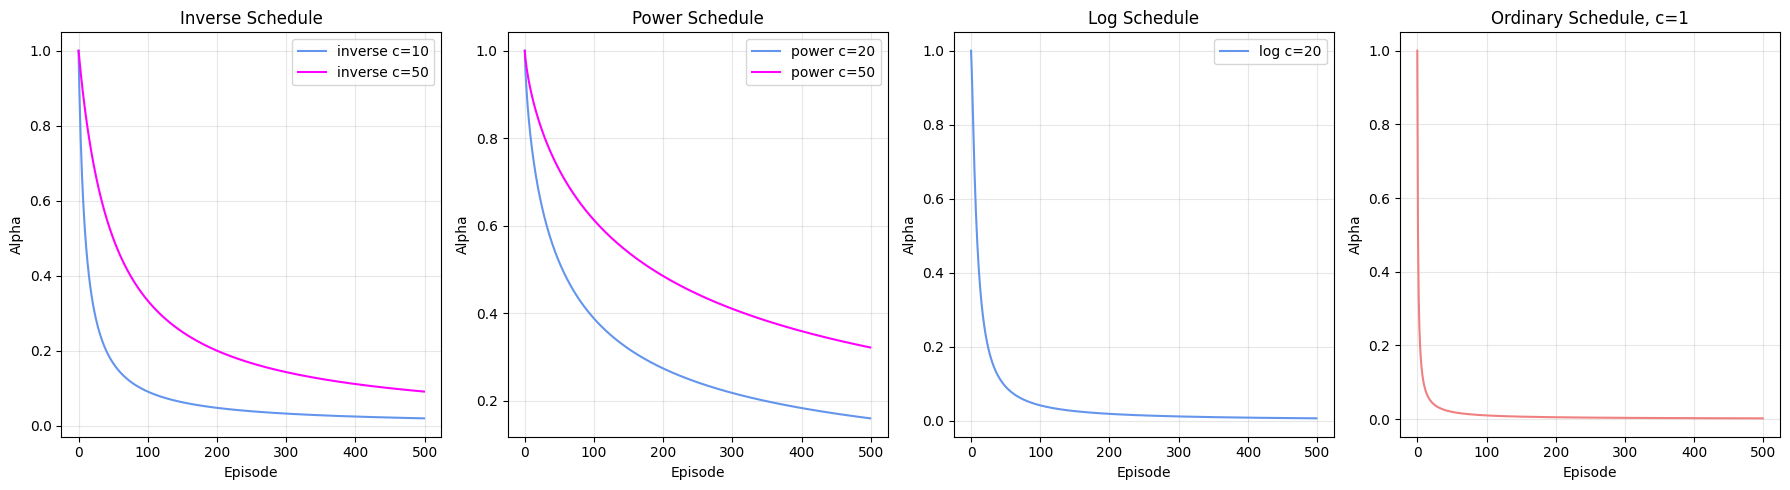

running seed 21
running seed 99
running seed 100

Fixed Vol Policy Alpha Schedule Comparison
    schedule  mc_mse_mean    mc_mse_std  td_error_mean  td_error_std
inverse c=10 3.691420e+06 267091.007763     505.230103     19.227121
inverse c=50 2.676237e+06 260504.928753    1274.459890    176.518304
  power c=20 2.964733e+06 665363.236870    1364.467462     63.681053
  power c=50 2.542086e+06 132880.151329    1365.016247     90.415352
    log c=20 3.083458e+06 415336.988254     373.422294     47.447229

Best MC: power c=50
Best TD: log c=20
running seed 21
running seed 99
running seed 100

Rolling Vol Policy Alpha Schedule Comparison
    schedule  mc_mse_mean    mc_mse_std  td_error_mean  td_error_std
inverse c=10 3.921961e+06 202794.307491     372.838865     19.176591
inverse c=50 3.718498e+06 346093.024358     752.486585     34.302458
  power c=20 3.621066e+06 257063.945175     816.828339    110.357940
  power c=50 3.812729e+06  99225.844087    1190.114118    107.969376
    log c=20 3

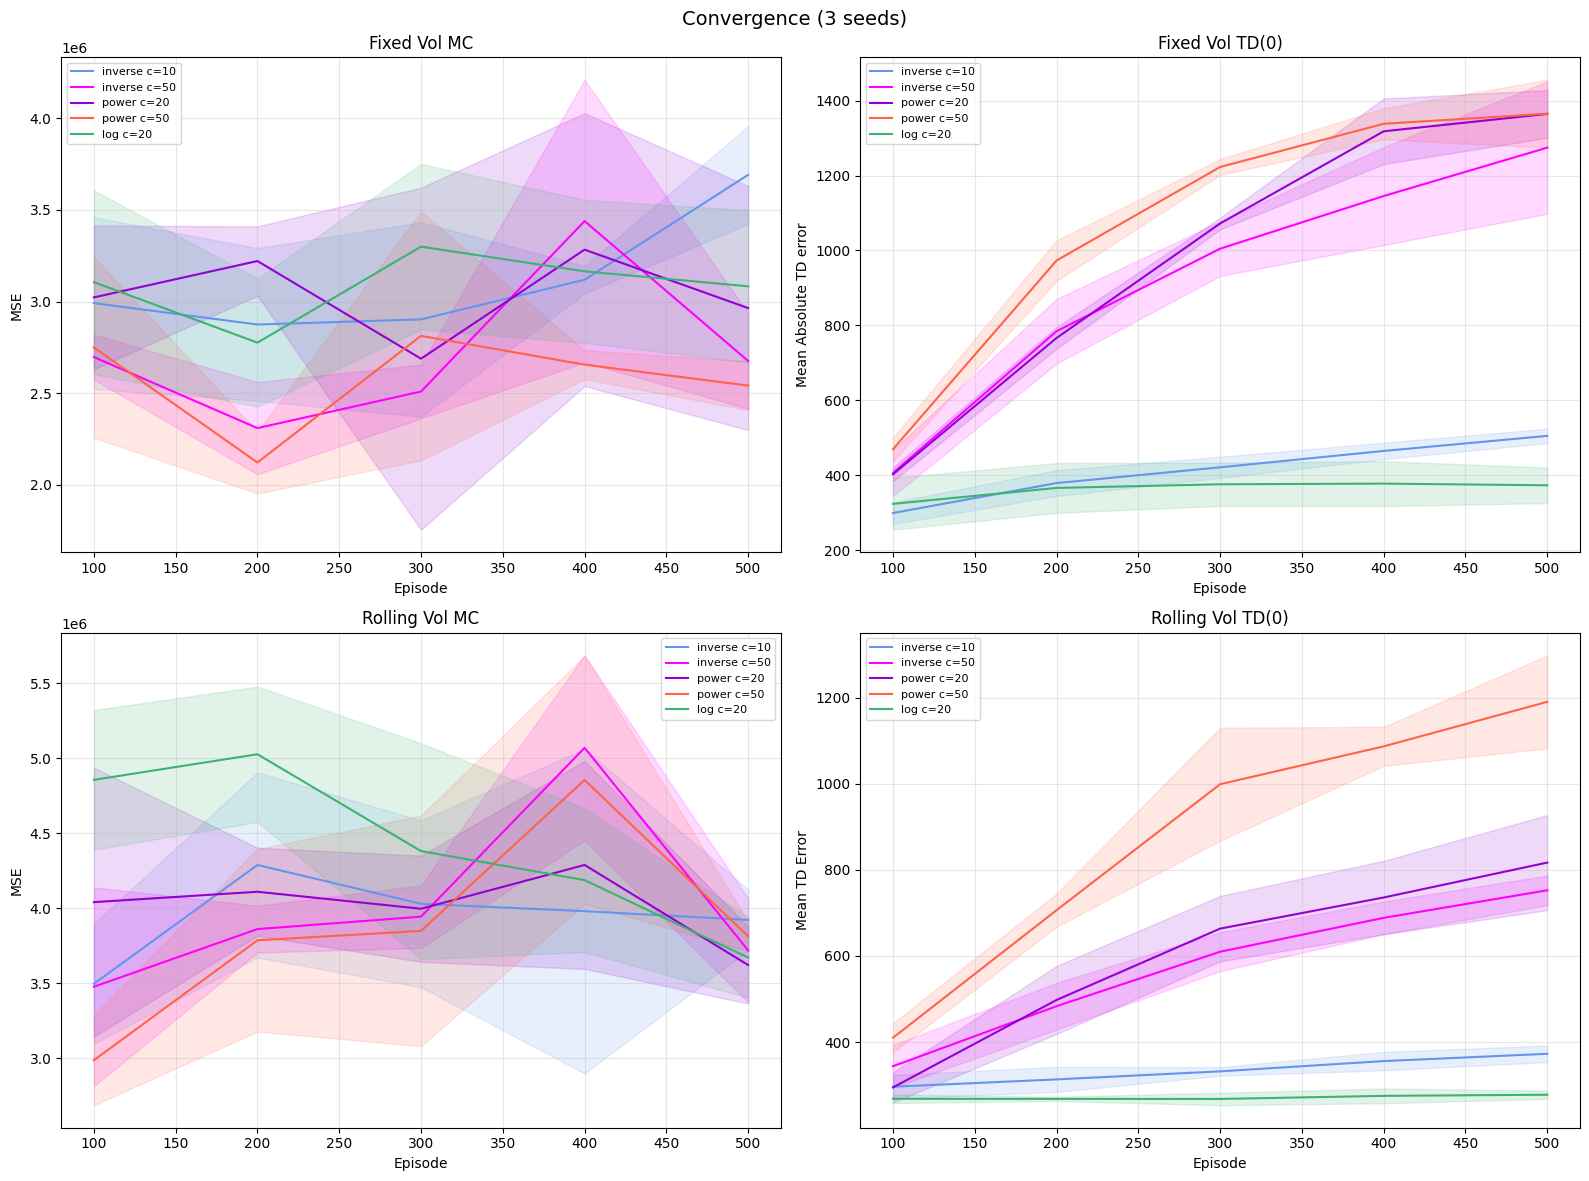

Training final thetas
  Fixed MC:   power c=50
  Fixed TD:   log c=20
  Rolling MC: power c=20
  Rolling TD: log c=20

Evaluating on 500 unseen episodes on all timesteps with seed 99


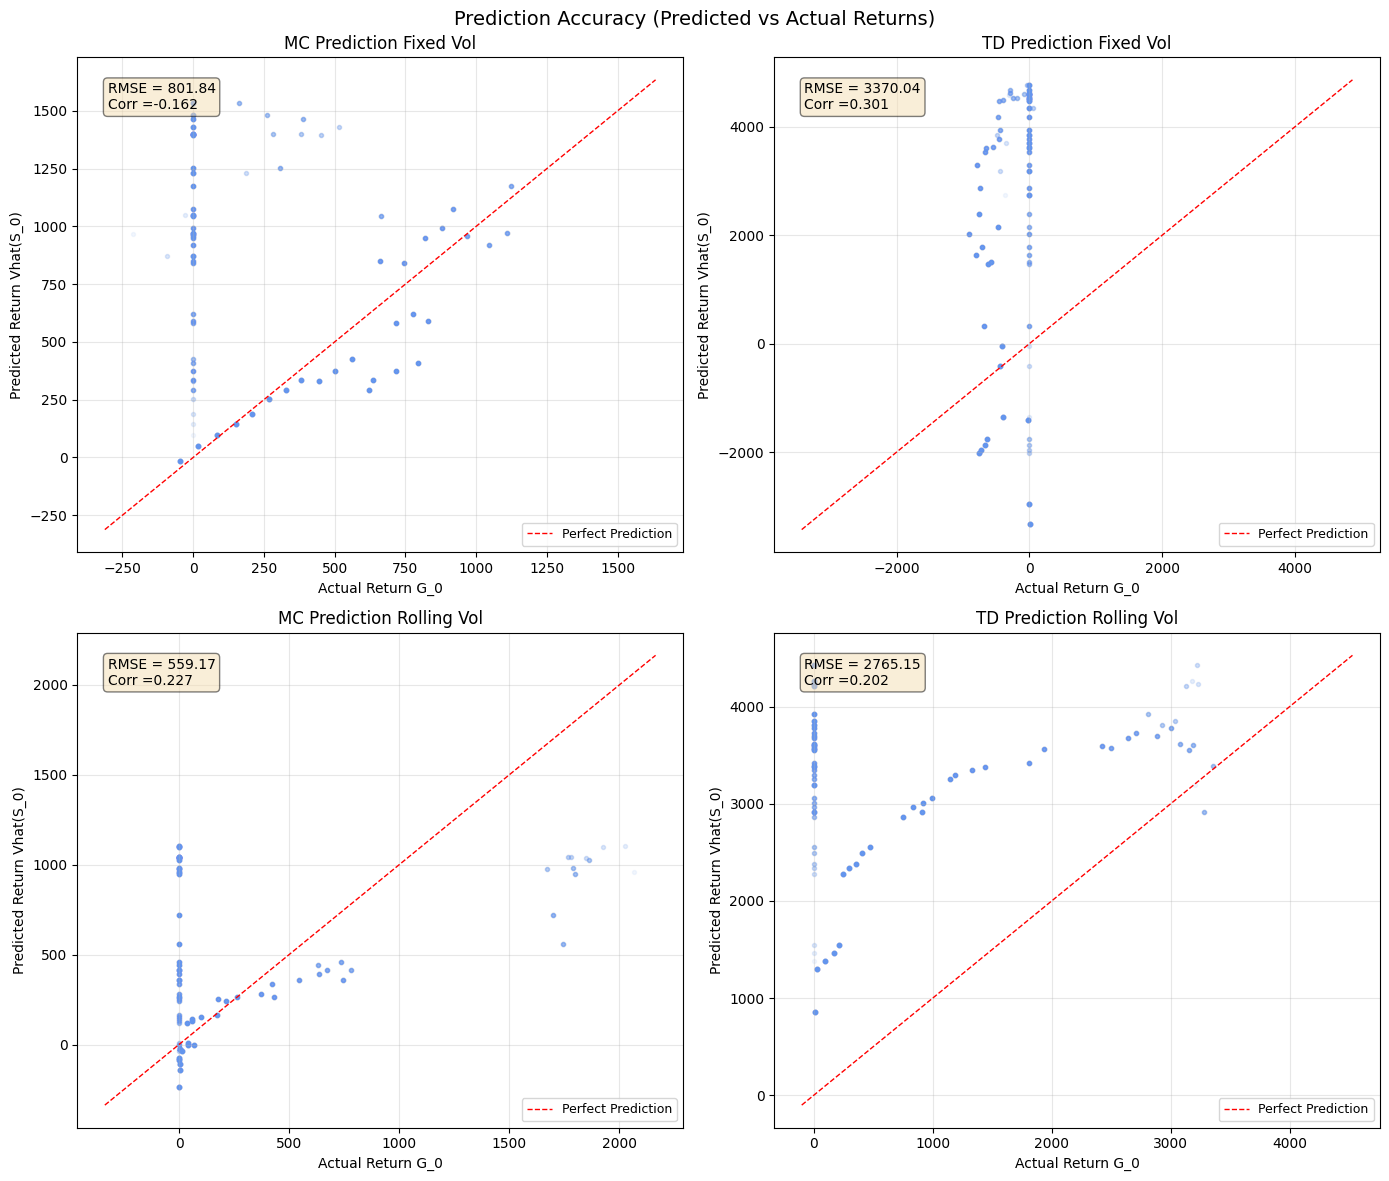


Prediction Summary
     policy method best_schedule        RMSE  correlation
  Fixed Vol     MC    power c=50  801.837985    -0.161642
  Fixed Vol     TD      log c=20 3370.041643     0.300861
Rolling Vol     MC    power c=20  559.169890     0.227224
Rolling Vol     TD      log c=20 2765.150495     0.201671
BS Fixed Vol:   mean=1000.7436799267356, std=1696.7886407099436, median=1188.07743369932
BS Rolling Vol: mean=801.0919257391462, std=2087.957137563727, median=1134.1246304929382


In [26]:
K = s_0
n_eps = 500
eval_interval = 100
seeds = [21, 99, 100]

scheds = {
    'inverse c=10': ('inverse', 10),
    'inverse c=50': ('inverse', 50),
    'power c=20': ('power', 20),
    'power c=50': ('power', 50),
    'log c=20': ('log', 20),
}

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
eps_range = np.arange(n_eps)
colours = ['cornflowerblue', 'magenta', 'mediumspringgreen', 'mediumorchid', 'tomato']

# group schedules by type
groups = {
    'inverse': [(name, c) for name, (typ, c) in scheds.items() if typ == 'inverse'],
    'power':   [(name, c) for name, (typ, c) in scheds.items() if typ == 'power'],
    'log':     [(name, c) for name, (typ, c) in scheds.items() if typ == 'log'],
}

# plot grouped schedules
for (sched_type, ax, title) in [
    ('inverse', axes[0], 'Inverse'),
    ('power',   axes[1], 'Power'),
    ('log',     axes[2], 'Log')
]:
    for (label, c), color in zip(groups[sched_type], colours):
        alphas = [alpha_sched(n, sched_type, c) for n in eps_range]
        ax.plot(eps_range, alphas, label=label, linewidth=1.5, color=color)

    ax.set_xlabel('Episode')
    ax.set_ylabel('Alpha')
    ax.set_title(f'{title} Schedule')
    ax.legend()
    ax.grid(True, alpha=0.3)

# ordinary schedule
alphas = [alpha_sched(n, 'ordinary', 1) for n in eps_range]
axes[3].plot(eps_range, alphas, linewidth=1.5, color='lightcoral')
axes[3].set_xlabel('Episode')
axes[3].set_ylabel('Alpha')
axes[3].set_title('Ordinary Schedule, c=1')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# running all schedule combos across seeds to evaluate fixed vol policy

# store final TD error and MSE
mc_seed_results_fixed = {}
td_seed_results_fixed = {}

# store  TD error and MSE convergence
mc_curves_fixed = {}
td_curves_fixed = {}

for s in scheds:
    mc_seed_results_fixed[s] = []
    td_seed_results_fixed[s] = []
    mc_curves_fixed[s] = []
    td_curves_fixed[s] = []

for seed in seeds:
    print(f'running seed {seed}')
    for s, (sched_type, c) in scheds.items():
        np.random.seed(seed)
        _, eps, mc_mse = mc_prediction(policy_bs_fixed_vol, n_eps, hmm_stats,
        market_params, s_0, K, sched_type, c, eval_interval)
        mc_seed_results_fixed[s].append(mc_mse[-1])
        mc_curves_fixed[s].append(mc_mse)

        np.random.seed(seed)
        _, eps, td_e = td_prediction(policy_bs_fixed_vol, n_eps, hmm_stats,
        market_params, s_0, K, sched_type, c, eval_interval)
        td_seed_results_fixed[s].append(td_e[-1])
        td_curves_fixed[s].append(td_e)
eps = np.array(eps)

results_fixed = pd.DataFrame({'schedule': list(scheds.keys()),
    'mc_mse_mean': [np.mean(mc_seed_results_fixed[s]) for s in scheds],
    'mc_mse_std': [np.std(mc_seed_results_fixed[s]) for s in scheds],
    'td_error_mean': [np.mean(td_seed_results_fixed[s]) for s in scheds],
    'td_error_std': [np.std(td_seed_results_fixed[s]) for s in scheds]})

best_mc_fixed = results_fixed.loc[results_fixed['mc_mse_mean'].idxmin(), 'schedule']
best_td_fixed = results_fixed.loc[results_fixed['td_error_mean'].idxmin(), 'schedule']

print('\nFixed Vol Policy Alpha Schedule Comparison')
print(results_fixed.to_string(index=False))
print(f'\nBest MC: {best_mc_fixed}')
print(f'Best TD: {best_td_fixed}')


# running all schedule combos across seeds to evaluate rolling vol policy

# store final MSE and TD error
mc_seed_results_rolling = {}
td_seed_results_rolling = {}

# store coverging MSE and TD error
mc_curves_rolling = {}
td_curves_rolling = {}

for s in scheds:
    mc_seed_results_rolling[s] = []
    td_seed_results_rolling[s] = []
    mc_curves_rolling[s] = []
    td_curves_rolling[s] = []

for seed in seeds:
    print(f'running seed {seed}')
    for s, (sched_type, c) in scheds.items():
        np.random.seed(seed)
        _, eps_r, mc_mse = mc_prediction(policy_bs_rolling_vol, n_eps,
        hmm_stats, market_params, s_0, K, sched_type, c, eval_interval)
        mc_seed_results_rolling[s].append(mc_mse[-1])
        mc_curves_rolling[s].append(mc_mse)

        np.random.seed(seed)
        _, eps_r, td_e = td_prediction(policy_bs_rolling_vol, n_eps, hmm_stats,
        market_params, s_0, K, sched_type, c, eval_interval)
        td_seed_results_rolling[s].append(td_e[-1])
        td_curves_rolling[s].append(td_e)

# put results into a df
results_rolling = pd.DataFrame({'schedule': list(scheds.keys()),
    'mc_mse_mean': [np.mean(mc_seed_results_rolling[s]) for s in scheds],
    'mc_mse_std': [np.std(mc_seed_results_rolling[s]) for s in scheds],
    'td_error_mean': [np.mean(td_seed_results_rolling[s]) for s in scheds],
    'td_error_std': [np.std(td_seed_results_rolling[s]) for s in scheds]})

# find which alpha schedule has the least prediction error
best_mc_rolling = results_rolling.loc[results_rolling['mc_mse_mean'].idxmin(), 'schedule']
best_td_rolling = results_rolling.loc[results_rolling['td_error_mean'].idxmin(), 'schedule']

print('\nRolling Vol Policy Alpha Schedule Comparison')
print(results_rolling.to_string(index=False))
print(f'\nBest MC: {best_mc_rolling}')
print(f'Best TD: {best_td_rolling}')

# visualising convergence in prediction
colours = ['cornflowerblue', 'magenta', 'darkviolet', 'tomato', 'mediumseagreen']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for name, colour in zip(scheds, colours):
    mc_arr = np.array(mc_curves_fixed[name])
    mc_mean = mc_arr.mean(axis=0)
    mc_std_ = mc_arr.std(axis=0)
    axes[0, 0].plot(eps, mc_mean, label=name, linewidth=1.5, color=colour)
    axes[0, 0].fill_between(eps, mc_mean - mc_std_, mc_mean + mc_std_,
                            alpha=0.15, color=colour)
axes[0, 0].set_title('Fixed Vol MC')
axes[0, 0].set_xlabel('Episode')
axes[0, 0].set_ylabel('MSE')
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(True, alpha=0.3)

for name, colour in zip(scheds, colours):
    td_arr = np.array(td_curves_fixed[name])
    td_mean = td_arr.mean(axis=0)
    td_std_ = td_arr.std(axis=0)
    axes[0, 1].plot(eps, td_mean, label=name, linewidth=1.5, color=colour)
    axes[0, 1].fill_between(eps, td_mean - td_std_, td_mean + td_std_, alpha=0.15, color=colour)
axes[0, 1].set_title('Fixed Vol TD(0)')
axes[0, 1].set_xlabel('Episode')
axes[0, 1].set_ylabel('Mean Absolute TD error')
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(True, alpha=0.3)

for name, colour in zip(scheds, colours):
    mc_arr = np.array(mc_curves_rolling[name])
    mc_mean = mc_arr.mean(axis=0)
    mc_std_ = mc_arr.std(axis=0)
    axes[1, 0].plot(eps, mc_mean, label=name, linewidth=1.5, color=colour)
    axes[1, 0].fill_between(eps, mc_mean - mc_std_, mc_mean + mc_std_, alpha=0.15, color=colour)
axes[1, 0].set_title('Rolling Vol MC')
axes[1, 0].set_xlabel('Episode')
axes[1, 0].set_ylabel('MSE')
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True, alpha=0.3)

for name, colour in zip(scheds, colours):
    td_arr = np.array(td_curves_rolling[name])
    td_mean = td_arr.mean(axis=0)
    td_std_ = td_arr.std(axis=0)
    axes[1, 1].plot(eps, td_mean, label=name, linewidth=1.5, color=colour)
    axes[1, 1].fill_between(eps, td_mean - td_std_, td_mean + td_std_, alpha=0.15, color=colour)
axes[1, 1].set_title('Rolling Vol TD(0)')
axes[1, 1].set_xlabel('Episode')
axes[1, 1].set_ylabel('Mean TD Error')
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle(f'Convergence ({len(seeds)} seeds)', fontsize=14)
plt.tight_layout()
plt.show()

# train final thetas with best schedules at higher episode count
best_mc_type_fixed, best_mc_c_fixed = scheds[best_mc_fixed]
best_td_type_fixed, best_td_c_fixed = scheds[best_td_fixed]
best_mc_type_rolling, best_mc_c_rolling = scheds[best_mc_rolling]
best_td_type_rolling, best_td_c_rolling = scheds[best_td_rolling]

print('Training final thetas')
print(f'  Fixed MC:   {best_mc_fixed}')
print(f'  Fixed TD:   {best_td_fixed}')
print(f'  Rolling MC: {best_mc_rolling}')
print(f'  Rolling TD: {best_td_rolling}')

n_eps_final = 3000

# running prediction to find optimal theta weights for fixed vol b-s policy
# run mc prediction with optimal alpha schedule with best c value found earlier
np.random.seed(21)
mc_theta_fixed, mc_eps_f, mc_mse_f = mc_prediction(policy_bs_fixed_vol,
n_eps_final, hmm_stats, market_params, s_0, K, best_mc_type_fixed,
best_mc_c_fixed, eval_interval)

# run td prediction with optimal alpha schedule with best c value found earlier
np.random.seed(21)
td_theta_fixed, td_eps_f, td_e_f = td_prediction(policy_bs_fixed_vol,
n_eps_final, hmm_stats, market_params, s_0, K, best_td_type_fixed,
best_td_c_fixed, eval_interval)

# running prediction to find optimal theta weights for rolling vol b-s policy
# run mc prediction with optimal alpha schedule with best c value found earlier
np.random.seed(21)
mc_theta_rolling, mc_eps_r, mc_mse_r = mc_prediction(policy_bs_rolling_vol,
n_eps_final, hmm_stats, market_params, s_0, K, best_mc_type_rolling,
best_mc_c_rolling, eval_interval)

# run td prediction with optimal alpha schedule with best c value found earlier
np.random.seed(21)
td_theta_rolling, td_eps_r, td_e_r = td_prediction(policy_bs_rolling_vol,
n_eps_final, hmm_stats, market_params, s_0, K, best_td_type_rolling,
best_td_c_rolling, eval_interval)

# write function to evaluate prediction on unseen episodes
def eval_pred(theta, policy, hmm_stats, market_params, s_0, K, n_eps):
  # track predictions vs actual values
  predicted = []
  actual = []
  for ep in range(n_eps):
    episode = generate_episode(policy, s_0, K, hmm_stats, market_params)
    rewards = episode['rewards']
    spots = episode['spots']
    hedge_prev = episode['hedge_prev']
    T = len(rewards)

    # compute returns from each timestep
    G = np.zeros(T)
    G[T - 1] = rewards[T - 1]
    for t in range(T - 2, -1, -1):
      G[t] = rewards[t] + G[t + 1]
      # evaluate at every timestep
      for t in range(T):
        state = {'t': t, 'T': 40, 'S_t': spots[t], 'K': K,
        'delta_current': hedge_prev[t],'spot_history': spots[:t + 1],
        'r_pln': market_params['r_pln'],'r_usd': market_params['r_usd'],
        'k1': market_params['k1'],'k2': market_params['k2'],
        'k3': market_params['k3']}
        phi = features(state)
        predicted.append(theta @ phi)
        actual.append(G[t])

    return np.array(predicted), np.array(actual)

# actually evaluate predictions
val_eps = 500
print(f'\nEvaluating on {val_eps} unseen episodes on all timesteps with seed 99')

# evaluating using MC for fixed vol
np.random.seed(99)
mc_pred_fixed, mc_actual_fixed = eval_pred(mc_theta_fixed,
policy_bs_fixed_vol, hmm_stats, market_params, s_0, K, val_eps)

# evaluating using TD for fixed vol
np.random.seed(99)
td_pred_fixed, td_actual_fixed = eval_pred(td_theta_fixed, policy_bs_fixed_vol,
hmm_stats, market_params, s_0, K, val_eps)

# evaluating using MC for rolling vol
np.random.seed(99)
mc_pred_rolling, mc_actual_rolling = eval_pred(mc_theta_rolling,
policy_bs_rolling_vol, hmm_stats, market_params, s_0, K, val_eps)

# evaluating using TD for rolling vol
np.random.seed(99)
td_pred_rolling, td_actual_rolling = eval_pred(td_theta_rolling,
policy_bs_rolling_vol, hmm_stats, market_params, s_0, K, val_eps)

# visualise prediction for MC and TD (both policies)
fig, axes = plt.subplots(2, 2, figsize=(14,12))

for ax, pred, actual, title in [
    (axes[0,0], mc_pred_fixed, mc_actual_fixed, 'MC Prediction Fixed Vol'),
    (axes[0,1], td_pred_fixed, td_actual_fixed, 'TD Prediction Fixed Vol'),
    (axes[1,0], mc_pred_rolling, mc_actual_rolling, 'MC Prediction Rolling Vol'),
    (axes[1,1], td_pred_rolling, td_actual_rolling, 'TD Prediction Rolling Vol')]:

    ax.scatter(actual, pred, alpha=0.08, s=8, c='cornflowerblue')
    # creating line of perfect prediction
    lo = min(actual.min(), pred.min()) -100  # -100 to add padding to the line
    hi = max(actual.max(), pred.max()) + 100  # +100 to add padding
    ax.plot([lo, hi], [lo,hi], 'r--', linewidth=1, label='Perfect Prediction')
    ax.set_xlabel('Actual Return G_0')
    ax.set_ylabel('Predicted Return Vhat(S_0)')
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    rmse = np.sqrt(np.mean((pred - actual)**2))
    corr = np.corrcoef(pred, actual)[0, 1]
    ax.text(0.05, 0.95, f'RMSE = {rmse:.2f}\nCorr ={corr:.3f}',
    transform=ax.transAxes, verticalalignment='top', fontsize=10, bbox=dict(
    boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Prediction Accuracy (Predicted vs Actual Returns)',
fontsize=14)
plt.tight_layout()
plt.show()

# summarise prediction results in a dataframe asw
pred_summary = pd.DataFrame({
    'policy': ['Fixed Vol', 'Fixed Vol', 'Rolling Vol', 'Rolling Vol'],
    'method': ['MC', 'TD', 'MC', 'TD'],
    'best_schedule': [best_mc_fixed, best_td_fixed, best_mc_rolling, best_td_rolling],
    'RMSE': [
        np.sqrt(np.mean((mc_pred_fixed - mc_actual_fixed)**2)),
        np.sqrt(np.mean((td_pred_fixed - td_actual_fixed)**2)),
        np.sqrt(np.mean((mc_pred_rolling - mc_actual_rolling)**2)),
        np.sqrt(np.mean((td_pred_rolling - td_actual_rolling)**2)),
    ],
    'correlation': [
        np.corrcoef(mc_pred_fixed, mc_actual_fixed)[0, 1],
        np.corrcoef(td_pred_fixed, td_actual_fixed)[0, 1],
        np.corrcoef(mc_pred_rolling, mc_actual_rolling)[0, 1],
        np.corrcoef(td_pred_rolling, td_actual_rolling)[0, 1],
    ],
})

print('\nPrediction Summary')
print(pred_summary.to_string(index=False)) # drop row numbering

# baseline terminal PnL for both policies (so can compare control results)
n_baseline = 1000

# fixed vol policy
np.random.seed(50) # use new unseen seed
baseline_fixed_pnls = []
for ep in range(n_baseline):
    episode = generate_episode(policy_bs_fixed_vol, s_0, K, hmm_stats, market_params)
    baseline_fixed_pnls.append(episode['terminal_pnl'])
baseline_fixed_pnls = np.array(baseline_fixed_pnls)
# rolling vol policy
np.random.seed(50)  # new unseen seed
baseline_rolling_pnls = []
for ep in range(n_baseline):
    episode = generate_episode(policy_bs_rolling_vol, s_0, K, hmm_stats, market_params)
    baseline_rolling_pnls.append(episode['terminal_pnl'])
baseline_rolling_pnls = np.array(baseline_rolling_pnls)

# print results so can compare later
print(f'BS Fixed Vol:   mean={baseline_fixed_pnls.mean()}, std={baseline_fixed_pnls.std()}, median={np.median(baseline_fixed_pnls)}')
print(f'BS Rolling Vol: mean={baseline_rolling_pnls.mean()}, std={baseline_rolling_pnls.std()}, median={np.median(baseline_rolling_pnls)}')

# Evaluation functions
Originally, each control used a different evaluation method. This causes problems when comparing the results across different agents so I outline a function to evaluate training results and a separate function that evaluates black-scholes policies once so each model can be compared. I also create a summary dataframe function so I can compare the same metrics across all models.

In [27]:
def evaluate_policy(policy, n_paths=2000, eval_seed=21212121):
  pnls = np.zeros(n_paths)
  tcs = np.zeros(n_paths) # transaction costs
  turnovers = np.zeros(n_paths) # total absolute delta (usd) traded bc tc incurred whether buy/sell
  delta_paths = np.zeros((n_paths, 40)) # daily hedge held by agent
  bs_delta_paths = np.zeros((n_paths, 40)) # bs ref delta calculated everyday (fixed vol)
  spot_paths = np.zeros((n_paths, 41))

  for e in range(n_paths):
    rng = np.random.default_rng(eval_seed + e) # new seed each episode
    ep = generate_episode(policy, s_0, K, hmm_stats, market_params, rng=rng)

    # tracking evaluation metrics
    pnls[e] =  ep['terminal_pnl']
    tcs[e]= ep['tc_total']
    # adding 0 for start and end of episode hedge held
    deltas_with_unwind = np.concatenate([[0], ep['target_deltas'], [0]])
    turnovers[e] = np.sum(np.abs(np.diff(deltas_with_unwind)))

    delta_paths[e] = ep['target_deltas']
    spot_paths[e] = ep['spots']

    # tracking bs ref delta
    bs_deltas = np.zeros(40)
    for t in range(40):
      S = ep['spots'][t]
      tao = (40-t) / 252
      if tao <= 0:
        if S > K:
          bs_deltas[t] = 1
        else:
          bs_deltas[t] = 0
      else:
        sigma = market_params['sigma_fixed']
        r_pln = market_params['r_pln']
        r_usd = market_params['r_usd']
        d1 = bs_d1(S, K, tao, r_pln, r_usd, sigma)
        bs_deltas[t] = np.exp(-r_usd * tao) * norm.cdf(d1)

    bs_delta_paths[e] = bs_deltas
  # return eval metrics
  return{'pnl': pnls, 'tc': tcs, 'turnover': turnovers,
         'delta_paths': delta_paths, 'bs_delta_paths': bs_delta_paths,
         'spot_paths': spot_paths}

In [28]:
# testing evaluation function
r = evaluate_policy(policy_bs_fixed_vol, n_paths=50)
print(r['pnl'].mean(), r['pnl'].std())
print(r['turnover'].mean())

1089.5384849882157 1471.0112232755512
2.84021070325992


In [29]:
# bs policies eval function
bs_fixed_eval = evaluate_policy(policy_bs_fixed_vol)
bs_rolling_eval = evaluate_policy(policy_bs_rolling_vol)

print(f'BS Fixed  : mean={bs_fixed_eval['pnl'].mean()}, '
      f'std={bs_fixed_eval['pnl'].std()}, '
      f'turnover={bs_fixed_eval['turnover'].mean()}')
print(f'BS Rolling: mean={bs_rolling_eval['pnl'].mean()}, '
      f'std={bs_rolling_eval['pnl'].std()}, '
      f'turnover={bs_rolling_eval['turnover'].mean()}')

BS Fixed  : mean=1022.1092588552668, std=1622.9651192551994, turnover=2.8449858628968707
BS Rolling: mean=922.6801491203125, std=1946.355829651222, turnover=3.596738144958711


In [30]:
# summary df function
def build_summary(evals_dict):
    rows = []
    for name, r in evals_dict.items():
        # sharpe ratio calc
        if r['pnl'].std() > 0:
            sharpe = r['pnl'].mean() / r['pnl'].std()
        else:
            sharpe = 0
        row = {'policy':name, 'mean_pnl':r['pnl'].mean(),
               'std_pnl':r['pnl'].std(), 'sharpe':sharpe,
               '5th_pct':np.percentile(r['pnl'], 5),
               '95th_pct':np.percentile(r['pnl'], 95),'mean_tc':r['tc'].mean(),
               'mean_turnover':r['turnover'].mean()}
        rows.append(row)

    return pd.DataFrame(rows)

# Control (Q-learning epsilon greedy)


*   Discretise actions
*   Define action features
* write epsilon-greedy schedule
* change environment s.t accepts actions from the agent not fixed policy

Note that the last cell in this control section takes over an hour to run.



In [31]:
# making action space discrete
actions = np.linspace(0, 1, 11) # 10 bins between 0 and 1
n_actions = len(actions)

# creating Q-feature function
def q_feats(state, a):
  S = state['S_t']
  K = state['K']
  t = state['t']
  T = state['T'] # 40
  delta = state['delta_current']

  tao_annual = (T - t)/252
  spot_hist = state['spot_history']
  # rolling vol
  if len(spot_hist) > 5:
    recent = spot_hist[-5:]
    log_rets = np.log(recent[1:]/recent[:-1])
    est_vol = log_rets.std() * np.sqrt(252)
    if est_vol < 0.00000001:
      est_vol = market_params['sigma_fixed']
  else:
    est_vol = market_params['sigma_fixed']

  # when not expired calculate delta
  if tao_annual > 0:
    d1 = bs_d1(S, K, tao_annual, state['r_pln'], state['r_usd'], est_vol)
    ref_delta = np.exp(-state['r_usd'] * tao_annual) * norm.cdf(d1)
  else:
    if S > K: # at exp if ITM
      ref_delta = 1
    else: # at exp if OTM
      ref_delta = 0

  # definining features
  hedge_error = delta - ref_delta
  rounds_left = T-t
  urgency = 1/rounds_left
  vol_surprise = est_vol - market_params['sigma_fixed']
  moneyness = S/K
  ln_moneyness = np.log(S/K)
  tao_frac = rounds_left / T

  # define bins
  moneyness_edges = [0.98, 0.99, 1, 1.01, 1.02]
  time_edges = [5, 10, 15, 20, 25, 30, 35]
  delta_edges = [0.2, 0.4, 0.6, 0.8]
  vol_edges = [0.06, 0.1, 0.14]
  action_edges = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

  # writing feature counts
  n_state_bins = (len(moneyness_edges) + 1 + len(time_edges) + 1 +
  len(delta_edges) + 1 + len(vol_edges) + 1)
  n_action_bins = len(action_edges) + 1
  n_continuous = 4 # ln_moneyness, tao_frac, delta, est_vol
  n_linear = 3 # hedge_error, urgency, vol_surprise
  n_action_cont = 1 # raw action value
  n_state_interactions = 5 # to be created
  n_action_interactions = 5 # action * state variable interactions to be created
  n_bias = 1
  n_feats = (n_state_bins + n_action_bins + n_continuous + n_linear + n_action_cont
  + n_state_interactions + n_action_interactions + n_bias)
  phi = np.zeros(n_feats)
  idx = 0

  # create state bins feature vector columns
  # moneyness
  phi[idx + np.digitize(moneyness, moneyness_edges)] = 1
  idx += len(moneyness_edges) + 1
  # tao
  phi[idx + np.digitize(t, time_edges)] = 1
  idx += len(time_edges) + 1
  # vol
  phi[idx + np.digitize(est_vol, vol_edges)] = 1
  idx += len(vol_edges) +1
  # delta
  phi[idx + np.digitize(delta, delta_edges)] = 1
  idx += len(delta_edges) + 1

  #create action bins
  phi[idx + np.digitize(a, action_edges)] = 1
  idx += len(action_edges) +1

  # writing feature vector for continuous states
  phi[idx] = ln_moneyness
  idx+= 1
  phi[idx] = tao_frac
  idx+= 1
  phi[idx] = delta
  idx+= 1
  phi[idx] = est_vol
  idx+= 1

  # writing feature vector cols for linear relationship state variables
  phi[idx] = hedge_error
  idx += 1
  phi[idx] = urgency
  idx+= 1
  phi[idx] = vol_surprise
  idx+= 1

  # adding feature vector column for continuous action feature
  phi[idx] = a
  idx += 1

  # adding state interaction columns to feature vector
  phi[idx] = delta * ln_moneyness
  idx += 1
  phi[idx] = delta * tao_frac
  idx += 1
  phi[idx] = est_vol * tao_frac
  idx += 1
  phi[idx] = hedge_error * urgency
  idx += 1
  phi[idx] = est_vol * ln_moneyness
  idx += 1

  # adding action-state interaction columns to feature vector
  phi[idx] = a * ln_moneyness
  idx += 1
  phi[idx] = a * tao_frac
  idx += 1
  phi[idx] = a * est_vol
  idx += 1
  phi[idx] = a * hedge_error
  idx += 1
  phi[idx] = a * urgency
  idx += 1

  # adding bias column to feature vector
  phi[idx] = 1
  idx += 1

  return phi

# calculating Q-feature vector dimension, enter dummy values
n_q_feats = len(q_feats({'t': 0, 'T': 40, 'S_t': 1, 'K': 1,
'delta_current': 0, 'spot_history': np.array([1]), 'r_pln': 0, 'r_usd':0,
'k1': 0, 'k2':0, 'k3':0}, 0.5)) # dummy action is 0.5 hedge

# define epsilon greedy action which decides wheter to explore or exploit
def epsilon_greedy_action(theta, state, epsilon):
  if np.random.random() < epsilon:
    return np.random.choice(actions)
  else:
    return greedy_action(theta, state)

# define greedy action selection function i.e. pick highest Q value a
def greedy_action(theta, state):
  best_a = 0
  best_q = -np.inf # any Q value has to be larger than initial so set to neg inf
  for a in actions:
    phi = q_feats(state, a)
    q = theta @ phi
    if q > best_q:
      best_q = q
      best_a = a
  return best_a


# create function for epsilon schedules
def eps_sched(ep, eps_type, decay, eps_min=0.05):
  if eps_type == 'exponential':
    return eps_min + (1 - eps_min) * np.exp(-ep/decay)
  elif eps_type == 'linear':
    return max(eps_min, 1 - ep/decay)
  else:
    raise ValueError(f'Epsilon decay schedule does not exist')

# function to generate an episode under epsilon-greedy strategy
def gen_control_ep(theta, s_0, K, hmm_stats, market_params, epsilon, T= 40,
rng=None):
  if rng is None:
    rng = np.random.default_rng()

  # initialise params
  dt = 1/252
  r_pln = market_params['r_pln']
  r_usd = market_params['r_usd']
  notional = market_params['notional']
  sigma_fixed = market_params['sigma_fixed']
  k1 = market_params['k1']
  k2 = market_params['k2']
  k3 = market_params['k3']

  # sim price
  spots, regimes = price_sim(s_0, T, hmm_stats, rng)

  # create env
  tao_0 = T/252
  premium_per_unit = call_pricer(spots[0], K, tao_0, r_pln, r_usd, sigma_fixed)
  premium_pln = premium_per_unit * notional
  delta_current = 0
  usd_held = 0
  cum_tc = 0
  cum_pln_spent = 0
  cum_interest_pln = 0
  cum_interest_usd = 0
  v_book_prev = 0

  # store and track progression
  rewards = np.zeros(T)
  actions_1 = np.zeros(T)
  hedge_prev = np.zeros(T)
  states_list = []

  for t in range(T):
     state = {
            't': t, 'T': T, 'S_t': spots[t], 'K': K,
            'delta_current': delta_current,
            'spot_history': spots[:t + 1],
            'r_pln': r_pln, 'r_usd': r_usd,
            'k1': k1, 'k2': k2, 'k3': k3,
        }
     states_list.append(state)
     hedge_prev[t] = delta_current

    # agent chooses action for updates
     target_delta = epsilon_greedy_action(theta, state, epsilon)
     actions_1[t] = target_delta
     trade_delta = target_delta - delta_current
     trade_usd = trade_delta * notional

    # update transaction costs
     if abs(trade_usd) < 0.000000001:
      tc = 0
     else:
      tc = k1 + (k2 * abs(trade_usd)) + (k3 * abs(trade_usd) * spots[t])

     cum_tc += tc
     usd_held += trade_usd
     delta_current = target_delta
     cum_pln_spent += trade_usd * spots[t]
     cum_interest_pln += premium_pln * r_pln * dt
     cum_interest_usd += usd_held * r_usd * dt

     # update spot, tao and call price and MtM book value
     s_next = spots[t + 1]
     tao_next = (T - t - 1) / 252
     call_next = call_pricer(s_next, K, tao_next, r_pln, r_usd, sigma_fixed)
     v_book_now = (-call_next * notional + premium_pln + cum_interest_pln
     - cum_pln_spent + usd_held * s_next + cum_interest_usd * s_next - cum_tc)

     # calc reward and update MtM book value
     reward = v_book_now - v_book_prev
     v_book_prev = v_book_now

     # unwinding transaction costs at expiry
     unwind_tc = 0.0
     if t == T - 1:
       if abs(usd_held) > 1e-10:
         unwind_tc = k1 + (k2 * abs(usd_held)) + (k3 * abs(usd_held) * s_next)
         cum_tc += unwind_tc
         v_book_now -= unwind_tc
         reward -= unwind_tc

     rewards[t] = reward # store each step's reward

  return {'spots': spots, 'regimes': regimes, 'rewards': rewards,
  'actions': actions_1,'hedge_prev': hedge_prev, 'states': states_list,
  'premium': premium_pln,'terminal_pnl': v_book_now,'tc_total': cum_tc}

In [32]:
# MC on-policy control (using epsilon decay policies)
def mc_control(n_eps, hmm_stats, market_params, s_0, K, alpha_type, alpha_c,
               eps_type, eps_decay, eval_interval):
  theta = np.zeros(n_q_feats)
  eval_points = []
  return_hist = []
  recent_returns = []

  for ep in range(n_eps):
    # go over alpha decay schedules and epsilon decay schedules
    alpha = alpha_sched(ep, alpha_type, alpha_c)
    epsilon = eps_sched(ep, eps_type, eps_decay)

    # generate an episode
    episode = gen_control_ep(theta, s_0, K, hmm_stats, market_params, epsilon)

    # pull episode rewards, actions and states
    rewards = episode['rewards']
    actions = episode['actions']
    states = episode['states']
    T = len(rewards) # should be 40

    # backcalc returns
    G = np.zeros(T)
    G[T-1] = rewards[T-1]
    for t in range(T-2, -1, -1):
      G[t] = rewards[t] + G[t+1]

    # run the every-visit MC grad update
    for t in range(T):
      phi = q_feats(states[t], actions[t])
      q_hat = theta @ phi
      error = G[t] - q_hat
      grad = error * phi
      # grad clipping for stability
      grad_norm = np.linalg.norm(grad)
      if grad_norm > 10:
        grad = (grad/grad_norm) * 10
      theta += alpha * grad
    # track terminal PnL
    recent_returns.append(episode['terminal_pnl'])
    # evaluate prediction at eval interval
    if (ep + 1) % eval_interval == 0:
      eval_points.append(ep+1)
      return_hist.append(np.mean(recent_returns))
      recent_returns = []

  return theta, eval_points, return_hist

In [33]:
# SARSA TD on-policy control (using epsilon decay policies)
def td_control(n_eps_control, hmm_stats, market_params, s_0, K, alpha_type, alpha_c,
               eps_type, eps_decay, eval_interval):
  theta = np.zeros(n_q_feats)
  eval_points = []
  return_hist = []
  recent_returns = []

  # track rewards, states and actions in each episode
  for ep in range(n_eps_control):
    alpha = alpha_sched(ep, alpha_type, alpha_c)
    epsilon = eps_sched(ep, eps_type, eps_decay)
    episode = gen_control_ep(theta, s_0, K, hmm_stats, market_params, epsilon)
    rewards = episode['rewards']
    actions = episode['actions']
    states = episode['states']
    T = len(rewards) # should be 40
    # bootstrapping in each episode
    for t in range(T):
      phi_t = q_feats(states[t], actions[t])
      q_t = theta @ phi_t

      if t < T-1:  # if not at terminal step
        phi_next = q_feats(states[t+1], actions[t+1])
        td_target = rewards[t] + (theta @ phi_next)
      else:  # at terminal step
        td_target = rewards[t]

      td_error = td_target - q_t
      grad = td_error * phi_t  # gradient step

      # gradient clipping at 50 for stability
      grad_norm = np.linalg.norm(grad)
      if grad_norm > 50:
        grad = (grad/grad_norm) * 50
      theta += alpha * grad

    # track terminal pnl
    recent_returns.append(episode['terminal_pnl'])
    if (ep + 1) % eval_interval == 0:
      eval_points.append(ep+1)
      return_hist.append(np.mean(recent_returns))
      recent_returns = []
  return theta, eval_points, return_hist

MC Alpha test power c=50: mean=-208.04864216094208
TD Alpha test power c=50: mean=477.45987773938197
MC Alpha test log c=20: mean=-269.3355586423344
TD Alpha test log c=20: mean=-126.9088090848134

Best MC alpha schedule: power c=50

Best TD alpha schedule: power c=50


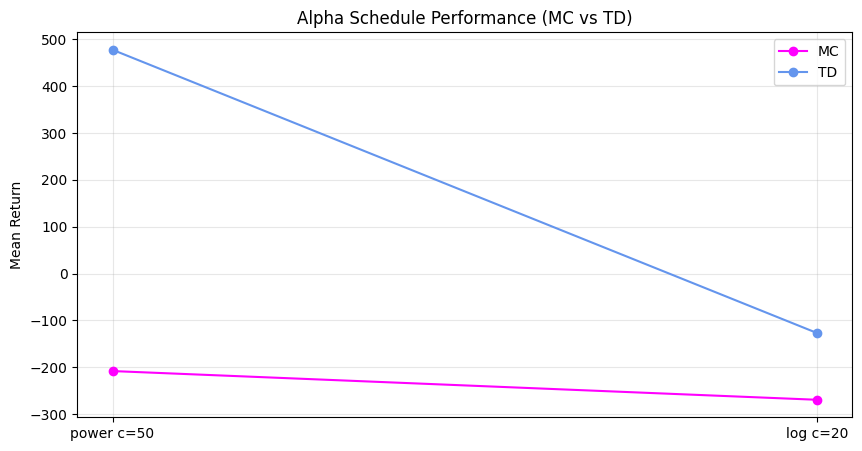

In [34]:
# running MC and TD control (45mins)
K = s_0

# using results from prediction (best alpha schedules for MC and TD)
ctrl_scheds = {'power c=50': ('power', 50), 'log c=20': ('log', 20)}

# test both epsilon types and different decay rates
eps_configs = [('exponential', 500), ('exponential',20000), ('linear', 1500)]

# tuning alpha schedule holding eps_sched and eps_decay constant
n_eps_ctrl = 1500
eval_interval = 200
seeds_ctrl = [21, 99, 68]
fixed_eps_type = 'exponential'
fixed_eps_decay = 1000
alpha_results_mc = {} # to store results
alpha_results_td = {}

# trying different alpha schedules
# running MC control on different alpha scheds
for sched_name, (alpha_type, alpha_c) in ctrl_scheds.items():
  returns = [] # to store returns
  for seed in seeds_ctrl:
    np.random.seed(seed)
    theta, ep_pts, ret_hist = mc_control(n_eps_ctrl, hmm_stats, market_params,
                                         s_0, K, alpha_type, alpha_c,
                                         fixed_eps_type, fixed_eps_decay,
                                         eval_interval)
    returns.append(ret_hist[-1])
  alpha_results_mc[sched_name] = np.mean(returns)
  print(f'MC Alpha test {sched_name}: mean={np.mean(returns)}')

  # running TD control on different alpha scheds
  returns = []
  for seed in seeds_ctrl:
    np.random.seed(seed)
    theta, ep_pts, ret_hist = td_control(n_eps_ctrl, hmm_stats, market_params,
                                         s_0, K, alpha_type, alpha_c,
                                         fixed_eps_type, fixed_eps_decay,
                                         eval_interval)
    returns.append(ret_hist[-1])
  alpha_results_td[sched_name] = np.mean(returns)


  print(f'TD Alpha test {sched_name}: mean={np.mean(returns)}')

# identify best alpha schedule for both MC and TD
best_alpha_name_mc = max(alpha_results_mc, key=alpha_results_mc.get)
best_alpha_type_mc, best_alpha_c_mc = ctrl_scheds[best_alpha_name_mc]
best_alpha_name_td = max(alpha_results_td, key=alpha_results_td.get)
best_alpha_type_td, best_alpha_c_td = ctrl_scheds[best_alpha_name_td]

print(f'\nBest MC alpha schedule: {best_alpha_name_mc}')
print(f'\nBest TD alpha schedule: {best_alpha_name_td}')

plt.figure(figsize=(10,5))
plt.plot(alpha_results_mc.keys(), alpha_results_mc.values(), marker='o', label='MC',
         color='magenta')
plt.plot(alpha_results_td.keys(), alpha_results_td.values(), marker='o', label='TD',
         color='cornflowerblue')
plt.title("Alpha Schedule Performance (MC vs TD)")
plt.ylabel("Mean Return")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


Best MC epsilon combo is ('linear', 1500)

Best TD epsilon combo is ('linear', 1500)


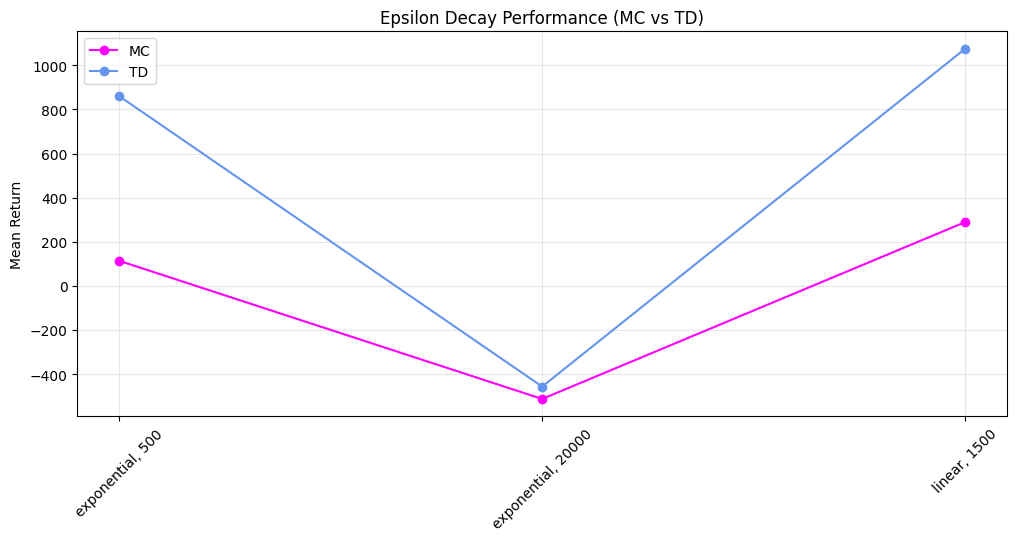

In [35]:
# tuning epsilon schedule using best alpha schedules identified earlier (17mins)
eps_results_mc = {}
eps_results_td = {}

for eps_type, eps_decay in eps_configs:
  # testing epsilon scheds and decay on MC control
  returns = []
  for seed in seeds_ctrl:
    np.random.seed(seed)
    theta, ep_pts, ret_hist = mc_control(n_eps_ctrl, hmm_stats, market_params, s_0,
                                         K, best_alpha_type_mc, best_alpha_c_mc,
                                         eps_type, eps_decay, eval_interval)
    returns.append(ret_hist[-1])
  eps_results_mc[(eps_type, eps_decay)] = np.mean(returns)

  # testing epsilon scheds and decay on TD control
  returns = []
  for seed in seeds_ctrl:
    np.random.seed(seed)
    theta, ep_pts, ret_hist = td_control(n_eps_ctrl, hmm_stats, market_params, s_0,
                                         K, best_alpha_type_td, best_alpha_c_td,
                                         eps_type, eps_decay, eval_interval)
    returns.append(ret_hist[-1])
  eps_results_td[(eps_type, eps_decay)] = np.mean(returns)

# identify best epslion combo for MC and TD
best_eps_mc = max(eps_results_mc, key=eps_results_mc.get)
best_eps_td = max(eps_results_td, key=eps_results_td.get)
best_eps_type_mc, best_eps_decay_mc = best_eps_mc
best_eps_type_td, best_eps_decay_td = best_eps_td
print(f'\nBest MC epsilon combo is {best_eps_mc}')
print(f'\nBest TD epsilon combo is {best_eps_td}')

# visualising epsilon sweep results
labels = [f"{t}, {d}" for (t,d) in eps_results_mc.keys()]

plt.figure(figsize=(12,5))
plt.plot(labels, eps_results_mc.values(), marker='o', label='MC',
         color='magenta')
plt.plot(labels, eps_results_td.values(), marker='o', label='TD',
         color='cornflowerblue')
plt.title("Epsilon Decay Performance (MC vs TD)")
plt.ylabel("Mean Return")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [36]:
# training final control with best alpha and epsilon configurations (10mins)
n_eps_final = 5000
eval_interval = 100
np.random.seed(21) # training on one seed bc not sweeping
mc_ctrl_theta, mc_ctrl_eps, mc_ctrl_returns = mc_control(n_eps_final, hmm_stats,
                                                         market_params, s_0, K,
                                                         best_alpha_type_mc,
                                                         best_alpha_c_mc,
                                                         best_eps_type_mc,
                                                         best_eps_decay_mc,
                                                         eval_interval)
np.random.seed(21) # train on one seed
td_ctrl_theta, td_ctrl_eps, td_ctrl_returns = td_control(n_eps_final, hmm_stats,
                                                         market_params, s_0,
                                                         K, best_alpha_type_td,
                                                         best_alpha_c_td,
                                                         best_eps_type_td,
                                                         best_eps_decay_td,
                                                         eval_interval)
# print summary of control results
df_alpha = pd.DataFrame({
    'alpha_schedule': list(alpha_results_mc.keys()),
    'MC_return': list(alpha_results_mc.values()),
    'TD_return': list(alpha_results_td.values())
})

df_eps = pd.DataFrame({
    'eps_type': [t for (t,d) in eps_results_mc.keys()],
    'eps_decay': [d for (t,d) in eps_results_mc.keys()],
    'MC_return': list(eps_results_mc.values()),
    'TD_return': list(eps_results_td.values())
})

print("\nAlpha sweep results:")
print(df_alpha.to_string(index=False))

print("\nEpsilon sweep results:")
print(df_eps.to_string(index=False))



Alpha sweep results:
alpha_schedule   MC_return   TD_return
    power c=50 -208.048642  477.459878
      log c=20 -269.335559 -126.908809

Epsilon sweep results:
   eps_type  eps_decay   MC_return   TD_return
exponential        500  113.615342  859.574685
exponential      20000 -512.145429 -456.199005
     linear       1500  288.880221 1074.127848


In [37]:
# evaluate final MC and TD policies
mc_policy = lambda state: {'target_delta': greedy_action(mc_ctrl_theta, state)}
td_policy = lambda state: {'target_delta': greedy_action(td_ctrl_theta, state)}

linear_mc_eval = evaluate_policy(mc_policy)
linear_td_eval = evaluate_policy(td_policy)

# printing evaluation
for name, r in [('Linear MC', linear_mc_eval), ('Linear TD', linear_td_eval)]:
    print(f"{name}: mean={r['pnl'].mean()}, std={r['pnl'].std()}, "
          f"turnover={r['turnover'].mean()}")
# compare to BS fixed vol to check for improvement
print(f"BS Fixed: mean={bs_fixed_eval['pnl'].mean()}, "
      f"std={bs_fixed_eval['pnl'].std()}, "
      f"turnover={bs_fixed_eval['turnover'].mean()}")

# print summary df of results and eval metrics
summary = build_summary({'BS Fixed': bs_fixed_eval,
                         'BS Rolling': bs_rolling_eval,
                         'Linear Q-learning MC': linear_mc_eval,
                         'Linear Q-learning TD(0)': linear_td_eval})
print(summary.round(1).to_string(index=False))

Linear MC: mean=862.1511225594921, std=5839.915358346163, turnover=0.5999999999999998
Linear TD: mean=982.0508561327982, std=5786.636904093698, turnover=3.3468
BS Fixed: mean=1022.1092588552668, std=1622.9651192551994, turnover=2.8449858628968707
                 policy  mean_pnl  std_pnl  sharpe  5th_pct  95th_pct  mean_tc  mean_turnover
               BS Fixed    1022.1   1623.0     0.6  -1949.1    3304.5    306.9            2.8
             BS Rolling     922.7   1946.4     0.5  -2555.6    3711.0    387.6            3.6
   Linear Q-learning MC     862.2   5839.9     0.1 -11755.2    6155.5     64.4            0.6
Linear Q-learning TD(0)     982.1   5786.6     0.2  -8719.9    9206.0    359.6            3.3


#Control: DQN extension from linear Q-learning
This improves on Q-learning because:
1. NN captures non-linear state interactions which linear Q-learning misses
2. The experience replay prevents MC from overfitting to lucky paths where its speculation happened to work
3. Uses a target network to stabilise TD targets
4. I now introduce a risk-adjusted reward to penalise directional speculation that allowed MC especially to make inconsistent supernormal profits

Aiming for DQN std to be ≤ b-s policies std and for DQN's 5th percentile to also not be worse than b-s policies.

In [38]:
# importing torch libraries for NN
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import random

In [39]:
# creating class for the Q-network
class Qnetwork(nn.Module):  # create nn with built in capabilities of nn.Module
  # 6 states (moneyness, time, current_delta, ref_delta, est_vol, hedge_error)
  # 21 actions to match discrete action space used in linear Q-learning
  # start with modest number of hidden layers to prevent overfitting
  def __init__(self, n_state=6, n_actions=21, hidden=64):
    super().__init__()
    # 2 hidden layers and 1 output layer
    self.net = nn.Sequential(
        nn.Linear(n_state, hidden),
        nn.ReLU(),
        nn.Linear(hidden, hidden),
        nn.ReLU(),
        nn.Linear(hidden, n_actions))

  def forward(self, x):
      return self.net(x)


# putting state variables in tensor format
def state_to_tensor(state, market_params):
  S = state['S_t']
  K = state['K']
  t = state['t']
  T = state['T']
  delta = state['delta_current']
  tao_annual = (T-t)/252

  # rolling vol calc as used previously
  spot_hist = state['spot_history']
  if len(spot_hist) > 5:
    recent = spot_hist[-5:]
    log_rets = np.log(recent[1:]/recent[:-1])
    est_vol = log_rets.std() * np.sqrt(252)
    if est_vol < 0.00000001:
      est_vol = market_params['sigma_fixed']
  else:
    est_vol = market_params['sigma_fixed']

  # b-s delta refernce using constant vol
  if tao_annual > 0:
    d1 = bs_d1(S, K, tao_annual, state['r_pln'], state['r_usd'],
               market_params['sigma_fixed'])
    bs_delta_ref = np.exp(-1 * state['r_usd'] * tao_annual)  * norm.cdf(d1)
  else:
    if S>K:
      bs_delta_ref = 1
    else:
      bs_delta_ref = 0

  return torch.tensor([S/K, (T-t)/T, delta, bs_delta_ref, est_vol,
                       abs(delta - bs_delta_ref)], dtype = torch.float32)

# creating replay buffer to store state transitions
class ReplayBuffer:
  def __init__(self, replay_memory_size=50000):
    self.buffer = deque(maxlen=replay_memory_size) # double ended queue (list w maxlen feature built in)

  # adds transition as tuple to deque
  def push(self, state, action_idx, reward, next_state, done):
    self.buffer.append((state, action_idx, reward, next_state, done))

  # picks batch size and random transitions from buffer without replacement
  def sample(self, batch_size):
    batch = random.sample(self.buffer, batch_size)
    # zip(*batch) transposes tupels so actions and states grouped
    states, actions, rewards, next_states, dones = zip(*batch)
    return(torch.stack(states), torch.tensor(actions, dtype=torch.long),
           torch.tensor(rewards, dtype=torch.float32), torch.stack(next_states),
           torch.tensor(dones, dtype=torch.float32)) # make done boolean float

  def __len__(self):
    return len(self.buffer)


# adjust rewards for risk to introduce convexity in rewards
def risk_adjust_reward(reward, lambda_risk=0.5, scale=10000):
  if reward < 0:
    return reward - lambda_risk * (reward**2) / scale
  else:
    return reward

In [40]:
# function for  DQN with experience replay training
def dqn_control(n_eps, hmm_stats, market_params, s_0, K, eval_interval=100,
                learning_rate=0.001, batch_size=64, buffer_size=50000,
                target_update_freq=200, eps_start=1, eps_end=0.01,
                eps_decay=2000, hidden=64, lambda_risk=0.5, risk_scale=10000,
                seed=21):
  np.random.seed(seed)
  torch.manual_seed(seed) # for random NN weights initialisation
  random.seed(seed)  # for replay buffer to pick transitions for transition batch

  actions = np.linspace(0, 1, 21)
  n_actions = len(actions)
  n_state = 6

  # creating 2 NNS one that learns and changes each step and other for stable targets in training
  q_net = Qnetwork(n_state, n_actions, hidden)
  target_net = Qnetwork(n_state, n_actions, hidden) # to compute TD targets (frozen)
  # make target's weights identical to q_net's weights
  target_net.load_state_dict(q_net.state_dict())
  target_net.eval()

  # set up optimiser for q_net
  optimiser = optim.Adam(q_net.parameters(), lr=learning_rate)
  # empty deque to store transitions as agent plays episodes
  buffer = ReplayBuffer(replay_memory_size=buffer_size)

  eval_points = []
  return_hist= [] # raw returns
  adj_return_hist = [] # risk-adjusted returns
  ep_returns = []
  ep_adj_returns =[]

  for ep in range(n_eps):
    # epsilon decay path
    epsilon = eps_end + (eps_start-eps_end) * np.exp(-1 * ep/eps_decay)

    # generating spots
    rng = np.random.default_rng(seed + ep)
    spots, regimes = price_sim(s_0, 40, hmm_stats, rng)

    # create env and episode
    T = 40
    dt = 1/252
    r_pln = market_params['r_pln']
    r_usd = market_params['r_usd']
    notional = market_params['notional']
    sigma_fixed = market_params['sigma_fixed']
    k1, k2, k3 = market_params['k1'], market_params['k2'], market_params['k3']
    tao_0 = T/252
    premium_per_unit = call_pricer(spots[0], K, tao_0, r_pln, r_usd, sigma_fixed)
    premium_pln = premium_per_unit * notional

    # initialise book for reward calcs
    delta_current = 0
    usd_held = 0
    cum_tc = 0
    cum_pln_spent = 0
    cum_interest_pln = 0
    cum_interest_usd = 0
    v_book_prev = 0

    ep_raw_reward = 0
    ep_adj_reward = 0

    # update as episode progresses
    for t in range(T):
      # building state
      state_dict = {'t':t, 'T': T, 'S_t':spots[t], 'K':K,
                    'delta_current':delta_current, 'spot_history':spots[:t+1],
                    'r_pln':r_pln, 'r_usd':r_usd, 'k1':k1, 'k2':k2, 'k3':k3}

      state_tensor = state_to_tensor(state_dict, market_params)

      # epsilon-greedy action execution
      if np.random.rand() < epsilon:
        action_idx = np.random.randint(n_actions)
      else:
        with torch.no_grad():
          q_values = q_net(state_tensor)
          action_idx = q_values.argmax().item()
      # def make sure delta between 0 and 1 jic
      target_delta = np.clip(actions[action_idx], 0, 1)

      # executing trade
      trade_delta = target_delta - delta_current
      trade_usd = trade_delta * notional

      # implementing transaction costs
      if abs(trade_usd) < 0.0000001:
        tc=0
      else:
        tc = k1 + (k2 * abs(trade_usd) + (k3 * abs(trade_usd) * spots[t]))

      # update book
      cum_tc += tc
      usd_held += trade_usd
      delta_current = target_delta
      cum_pln_spent += trade_usd * spots[t]

      # adding interest cash
      cum_interest_pln += premium_pln * r_pln * dt
      cum_interest_usd += usd_held * r_usd * dt

      # moving to next spot and book value
      s_next = spots[t+1]
      tao_next = (T-t-1)/252
      call_next = call_pricer(s_next, K, tao_next, r_pln, r_usd, sigma_fixed)
      v_book_now = ((-1 * call_next * notional) + premium_pln + cum_interest_pln
                     + (-1 * cum_pln_spent) + (usd_held * s_next)
                     + (cum_interest_usd * s_next) - cum_tc)
      # updating rewards
      raw_reward = v_book_now - v_book_prev
      v_book_prev = v_book_now

      # terminal step and unwind tcs
      done = (t == T-1)
      unwind_tc = 0
      if done:
        if abs(usd_held) > 0.00000001:
          unwind_tc = k1 + (k2 * abs(usd_held)) + (k3 * abs(usd_held) * s_next)
          cum_tc += unwind_tc
          v_book_now -= unwind_tc
          raw_reward -= unwind_tc

      # risk-adjust reward before storing in replay buffer
      adj_reward = risk_adjust_reward(raw_reward, lambda_risk, risk_scale)
      ep_raw_reward += raw_reward
      ep_adj_reward += adj_reward

      # building next state if not terminal
      if not done:
        next_state_dict = {'t':t+1, 'T':T, 'S_t':s_next, 'K':K,
                           'delta_current': delta_current,
                           'spot_history':spots[:t+2], 'r_pln':r_pln,
                           'r_usd':r_usd, 'k1':k1, 'k2':k2, 'k3':k3}
        next_state_tensor = state_to_tensor(next_state_dict, market_params)
      else:
        next_state_tensor = torch.zeros(n_state)

      # store risk-adjusted reward in replay buffer
      buffer.push(state_tensor, action_idx, adj_reward, next_state_tensor, done)
      if len(buffer) >= batch_size:
        b_states, b_actions, b_rewards, b_next_states, b_dones = buffer.sample(batch_size)
        # look up actions that were actually taken in each state
        q_current = q_net(b_states).gather(1, b_actions.unsqueeze(1)).squeeze(1)

        # backprop
        with torch.no_grad():
          q_next = target_net(b_next_states).max(dim=1).values
          td_targets = b_rewards + q_next * (1 - b_dones)

        # loss function
        loss = nn.MSELoss()(q_current, td_targets)

        optimiser.zero_grad()
        loss.backward()

        # grad clip for stability
        nn.utils.clip_grad_norm_(q_net.parameters(), max_norm=10)
        optimiser.step()

    # track returns
    ep_returns.append(ep_raw_reward)
    ep_adj_returns.append(ep_adj_reward)

    # update target network
    if (ep + 1) % target_update_freq == 0:
      target_net.load_state_dict(q_net.state_dict())

    # evaluate control each eval interval
    if (ep + 1) % eval_interval == 0:
      eval_points.append(ep + 1)
      mean_raw = np.mean(ep_returns[-eval_interval:])
      mean_adj = np.mean(ep_adj_returns[-eval_interval:])
      std_raw = np.std(ep_returns[-eval_interval:])
      return_hist.append(mean_raw)
      adj_return_hist.append(mean_adj)
      print(f'episode {ep + 1}: epsilon={epsilon}')
      print(f'raw mean PnL ={mean_raw}, raw std={std_raw}')
      print(f'adjusted mean PnL={mean_adj}, buffer={len(buffer)}')
  return q_net, eval_points, return_hist, adj_return_hist



In [41]:
# DQN greedy policy function
def dqn_policy_func(q_net, market_params):
  actions = np.linspace(0, 1, 21)
  def policy(state):
    state_tensor = state_to_tensor(state, market_params)
    with torch.no_grad():
      q_values = q_net(state_tensor)
      action_idx = q_values.argmax().item()
    target_delta = actions[action_idx]
    tao = (state['T'] - state['t']) /252
    return{
        'target_delta': target_delta, 'sigma_used': market_params['sigma_fixed'],
        'call_price': call_pricer(state['S_t'], state['K'], tao, state['r_pln'],
                                  state['r_usd'], market_params['sigma_fixed']),
        'bs_delta': target_delta # to match format of b-s policies
        }
  return policy

In [42]:
# training DQN (10mins)
K = s_0
dqn_net, dqn_eval_pts, dqn_raw_hist, dqn_adj_hist = dqn_control(
    n_eps=5000,
    hmm_stats=hmm_stats,
    market_params=market_params,
    s_0=s_0,
    K=K,
    eval_interval=100,
    learning_rate=0.001,
    batch_size=64,
    buffer_size=50000,
    target_update_freq=200,
    eps_start=1.0,
    eps_end=0.01,
    eps_decay=2000,
    hidden=64,
    lambda_risk=0.5,
    risk_scale=10000,
    seed=21,
)

episode 100: epsilon=0.9521881065550976
raw mean PnL =-115.9099982210384, raw std=6455.517369778181
adjusted mean PnL=-1223.4518142094773, buffer=4000
episode 200: epsilon=0.9062370503698229
raw mean PnL =-1040.0325153856788, raw std=6890.925849140697
adjusted mean PnL=-2359.1604048129807, buffer=8000
episode 300: epsilon=0.862527053639504
raw mean PnL =-1085.274605533097, raw std=6312.541294842561
adjusted mean PnL=-2286.0531831447092, buffer=12000
episode 400: epsilon=0.8209488186047948
raw mean PnL =-143.76016158157378, raw std=5325.2617452781205
adjusted mean PnL=-1258.781670066615, buffer=16000
episode 500: epsilon=0.7813983780209728
raw mean PnL =267.4724567230295, raw std=6652.059405007131
adjusted mean PnL=-730.8751311523464, buffer=20000
episode 600: epsilon=0.7437768351856743
raw mean PnL =-787.8406030761605, raw std=6474.900921031367
adjusted mean PnL=-2148.1980973465243, buffer=24000
episode 700: epsilon=0.7079901166456243
raw mean PnL =-873.4273085509753, raw std=7456.1568

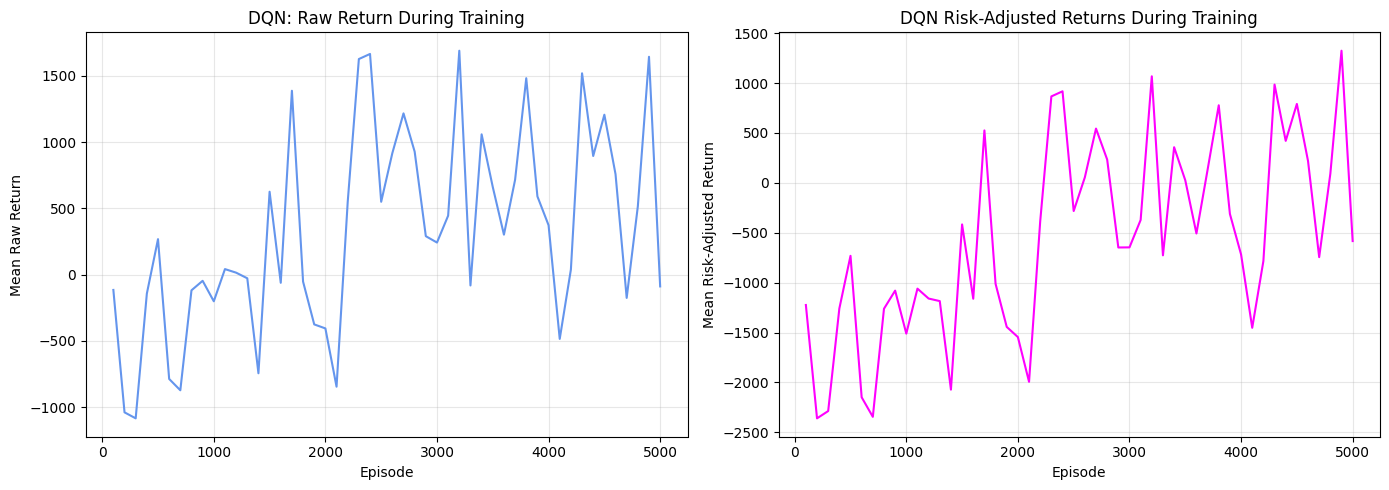

In [43]:
# visualising DQN learning  (raw and adjusted returns)
fig, axes = plt.subplots(1, 2, figsize =(14, 5))

# raw returns graph
axes[0].plot(dqn_eval_pts, dqn_raw_hist, color='cornflowerblue', linewidth=1.5)
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Mean Raw Return')
axes[0].set_title('DQN: Raw Return During Training')
axes[0].grid(True, alpha=0.3)
# adjusted returns graph
axes[1].plot(dqn_eval_pts, dqn_adj_hist, color='magenta', linewidth=1.5)
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Mean Risk-Adjusted Return')
axes[1].set_title('DQN Risk-Adjusted Returns During Training')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [44]:
# DQN v1 evaluation
dqn_v1_policy = dqn_policy_func(dqn_net, market_params) # rename for easy comparison
dqn_v1_eval = evaluate_policy(dqn_v1_policy)

# print summary table comparing results to bs policies and linear Q learning
summary = build_summary({'BS Fixed': bs_fixed_eval,
                         'BS Rolling': bs_rolling_eval,
                         'Linear Q Learning MC': linear_mc_eval,
                         'Linear Q learning TD': linear_td_eval,
                         'DQN v1': dqn_v1_eval})
print(summary.round(1).to_string(index=False))

              policy  mean_pnl  std_pnl  sharpe  5th_pct  95th_pct  mean_tc  mean_turnover
            BS Fixed    1022.1   1623.0     0.6  -1949.1    3304.5    306.9            2.8
          BS Rolling     922.7   1946.4     0.5  -2555.6    3711.0    387.6            3.6
Linear Q Learning MC     862.2   5839.9     0.1 -11755.2    6155.5     64.4            0.6
Linear Q learning TD     982.1   5786.6     0.2  -8719.9    9206.0    359.6            3.3
              DQN v1    1189.3   3488.0     0.3  -4985.0    6276.3    483.4            4.5


We can see that Black-Scholes delta hedging outperforms the control policies. This is because the TD agent is speculating and the MC agent never hedges. The risk adjustment is not severe enough to make the agent value having a low variance so I re-do the DQN control below with the following changes:


1.   Increase the lambda risk parameter so the agent understands that a loss is far more painful than the win from a profit
2.   Use variance penalty rather than a quadratic loss function s.t. the variance of rewards across the episode is in the loss function not just the individual negative rewards




In [45]:
# changing risk adjustment so all large rewards (pos and neg) are penalised
# idea is to incentivise agent to hedge (low var) over speulating (high var)
def risk_adjust_reward_v2(reward, lambda_risk=2, scale=10000):  # use lamdba=2
  return reward - (lambda_risk * ((reward**2)/scale))

# running DQN with a variance penalty
def dqn_control_v2(n_eps, hmm_stats, market_params, s_0, K, eval_interval=100,
                   learning_rate=0.001, batch_size=64, buffer_size=50000,
                   target_update_freq=200, eps_start=1, eps_end=0.01,
                   eps_decay=2000, hidden=64, lambda_risk=2, risk_scale=10000,
                   seed=21):
  np.random.seed(seed)
  torch.manual_seed(seed)
  random.seed(seed)

  actions = np.linspace(0, 1, 21)
  n_actions = len(actions)
  n_state = 6

  # run NN
  q_net = Qnetwork(n_state, n_actions, hidden)
  target_net = Qnetwork(n_state, n_actions, hidden)
  target_net.load_state_dict(q_net.state_dict())
  target_net.eval()

  # set up optimiser and buffer
  optimiser = optim.Adam(q_net.parameters(), lr=learning_rate)
  buffer = ReplayBuffer(replay_memory_size=buffer_size)

  # store returns and episode stats
  eval_points = []
  return_hist = []
  adj_return_hist = []
  ep_returns = []
  ep_adj_returns =[]
  ep_stds = [] # track within-episode std of daily returns

  # running episode & training
  for ep in range(n_eps):
    # decay epsilon in exploring
    epsilon = eps_end + (eps_start - eps_end) * np.exp(-1 * ep/eps_decay)
    T = 40
    rng = np.random.default_rng(seed + ep)
    spots, regimes = price_sim(s_0, T, hmm_stats, rng)

    # initialise params for episode
    dt = 1/252
    r_pln = market_params['r_pln']
    r_usd = market_params['r_usd']
    notional = market_params['notional']
    sigma_fixed = market_params['sigma_fixed']
    k1, k2, k3 = market_params['k1'], market_params['k2'], market_params['k3']
    tao_0 = T/252
    premium_per_unit = call_pricer(spots[0], K, tao_0, r_pln, r_usd, sigma_fixed)
    premium_pln = premium_per_unit * notional

    # intialise states
    delta_current = 0
    usd_held = 0
    cum_tc = 0
    cum_pln_spent = 0
    cum_interest_pln = 0
    cum_interest_usd = 0
    v_book_prev = 0

    # intialising rewards
    ep_raw_reward = 0
    ep_adj_reward = 0
    step_rewards = []  # storing each day's rewards to calculate s.d

    for t in range(T):
      state_dict = {'t':t, 'T':T, 'S_t':spots[t], 'K':K,
                    'delta_current': delta_current, 'spot_history': spots[:t+1],
                    'r_pln': r_pln, 'r_usd': r_usd, 'k1': k1, 'k2':k2, 'k3':k3}

      # store state as tensor for NN
      state_tensor = state_to_tensor(state_dict, market_params)
      # exploration following epsilon greedy
      if np.random.rand() < epsilon:
        action_idx = np.random.randint(n_actions)
      else:
        with torch.no_grad():
          q_values = q_net(state_tensor)
          action_idx = q_values.argmax().item()

      target_delta = np.clip(actions[action_idx], 0, 1) # update target delta

      # execute trades
      trade_delta = target_delta - delta_current
      trade_usd = trade_delta * notional

      # incur transaction costs
      if abs(trade_usd) < 0.000001:
        tc = 0
      else:
        tc = k1 + (k2 * abs(trade_usd))  + (k3 * abs(trade_usd) * spots[t])

      # update book
      cum_tc += tc
      usd_held += trade_usd
      delta_current = target_delta
      cum_pln_spent += trade_usd * spots[t]
      cum_interest_pln += premium_pln * r_pln * dt
      cum_interest_usd += usd_held * r_usd * dt

      # next state
      s_next = spots[t+1]
      tao_next = (T-t-1)/252
      call_next = call_pricer(s_next, K, tao_next, r_pln, r_usd, sigma_fixed)
      v_book_now = ((-1 * call_next * notional) + premium_pln + cum_interest_pln
                    - cum_pln_spent + (usd_held * s_next) +
                    (cum_interest_usd * s_next) - cum_tc)

      raw_reward = v_book_now - v_book_prev
      v_book_prev = v_book_now

      # unwind book at terminal state
      if t == (T-1):
        done = True
      else:
        done = False

      unwind_tc = 0
      if done:
        if abs(usd_held) > 0.0000001:
          unwind_tc = k1 + (k2 * abs(usd_held)) + (k3 * abs(usd_held) * s_next)
        cum_tc += unwind_tc
        v_book_now -= unwind_tc
        raw_reward -= unwind_tc

      # adjust all rewards (even if positive to discourage speculating)
      adj_reward = risk_adjust_reward_v2(raw_reward, lambda_risk, risk_scale)
      ep_raw_reward += raw_reward
      ep_adj_reward += adj_reward
      step_rewards.append(raw_reward)

      if not done:
        next_state_dict = {'t':t+1, 'T':T, 'S_t':s_next, 'K':K,
                           'delta_current':delta_current,
                           'spot_history':spots[:t+2], 'r_pln':r_pln,
                           'r_usd':r_usd, 'k1':k1, 'k2':k2, 'k3':k3}
        next_state_tensor = state_to_tensor(next_state_dict, market_params)
      else:
        next_state_tensor = torch.zeros(n_state)

      buffer.push(state_tensor, action_idx, adj_reward, next_state_tensor, done)

      # if buffer full start sampling batches from buffer
      if len(buffer) >= batch_size:
        b_states, b_actions, b_rewards, b_next_states, b_dones = buffer.sample(batch_size)
        q_current = q_net(b_states).gather(1, b_actions.unsqueeze(1)).squeeze(1)
        with torch.no_grad():
          q_next = target_net(b_next_states).max(dim=1).values
          td_targets = b_rewards  + q_next * (1-b_dones)

        # calculate loss
        loss = nn.MSELoss()(q_current, td_targets)
        # run gradient update
        optimiser.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(q_net.parameters(), max_norm=10)
        optimiser.step()

    # track values
    ep_returns.append(ep_raw_reward)
    ep_adj_returns.append(ep_adj_reward)
    ep_stds.append(np.std(step_rewards))


    if (ep+1) % target_update_freq == 0:
      target_net.load_state_dict(q_net.state_dict())

    # evaluate DQN at eval intervals
    if (ep+1) % eval_interval == 0:
      eval_points.append(ep+1)
      mean_raw = np.mean(ep_returns[-eval_interval:])
      mean_adj = np.mean(ep_adj_returns[-eval_interval:])
      std_raw = np.std(ep_returns[-eval_interval:])
      mean_step_std = np.mean(ep_stds[-eval_interval:])
      return_hist.append(mean_raw)
      adj_return_hist.append(mean_adj)
      print(f'ep {ep+1}: epsilon={epsilon},'
      f'raw returns={mean_raw} (std={std_raw})'
      f'adj returns ={mean_adj} (std={mean_step_std})')

  return q_net, eval_points, return_hist, adj_return_hist

In [46]:
# running DQN with lambda risk parameter = 2
K = s_0
dqn_net_v2, dqn_pts_v2, dqn_raw_v2, dqn_adj_v2 = dqn_control_v2(
    n_eps=5000, hmm_stats=hmm_stats, market_params=market_params,
    s_0=s_0, K=K, lambda_risk=2, risk_scale=10000, seed=21)

ep 100: epsilon=0.9521881065550976,raw returns=-251.88113453311283 (std=6419.294913287951)adj returns =-7537.954271075926 (std=869.121969674195)
ep 200: epsilon=0.9062370503698229,raw returns=-1010.6550149218309 (std=7017.596473917333)adj returns =-9970.134366701343 (std=979.1208946254833)
ep 300: epsilon=0.862527053639504,raw returns=-981.9076969542793 (std=6289.613029141513)adj returns =-8696.264584439688 (std=915.2996294555553)
ep 400: epsilon=0.8209488186047948,raw returns=-66.9630133494539 (std=5457.828744548068)adj returns =-7690.978877241748 (std=901.6683461389621)
ep 500: epsilon=0.7813983780209728,raw returns=353.9139588385887 (std=5815.659118772475)adj returns =-5633.389938220242 (std=810.0442544059019)
ep 600: epsilon=0.7437768351856743,raw returns=-632.2514036165967 (std=5469.058368459961)adj returns =-7601.45396216681 (std=869.679995308138)
ep 700: epsilon=0.7079901166456243,raw returns=-717.6992397500941 (std=5821.68696772153)adj returns =-7496.97843332354 (std=848.582263

In [47]:
# running DQN with lambda risk parameter = 5
K = s_0
dqn_net_v2s, dqn_pts_v2s, dqn_raw_v2s, dqn_adj_v2s = dqn_control_v2(
    n_eps=5000, hmm_stats=hmm_stats, market_params=market_params,
    s_0=s_0, K=K, lambda_risk=5, risk_scale=10000, seed=21)

ep 100: epsilon=0.9521881065550976,raw returns=-268.4094125158343 (std=6412.337870960835)adj returns =-18454.629158728454 (std=868.461833316478)
ep 200: epsilon=0.9062370503698229,raw returns=-1010.8135087673334 (std=7012.333579901168)adj returns =-23332.015263399786 (std=978.265914695159)
ep 300: epsilon=0.862527053639504,raw returns=-967.6113303195665 (std=6425.065565742994)adj returns =-20037.964822407943 (std=909.3450372154315)
ep 400: epsilon=0.8209488186047948,raw returns=-83.57738591788453 (std=5465.812806047906)adj returns =-19812.163173611294 (std=919.8643409753441)
ep 500: epsilon=0.7813983780209728,raw returns=376.49208680744334 (std=6041.38512117999)adj returns =-15613.764841238617 (std=835.1956139348259)
ep 600: epsilon=0.7437768351856743,raw returns=-388.6681315420278 (std=5847.424735482087)adj returns =-19539.4376209173 (std=914.4752665658953)
ep 700: epsilon=0.7079901166456243,raw returns=-491.41112182927077 (std=6275.072532316435)adj returns =-19760.293705764772 (std=9

In [48]:
# evaluate DQN v2 (both lambdas)
dqn_v2_policy = dqn_policy_func(dqn_net_v2, market_params) # rename
dqn_v2_eval = evaluate_policy(dqn_v2_policy)
dqn_v2_lamb5_policy = dqn_policy_func(dqn_net_v2s, market_params) # rename
dqn_v2_lamb5_eval = evaluate_policy(dqn_v2_lamb5_policy)

# compare all existing models
summary = build_summary({'BS Fixed': bs_fixed_eval, 'BS Rolling': bs_rolling_eval,
                         'Linear Q Learning MC': linear_mc_eval,
                         'Linear Q Learning TD': linear_td_eval,
                         'DQN v1 (lambda=0.5)': dqn_v1_eval,
                         'DQN v2 (lambda=2)': dqn_v2_eval,
                         'DQN v2 (lambda=5)': dqn_v2_lamb5_eval})

print(summary.round(1).to_string(index=False))

              policy  mean_pnl  std_pnl  sharpe  5th_pct  95th_pct  mean_tc  mean_turnover
            BS Fixed    1022.1   1623.0     0.6  -1949.1    3304.5    306.9            2.8
          BS Rolling     922.7   1946.4     0.5  -2555.6    3711.0    387.6            3.6
Linear Q Learning MC     862.2   5839.9     0.1 -11755.2    6155.5     64.4            0.6
Linear Q Learning TD     982.1   5786.6     0.2  -8719.9    9206.0    359.6            3.3
 DQN v1 (lambda=0.5)    1189.3   3488.0     0.3  -4985.0    6276.3    483.4            4.5
   DQN v2 (lambda=2)    1070.9   2178.0     0.5  -3243.9    3930.0    296.5            2.8
   DQN v2 (lambda=5)    1027.4   1918.2     0.5  -2558.0    3730.6    302.5            2.8


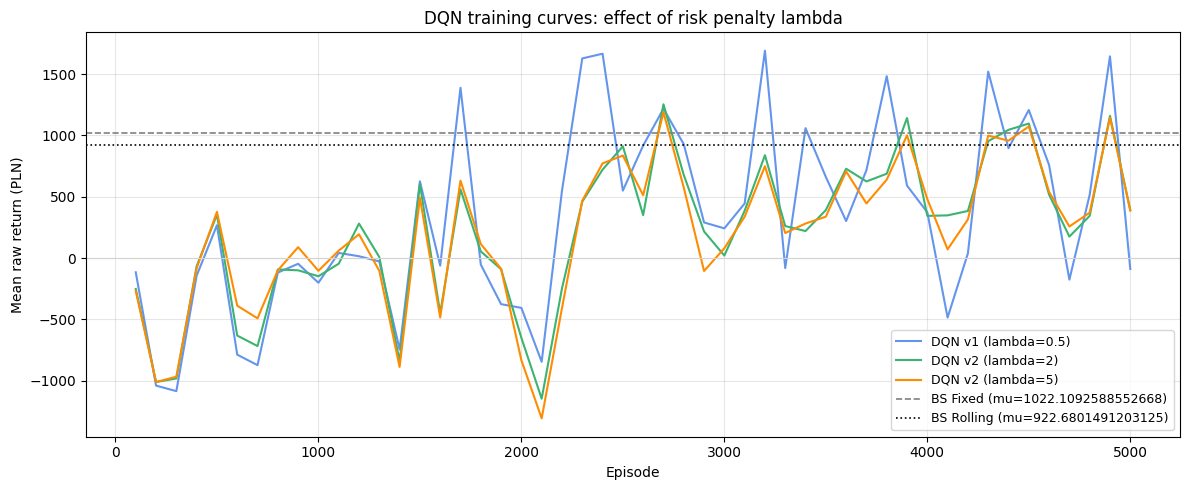

In [49]:
# visualise training curves for DQN v2
fig, ax = plt.subplots(figsize=(12, 5))
bs_mean = bs_fixed_eval['pnl'].mean()
rv_mean = bs_rolling_eval['pnl'].mean()

ax.plot(dqn_eval_pts, dqn_raw_hist, color='cornflowerblue',
        linewidth=1.5, label='DQN v1 (lambda=0.5)')
ax.plot(dqn_pts_v2, dqn_raw_v2, color='mediumseagreen',
        linewidth=1.5, label='DQN v2 (lambda=2)')
ax.plot(dqn_pts_v2s, dqn_raw_v2s, color='darkorange',
        linewidth=1.5, label='DQN v2 (lambda=5)')

ax.axhline(bs_mean, color='grey', linestyle='--', linewidth=1.2,
           label=f'BS Fixed (mu={bs_mean})')
ax.axhline(rv_mean, color='black', linestyle=':', linewidth=1.2,
           label=f'BS Rolling (mu={rv_mean})')
ax.axhline(0, color='lightgrey', linewidth=0.8)

ax.set_xlabel('Episode')
ax.set_ylabel('Mean raw return (PLN)')
ax.set_title('DQN training curves: effect of risk penalty lambda')
ax.legend(fontsize=9, loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**DQN V3**

By analysing the results, we can see that the agent only just beats b-s and that too hardly. Reviewing the variance penalty, it's too blunt because it doesn't incentivise the agent to not speculate but rather to not make massive profits (neg or pos).

Therefore, I create an improved reward design that incentivises the agent to have excess returns compared to black scholes whilst also penalising variance to encourage it not to speculate.

In [50]:
# DQN model 3 (try with lambda 0.5 first and then change if still speculating)
def dqn_control_v3(n_eps, hmm_stats, market_params, s_0, K, eval_interval=100,
                   learning_rate=0.001, batch_size=64, buffer_size=50000,
                   target_update_freq=200, eps_start=1, eps_end=0.01,
                   eps_decay=2000, hidden=64, lambda_var=0.5, var_scale=10000,
                   seed=21):
  np.random.seed(seed)
  torch.manual_seed(seed)
  random.seed(seed)

  actions = np.linspace(0, 1, 21)
  n_actions = len(actions)
  n_state = 6

  # create Q-network and target network
  q_net = Qnetwork(n_state, n_actions, hidden)
  target_net = Qnetwork(n_state, n_actions, hidden)
  target_net.load_state_dict(q_net.state_dict())
  target_net.eval()

  # setup optimiser and buffer
  optimiser = optim.Adam(q_net.parameters(), lr=learning_rate)
  buffer = ReplayBuffer(replay_memory_size=buffer_size)

  # tracking
  eval_points = []
  ret_hist = [] # raw returns
  excess_ret_hist = [] # excess returns over bs delta
  bs_ret_hist = [] # baseline bs returns
  ep_rets = []
  ep_excess_rets = []
  ep_bs_rets = []

  # training
  for ep in range(n_eps):
    epsilon = eps_end + (eps_start - eps_end) * np.exp(-1 * ep/ eps_decay)
    T= 40
    rng = np.random.default_rng(seed + ep)
    spots, regimes = price_sim(s_0, T, hmm_stats, rng)

    # set up params
    dt = 1/252
    r_pln = market_params['r_pln']
    r_usd = market_params['r_usd']
    notional = market_params['notional']
    sigma_fixed = market_params['sigma_fixed']
    k1, k2, k3 = market_params['k1'], market_params['k2'], market_params['k3']
    tao_0 = T/252
    premium_per_unit = call_pricer(spots[0], K, tao_0, r_pln, r_usd, sigma_fixed)
    premium_pln = premium_per_unit * notional

    # initialise book (agent)
    delta_current = 0
    usd_held = 0
    cum_tc = 0
    cum_pln_spent =0
    cum_interest_pln = 0
    cum_interest_usd = 0
    v_book_prev = 0

    # initialise shadow book to compare bs policy
    bs_delta_current = 0
    bs_usd_held =0
    bs_cum_tc = 0
    bs_cum_pln_spent =0
    bs_cum_interest_pln = 0
    bs_cum_interest_usd = 0
    bs_v_book_prev = 0

    # initialise rewards
    ep_raw_reward = 0
    ep_excess_reward = 0
    ep_bs_reward = 0

    for t in range(T):
      # setup environment
      state_dict = {
                't': t, 'T': T, 'S_t': spots[t], 'K': K,
                'delta_current': delta_current, 'spot_history': spots[:t + 1],
                'r_pln': r_pln, 'r_usd': r_usd,
                'k1': k1, 'k2': k2, 'k3': k3}

      state_tensor = state_to_tensor(state_dict, market_params)
      if np.random.rand() < epsilon:
        action_idx = np.random.randint(n_actions)
      else:
        with torch.no_grad():
          q_values = q_net(state_tensor)
          action_idx = q_values.argmax().item()

      target_delta = np.clip(actions[action_idx], 0, 1)

      # execute trade (agent)
      trade_delta = target_delta - delta_current
      trade_usd = trade_delta * notional
      # incur transaction costs
      if abs(trade_usd) < 0.0000001:
        tc = 0.0
      else:
        tc = k1 + (k2 * abs(trade_usd)) + (k3 * abs(trade_usd) * spots[t])
      # update book
      cum_tc += tc
      usd_held += trade_usd
      delta_current = target_delta
      cum_pln_spent += trade_usd * spots[t]
      cum_interest_pln += premium_pln * r_pln * dt
      cum_interest_usd += usd_held * r_usd * dt

      # execute trade on bs shadow/reference book
      tao_annual = (T - t) / 252
      # calc target delta if call not expired
      if tao_annual > 0:
        d1 = bs_d1(spots[t], K, tao_annual, r_pln, r_usd, sigma_fixed)
        bs_target = np.exp(-r_usd * tao_annual) * norm.cdf(d1)
      else:
        bs_target = 1.0 if spots[t] > K else 0.0

      bs_trade_delta = bs_target - bs_delta_current
      bs_trade_usd = bs_trade_delta * notional

      # incur transaction costs
      if abs(bs_trade_usd) < 0.000000001:
        bs_tc = 0.0
      else:
        bs_tc = k1 + (k2 * abs(bs_trade_usd)) + (k3 * abs(bs_trade_usd) * spots[t])

      # update shadow book
      bs_cum_tc += bs_tc
      bs_usd_held += bs_trade_usd
      bs_delta_current = bs_target
      bs_cum_pln_spent += bs_trade_usd * spots[t]
      bs_cum_interest_pln += premium_pln * r_pln * dt
      bs_cum_interest_usd += bs_usd_held * r_usd * dt

      # move to next state
      s_next = spots[t+1]
      tao_next = (T - t -1)/252
      call_next = call_pricer(s_next, K, tao_next, r_pln, r_usd, sigma_fixed)

      # update book value (agent)
      v_book_now = ((-1 * call_next * notional) + premium_pln + cum_interest_pln
                    - cum_pln_spent + (usd_held * s_next) +
                     (cum_interest_usd * s_next) - cum_tc)

      # update shadow/ref book value
      bs_v_book_now = ((-1 * call_next * notional) + premium_pln + bs_cum_interest_pln
                    - bs_cum_pln_spent + (bs_usd_held * s_next) +
                     (bs_cum_interest_usd * s_next) - bs_cum_tc)

      # unwind both books at terminal step
      if t == T-1:
        done = True
      else:
        done = False

      if done:
        # unwinding agent's book
        if abs(usd_held) > 0.000000001:
          unwind_tc = k1 + (k2 * abs(usd_held)) + (k3 * abs(usd_held) * s_next)
          cum_tc += unwind_tc
          v_book_now -= unwind_tc

        # unwinding shadow/ref book
        if abs(bs_usd_held) > 0.000000001:
          bs_unwind_tc = k1 + (k2 * abs(bs_usd_held)) + (k3 * abs(bs_usd_held) * s_next)
          bs_cum_tc += bs_unwind_tc
          bs_v_book_now -= bs_unwind_tc

      # calculate rewards
      raw_reward = v_book_now - v_book_prev
      bs_reward = bs_v_book_now - bs_v_book_prev

      # calculate excess rewards i.e did agent beat bs baseline
      excess = raw_reward - bs_reward

      # penalise variance of excess so agent consistently beats bs not speculating
      shaped_reward = excess - lambda_var * ((excess ** 2)/ var_scale)

      # update book value
      v_book_prev = v_book_now
      bs_v_book_prev = bs_v_book_now

      # track rewards
      ep_raw_reward += raw_reward
      ep_bs_reward += bs_reward
      ep_excess_reward += excess

      # move to next state
      if not done:
        next_state_dict = {'t': t + 1, 'T': T, 'S_t': s_next, 'K': K,
                    'delta_current': delta_current,'spot_history': spots[:t + 2]
                    ,'r_pln': r_pln, 'r_usd': r_usd, 'k1': k1, 'k2': k2,
                    'k3': k3}
        next_state_tensor = state_to_tensor(next_state_dict, market_params)
      else:
        next_state_tensor = torch.zeros(n_state)

      # store shaped reward in buffer
      buffer.push(state_tensor, action_idx, shaped_reward, next_state_tensor, done)

      # train on batch from buffer
      if len(buffer) >= batch_size:
        b_states, b_actions, b_rewards, b_next_states, b_dones = buffer.sample(batch_size)
        q_current = q_net(b_states).gather(1, b_actions.unsqueeze(1)).squeeze(1)
        with torch.no_grad():
          q_next = target_net(b_next_states).max(dim=1).values
          td_targets = b_rewards + q_next * (1 - b_dones)

        loss = nn.MSELoss()(q_current, td_targets)
        optimiser.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(q_net.parameters(), max_norm=10)
        optimiser.step()

    # track stats at end of episode
    ep_rets.append(ep_raw_reward)
    ep_excess_rets.append(ep_excess_reward)
    ep_bs_rets.append(ep_bs_reward)

    if (ep+1) % target_update_freq == 0:
      target_net.load_state_dict(q_net.state_dict())

    # calculate averages at each eval interval
    if (ep+1) % eval_interval == 0:
      eval_points.append(ep+1)
      mean_raw = np.mean(ep_rets[-eval_interval:])
      mean_excess = np.mean(ep_excess_rets[-eval_interval:])
      mean_bs = np.mean(ep_bs_rets[-eval_interval:])
      std_raw = np.std(ep_rets[-eval_interval:])
      ret_hist.append(mean_raw)
      excess_ret_hist.append(mean_excess)
      bs_ret_hist.append(mean_bs)
      print(f'ep {ep+1}: eps={epsilon:.3f}, '
                  f'agent={mean_raw:.0f} (std={std_raw:.0f}), '
                  f'BS={mean_bs:.0f}, '
                  f'excess={mean_excess:.0f}')

  return q_net, eval_points, ret_hist, excess_ret_hist, bs_ret_hist

In [51]:
# running DQN v3 with lambda = 0.5
K = s_0
dqn_net_v3, dqn_pts_v3, dqn_raw_v3, dqn_excess_v3, dqn_bs_v3 = dqn_control_v3(
    n_eps=5000, hmm_stats=hmm_stats, market_params=market_params,
    s_0=s_0, K=K, lambda_var=0.5, var_scale=10000, seed=21)

ep 100: eps=0.952, agent=-238 (std=6462), BS=1314, excess=-1552
ep 200: eps=0.906, agent=-1015 (std=6905), BS=838, excess=-1853
ep 300: eps=0.863, agent=-1088 (std=6244), BS=1057, excess=-2145
ep 400: eps=0.821, agent=-132 (std=5318), BS=938, excess=-1070
ep 500: eps=0.781, agent=312 (std=6234), BS=1169, excess=-857
ep 600: eps=0.744, agent=-537 (std=5654), BS=885, excess=-1422
ep 700: eps=0.708, agent=-708 (std=6138), BS=535, excess=-1242
ep 800: eps=0.674, agent=58 (std=5624), BS=1024, excess=-966
ep 900: eps=0.642, agent=166 (std=5288), BS=1073, excess=-908
ep 1000: eps=0.611, agent=13 (std=6046), BS=829, excess=-816
ep 1100: eps=0.581, agent=-245 (std=5758), BS=1127, excess=-1372
ep 1200: eps=0.554, agent=193 (std=5789), BS=1005, excess=-812
ep 1300: eps=0.527, agent=-98 (std=5591), BS=869, excess=-967
ep 1400: eps=0.502, agent=-798 (std=6402), BS=829, excess=-1627
ep 1500: eps=0.478, agent=752 (std=6110), BS=738, excess=14
ep 1600: eps=0.455, agent=-390 (std=4959), BS=872, excess=

In [52]:
# evaluating DQN v3
dqn_v3_policy = dqn_policy_func(dqn_net_v3, market_params)
dqn_v3_eval = evaluate_policy(dqn_v3_policy)

# compare DQN v3 results to existing models
summary = build_summary({
    'BS Fixed':       bs_fixed_eval,
    'BS Rolling':     bs_rolling_eval,
    'Linear Q-learning MC':linear_mc_eval,'Linear Q-learning TD':linear_td_eval,
    'DQN v1 (lambda=0.5)':dqn_v1_eval,'DQN v2 (lambda=2)':dqn_v2_eval,
    'DQN v2 (lambda=5)':dqn_v2_lamb5_eval,'DQN v3':dqn_v3_eval})
print(summary.round(1).to_string(index=False))

              policy  mean_pnl  std_pnl  sharpe  5th_pct  95th_pct  mean_tc  mean_turnover
            BS Fixed    1022.1   1623.0     0.6  -1949.1    3304.5    306.9            2.8
          BS Rolling     922.7   1946.4     0.5  -2555.6    3711.0    387.6            3.6
Linear Q-learning MC     862.2   5839.9     0.1 -11755.2    6155.5     64.4            0.6
Linear Q-learning TD     982.1   5786.6     0.2  -8719.9    9206.0    359.6            3.3
 DQN v1 (lambda=0.5)    1189.3   3488.0     0.3  -4985.0    6276.3    483.4            4.5
   DQN v2 (lambda=2)    1070.9   2178.0     0.5  -3243.9    3930.0    296.5            2.8
   DQN v2 (lambda=5)    1027.4   1918.2     0.5  -2558.0    3730.6    302.5            2.8
              DQN v3    1067.3   2822.2     0.4  -4010.6    4994.3    343.4            3.2


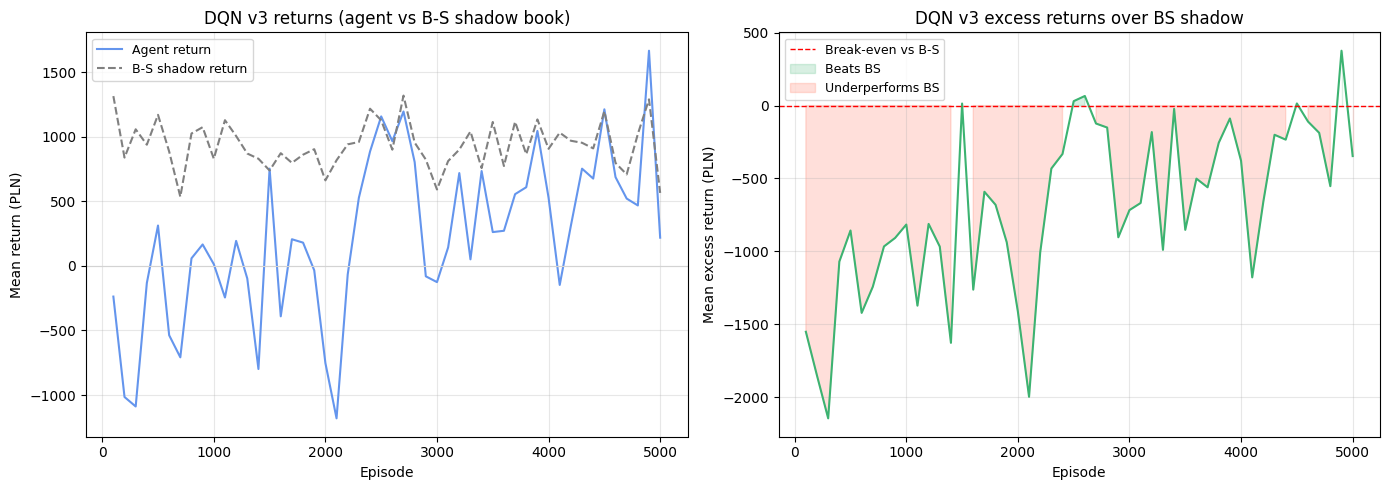

In [53]:
# visualisng DQN v3 results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bs_mean = bs_fixed_eval['pnl'].mean()

# agent vs shadow book plot
axes[0].plot(dqn_pts_v3, dqn_raw_v3, color='cornflowerblue',
             linewidth=1.5, label='Agent return')
axes[0].plot(dqn_pts_v3, dqn_bs_v3, color='grey', linewidth=1.5,
             linestyle='--', label='B-S shadow return')
axes[0].axhline(0, color='lightgrey', linewidth=0.8)
axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Mean return (PLN)')
axes[0].set_title('DQN v3 returns (agent vs B-S shadow book)')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# excess returns with shading plot
axes[1].plot(dqn_pts_v3, dqn_excess_v3, color='mediumseagreen', linewidth=1.5)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1, label='Break-even vs B-S')
axes[1].fill_between(dqn_pts_v3, 0, dqn_excess_v3,
                     where=np.array(dqn_excess_v3) > 0,
                     alpha=0.2, color='mediumseagreen', label='Beats BS')
axes[1].fill_between(dqn_pts_v3, 0, dqn_excess_v3,
                     where=np.array(dqn_excess_v3) <= 0,
                     alpha=0.2, color='tomato', label='Underperforms BS')
axes[1].set_xlabel('Episode'); axes[1].set_ylabel('Mean excess return (PLN)')
axes[1].set_title('DQN v3 excess returns over BS shadow')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

V3 DQN having greater variance than V2 shows that the agent is trading differently and not just being a risk-averse speculator. This is because it is fundamentally trading differently which introduces greater std even when it's not speculating. It's clear it isn't speculating because in the training plot v3's returns follow the Black scholes shadow book and doesn't diverge wildly which suggests it's hedging.

However, the excess return plot is almost entirely negative. This means that v3 earns less than Black Scholes at nearly every evaluation point in training but the ideal control policy should outperform Black-Scholes just slightly by optimising when to trade based on trasaction costs. One reason v3 underperforms could be the discrete action space which causes the delta trade to always be slightly wrong and the error compounds which causes it to underperform. This motivates the use of MCPG where action space becomes continuous.

# Running Monte-Carlo Policy Gradient control (REINFORCE)
This is consistent with literature and extends DQN because now there's no need for a discrete action space. Also MC outperformed TD in prediction because spot is unpredictable so the environment is uncertain which further supports this. This is inspired by Neagu et al.

In [54]:
# creating class for REINFORCE nn (state input, action output)
class PolicyNetwork(nn.Module):
  def __init__(self, n_state=6, hidden=64):
    super().__init__()
    self.shared = nn.Sequential(
        nn.Linear(n_state, hidden),
        nn.ReLU(),
        nn.Linear(hidden, hidden),
        nn.ReLU())
    self.mean_head = nn.Linear(hidden, 1)
    self.log_std_head = nn.Linear(hidden, 1)

  # creating forward function move state tensor through NN
  def forward(self, x):
    h = self.shared(x) # network's learned representation of state tensor
    mean = torch.sigmoid(self.mean_head(h))  # 0-1 guess for delta
    log_std = self.log_std_head(h)
    log_std = torch.clamp(log_std, -3, 0)
    return mean.squeeze(-1), log_std.squeeze(-1)

In [55]:
# create function to run REINFORCE
def mcpg_control(n_eps, hmm_stats, market_params, s_0, K, eval_interval=100,
                 learning_rate=0.001, hidden=64, lambda_var=0.5, var_scale=10000
                 , seed=21):
  np.random.seed(seed)
  torch.manual_seed(seed)
  random.seed(seed)

  n_state=6
  policy_net = PolicyNetwork(n_state, hidden)
  optimiser = optim.Adam(policy_net.parameters(), lr=learning_rate)

  # set up environment tracking
  eval_points = []
  ret_hist = []
  excess_ret_hist= []
  ep_rets = []
  ep_excess_rets = []

  # training
  for ep in range(n_eps):
    T = 40
    rng = np.random.default_rng(seed + ep)
    spots, regimes = price_sim(s_0, T, hmm_stats, rng)

    # set up environment
    dt = 1/252
    r_pln = market_params['r_pln']
    r_usd = market_params['r_usd']
    notional = market_params['notional']
    sigma_fixed = market_params['sigma_fixed']
    k1, k2, k3 = market_params['k1'], market_params['k2'], market_params['k3']
    tao_0 = T/252
    premium_per_unit = call_pricer(spots[0], K, tao_0, r_pln, r_usd,
                                   sigma_fixed)
    premium_pln = premium_per_unit * notional

    # initialise agent book
    delta_current = 0
    usd_held = 0
    cum_tc = 0
    cum_pln_spent = 0
    cum_interest_pln = 0
    cum_interest_usd = 0
    v_book_prev = 0

    # initialise shadow/reference book
    bs_delta_current = 0
    bs_usd_held = 0
    bs_cum_tc = 0
    bs_cum_pln_spent = 0
    bs_cum_interest_pln = 0
    bs_cum_interest_usd = 0
    bs_v_book_prev = 0

    # store log probabilities and rewards for update
    log_probs = []
    raw_rewards = []
    bs_rewards =[]

    # running REINFORCE algo
    for t in range(T):
      state_dict = {'t':t, 'T':T, 'S_t':spots[t], 'K':K,
                    'delta_current':delta_current, 'spot_history':spots[:t+1],
                    'r_pln':r_pln, 'r_usd':r_usd, 'k1':k1, 'k2':k2, 'k3':k3}
      state_tensor = state_to_tensor(state_dict, market_params)

      # sample action from policy network
      mean, log_std = policy_net(state_tensor)
      std = torch.exp(log_std)
      dist = torch.distributions.Normal(mean, std)
      raw_action = dist.sample()
      target_delta = torch.clamp(raw_action, 0, 1).item()
      log_prob = dist.log_prob(raw_action)
      log_probs.append(log_prob)

      # execute trade (agent)
      trade_delta = target_delta - delta_current
      trade_usd = trade_delta * notional

      # incur transaction costs
      if abs(trade_usd) < 0.0000001:
        tc = 0
      else:
        tc = k1 + (k2 * abs(trade_usd)) + (k3 * abs(trade_usd) * spots[t])

      # update agent book
      cum_tc += tc
      usd_held += trade_usd
      delta_current = target_delta
      cum_pln_spent += trade_usd * spots[t]
      cum_interest_pln += premium_pln * r_pln * dt
      cum_interest_usd += usd_held * r_usd * dt

      # execute BS shadow trade
      tao_annual = (T - t) / 252

      # calcualte bs fixed vol delta
      if tao_annual > 0:
        d1 = bs_d1(spots[t], K, tao_annual, r_pln, r_usd, sigma_fixed)
        bs_target = np.exp(-r_usd * tao_annual) * norm.cdf(d1)
      else:
        bs_target = 1.0 if spots[t] > K else 0.0

      bs_trade_delta = bs_target - bs_delta_current
      bs_trade_usd = bs_trade_delta * notional

      # incur transaction costs
      if abs(bs_trade_usd) < 0.0000001:
        bs_tc = 0
      else:
        bs_tc = k1 + (k2 * abs(bs_trade_usd)) + (k3 * abs(bs_trade_usd) * spots[t])

      # update bs book value
      bs_cum_tc += bs_tc
      bs_usd_held += bs_trade_usd
      bs_delta_current = bs_target
      bs_cum_pln_spent += bs_trade_usd * spots[t]
      bs_cum_interest_pln += premium_pln * r_pln * dt
      bs_cum_interest_usd += bs_usd_held * r_usd * dt

      # transition to next state
      s_next = spots[t+1]
      tao_next = (T-t-1)/252
      call_next = call_pricer(s_next, K, tao_next, r_pln, r_usd, sigma_fixed)

      # update agent book value
      v_book_now = ((-1 * call_next * notional) + premium_pln +
                    cum_interest_pln - cum_pln_spent + (usd_held * s_next) +
                    (cum_interest_usd * s_next) - cum_tc)

      # update refernce/shadow book value
      bs_v_book_now = ((-1 * call_next * notional) + premium_pln +
                    bs_cum_interest_pln - bs_cum_pln_spent + (bs_usd_held * s_next) +
                    (bs_cum_interest_usd * s_next) - bs_cum_tc)

      # unwind positions at terminal step
      if t == T-1:
        if abs(usd_held) > 0.00000001:
          unwind_tc = k1 + (k2 * abs(usd_held)) + (k3 * abs(usd_held) * s_next)
          cum_tc += unwind_tc
          v_book_now -= unwind_tc

        if abs(bs_usd_held) > 0.0000001:
          bs_unwind_tc = k1 + (k2 * abs(bs_usd_held)) + (k3 * abs(bs_usd_held) * s_next)
          bs_cum_tc += bs_unwind_tc
          bs_v_book_now -= bs_unwind_tc

      # update rewards
      raw_reward = v_book_now - v_book_prev
      bs_reward = bs_v_book_now - bs_v_book_prev
      v_book_prev = v_book_now
      bs_v_book_prev = bs_v_book_now

      # store rewards
      raw_rewards.append(raw_reward)
      bs_rewards.append(bs_reward)

    # calculate excess rewards
    excess_rewards = []
    for r, b in zip(raw_rewards, bs_rewards):
      excess_rewards.append(r-b)

    # backcalc adjusted rewards at each step
    G = np.zeros(T)
    G[T-1] = excess_rewards[T-1] - ((lambda_var * (excess_rewards[T-1]**2))/var_scale)
    for t in range (T-2, -1, -1):
      shaped = excess_rewards[t] - ((lambda_var * (excess_rewards[t]**2))/var_scale)
      G[t] = shaped + G[t+1]

    # run grad descent on neg loss
    policy_loss = 0
    for t in range(T):
      policy_loss -= log_probs[t] * G[t]

    optimiser.zero_grad()
    policy_loss.backward()
    nn.utils.clip_grad_norm_(policy_net.parameters(), max_norm=10)
    optimiser.step()

    # track stats
    ep_raw = sum(raw_rewards)
    ep_excess = sum(excess_rewards)
    ep_rets.append(ep_raw)
    ep_excess_rets.append(ep_excess)

    # evaluate training at eval intervals
    if (ep+1) % eval_interval == 0:
      eval_points.append(ep+1)
      mean_raw = np.mean(ep_rets[-eval_interval:])
      mean_excess = np.mean(ep_excess_rets[-eval_interval:])
      std_raw = np.std(ep_rets[-eval_interval:])
      ret_hist.append(mean_raw)
      excess_ret_hist.append(mean_excess)
      print(f'ep{ep+1}: agent={mean_raw}, std={std_raw}, excess={mean_excess}')

  return policy_net, eval_points, ret_hist, excess_ret_hist


In [56]:
# wrap trained polic network into function that can be used by generate episode
def mcpg_policy_func(policy_net, market_params):
  def policy(state):
    state_tensor = state_to_tensor(state, market_params)
    with torch.no_grad():
      mean, log_std = policy_net(state_tensor)
    target_delta = torch.clamp(mean, 0, 1).item() # keep delta between 0 and 1
    tao = (state['T'] - state['t'])/252
    return{
        'target_delta': target_delta,
        'sigma_used': market_params['sigma_fixed'],
        'call_price': call_pricer(state['S_t'], state['K'], tao, state['r_pln'],
                                  state['r_usd'], market_params['sigma_fixed']),
        'bs_delta': target_delta}
  return policy

In [57]:
# training MCPG
K = s_0
mcpg_net, mcpg_pts, mcpg_raw, mcpg_excess = mcpg_control(
    n_eps=5000, hmm_stats=hmm_stats, market_params=market_params, s_0=s_0,
    K=K, lambda_var=0.5, var_scale=10000, seed=21)

ep100: agent=202.97087614993794, std=6684.498937731955, excess=-1110.8692763492843
ep200: agent=-2404.584971598518, std=8370.370325726675, excess=-3242.6209764784826
ep300: agent=-781.8184433109482, std=7974.325363213158, excess=-1838.8695631820874
ep400: agent=-722.2429574754427, std=7263.192589981602, excess=-1660.035134139796
ep500: agent=-1344.9531247871325, std=6947.220956138825, excess=-2514.0062339818833
ep600: agent=500.6852001342623, std=7361.686892317902, excess=-384.3682253213254
ep700: agent=-1039.3500606112073, std=7539.153852310196, excess=-1573.8591928001117
ep800: agent=-2605.21436248004, std=7779.102549455105, excess=-3629.628017670656
ep900: agent=-1045.271240956161, std=6239.939820127509, excess=-2118.6500706316797
ep1000: agent=-1488.8454557169953, std=8768.486824864927, excess=-2318.070553689379
ep1100: agent=158.8976387151629, std=8359.753642943451, excess=-968.593404993723
ep1200: agent=-362.83671047544254, std=6501.324974992212, excess=-1367.8231579254177
ep1300

In [58]:
# evaluating MCPG v1
mcpg_v1_policy = mcpg_policy_func(mcpg_net, market_params)
mcpg_v1_eval = evaluate_policy(mcpg_v1_policy)

# compare against existing models
summary = build_summary({'BS Fixed':bs_fixed_eval,'BS Rolling':bs_rolling_eval,
                         'Linear Q-learning MC':linear_mc_eval,
                         'Linear Q-learning TD':linear_td_eval,
                         'DQN v1 (lambda=0.5)':dqn_v1_eval,
                         'DQN v2 (lambda=2)':dqn_v2_eval,
                         'DQN v2 (lambda=5)':dqn_v2_lamb5_eval,
                         'DQN v3':dqn_v3_eval,'MCPG v1':mcpg_v1_eval})
print(summary.round(1).to_string(index=False))

              policy  mean_pnl  std_pnl  sharpe  5th_pct  95th_pct  mean_tc  mean_turnover
            BS Fixed    1022.1   1623.0     0.6  -1949.1    3304.5    306.9            2.8
          BS Rolling     922.7   1946.4     0.5  -2555.6    3711.0    387.6            3.6
Linear Q-learning MC     862.2   5839.9     0.1 -11755.2    6155.5     64.4            0.6
Linear Q-learning TD     982.1   5786.6     0.2  -8719.9    9206.0    359.6            3.3
 DQN v1 (lambda=0.5)    1189.3   3488.0     0.3  -4985.0    6276.3    483.4            4.5
   DQN v2 (lambda=2)    1070.9   2178.0     0.5  -3243.9    3930.0    296.5            2.8
   DQN v2 (lambda=5)    1027.4   1918.2     0.5  -2558.0    3730.6    302.5            2.8
              DQN v3    1067.3   2822.2     0.4  -4010.6    4994.3    343.4            3.2
             MCPG v1    2223.6   7882.8     0.3 -14144.1    7880.7    214.5            2.0


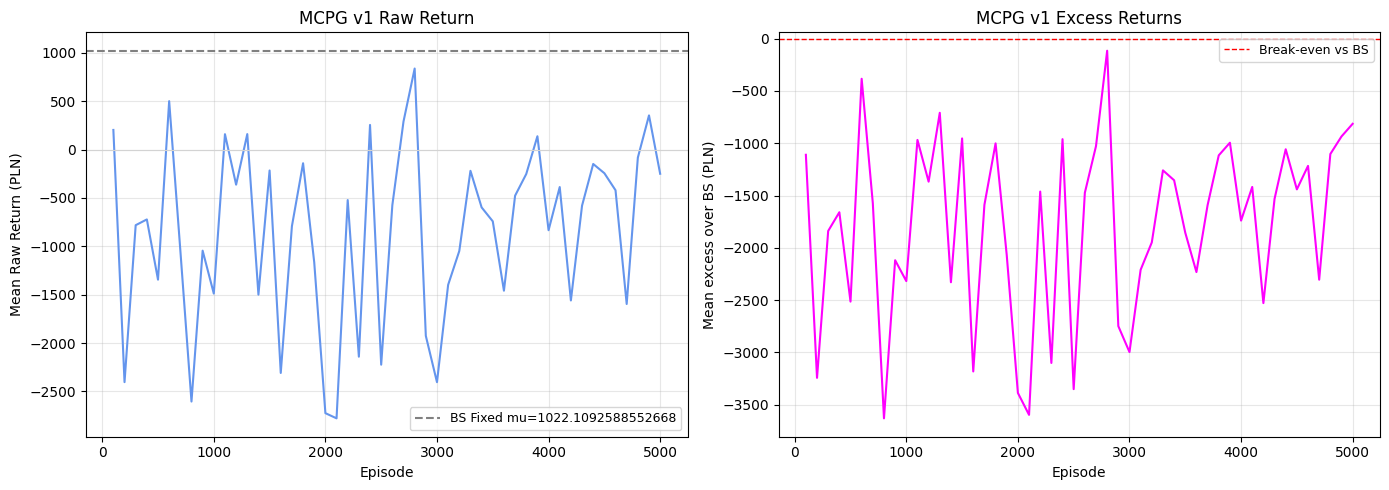

In [59]:
# visualising MCPG v1 training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bs_mean = bs_fixed_eval['pnl'].mean()

axes[0].plot(mcpg_pts, mcpg_raw, color='cornflowerblue', linewidth=1.5)
axes[0].axhline(bs_mean, color='grey', linestyle='--',
                label=f'BS Fixed mu={bs_mean}')
axes[0].axhline(0, color='lightgrey', linewidth=0.8)
axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Mean Raw Return (PLN)')
axes[0].set_title('MCPG v1 Raw Return')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

axes[1].plot(mcpg_pts, mcpg_excess, color='magenta', linewidth=1.5)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1, label='Break-even vs BS')
axes[1].set_xlabel('Episode'); axes[1].set_ylabel('Mean excess over BS (PLN)')
axes[1].set_title('MCPG v1 Excess Returns')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

MCPG has incredibly poor performance in training despite its superior returns in evaluation. This suggests it speculates badly but got lucky in the evaluation seed. The training plot also shows that the policy diverges.

This is because REINFORCE has very high gradient variance because each gradient update is based on one episode's return and since the enviornment is unpredictable, each episode has a different volatility and spot path. MCPG doesn't account for this.

To fix this, I try go to the DQN v2 style reward that penalises all rewards rather than excess rewards to reduce gradient variance, since lamda=2 performed best last time I keep the same risk aversion parameter.

In [60]:
# MCPG v2 (penalise all rewards)
def mcpg_control_v2(n_eps, hmm_stats, market_params, s_0, K,
                    eval_interval=100, learning_rate=0.001, hidden=64,
                    lambda_risk=2.0, risk_scale=10000, seed=21):
    np.random.seed(seed)
    torch.manual_seed(seed)
    random.seed(seed)

    n_state = 6
    policy_net = PolicyNetwork(n_state, hidden)
    optimiser = optim.Adam(policy_net.parameters(), lr=learning_rate)

    # track agent
    eval_points = []
    ret_hist = []
    ep_rets = []

    # training
    for ep in range(n_eps):
        # set up environment parameters
        T = 40
        rng = np.random.default_rng(seed + ep)
        spots, regimes = price_sim(s_0, T, hmm_stats, rng)
        dt = 1 / 252
        r_pln = market_params['r_pln']
        r_usd = market_params['r_usd']
        notional = market_params['notional']
        sigma_fixed = market_params['sigma_fixed']
        k1, k2, k3 = market_params['k1'], market_params['k2'], market_params['k3']
        tao_0 = T / 252
        premium_per_unit = call_pricer(spots[0], K, tao_0, r_pln, r_usd, sigma_fixed)
        premium_pln = premium_per_unit * notional

        # initialise agent book
        delta_current = 0.0
        usd_held = 0.0
        cum_tc = 0.0
        cum_pln_spent = 0.0
        cum_interest_pln = 0.0
        cum_interest_usd = 0.0
        v_book_prev = 0.0

        # store probabilities and reward for update
        log_probs = []
        raw_rewards = []

        # run REINFORCE algo
        for t in range(T):
            state_dict = {
                't': t, 'T': T, 'S_t': spots[t], 'K': K,
                'delta_current': delta_current, 'spot_history': spots[:t + 1],
                'r_pln': r_pln, 'r_usd': r_usd,
                'k1': k1, 'k2': k2, 'k3': k3}

            state_tensor = state_to_tensor(state_dict, market_params)

            mean, log_std = policy_net(state_tensor)
            std = torch.exp(log_std)
            dist = torch.distributions.Normal(mean, std)
            raw_action = dist.sample()
            target_delta = torch.clamp(raw_action, 0.0, 1.0).item()
            log_prob = dist.log_prob(raw_action)
            log_probs.append(log_prob)

            # agent trade
            trade_delta = target_delta - delta_current
            trade_usd = trade_delta * notional
            # incur transaction costs
            if abs(trade_usd) < 0.0000001:
                tc = 0.0
            else:
                tc = k1 + (k2 * abs(trade_usd)) + (k3 * abs(trade_usd) * spots[t])

            # update book
            cum_tc += tc
            usd_held += trade_usd
            delta_current = target_delta
            cum_pln_spent += trade_usd * spots[t]
            cum_interest_pln += premium_pln * r_pln * dt
            cum_interest_usd += usd_held * r_usd * dt

            # move to next state
            s_next = spots[t + 1]
            tao_next = (T - t - 1) / 252
            call_next = call_pricer(s_next, K, tao_next, r_pln, r_usd, sigma_fixed)

            # update book value
            v_book_now = (-call_next * notional + premium_pln + cum_interest_pln
                         - cum_pln_spent + usd_held * s_next
                         + cum_interest_usd * s_next - cum_tc)

            # unwind book
            if t == T - 1:
                if abs(usd_held) > 0.0000001:
                    unwind_tc = k1 + (k2 * abs(usd_held)) + (k3 * abs(usd_held) * s_next)
                    cum_tc += unwind_tc
                    v_book_now -= unwind_tc

            # udpate rewards and book value
            raw_reward = v_book_now - v_book_prev
            v_book_prev = v_book_now
            raw_rewards.append(raw_reward)

        # shape rewards s.t. penalise all rewards not just excess
        shaped = [r - lambda_risk * (r ** 2) / risk_scale for r in raw_rewards]

        # compute returns
        G = np.zeros(T)
        G[T - 1] = shaped[T - 1]
        for t in range(T - 2, -1, -1):
            G[t] = shaped[t] + G[t + 1]

        # REINFORCE update
        policy_loss = 0
        for t in range(T):
            policy_loss += -log_probs[t] * G[t]

        optimiser.zero_grad()
        policy_loss.backward()
        nn.utils.clip_grad_norm_(policy_net.parameters(), max_norm=10)
        optimiser.step()

        # update episode rewards
        ep_raw = sum(raw_rewards)
        ep_rets.append(ep_raw)

        # evaluate performancew at each eval_interval
        if (ep + 1) % eval_interval == 0:
            eval_points.append(ep + 1)
            mean_raw = np.mean(ep_rets[-eval_interval:])
            std_raw = np.std(ep_rets[-eval_interval:])
            ret_hist.append(mean_raw)
            print(f'ep {ep + 1}: agent_mean_returns={mean_raw:.0f} (std={std_raw:.0f})')

    return policy_net, eval_points, ret_hist

In [61]:
# run MCPG v2 (training)
K = s_0
mcpg_net_v2, mcpg_pts_v2, mcpg_raw_v2 = mcpg_control_v2(
    n_eps=5000, hmm_stats=hmm_stats, market_params=market_params,
    s_0=s_0, K=K, lambda_risk=2.0, seed=21)

ep 100: agent_mean_returns=95 (std=6733)
ep 200: agent_mean_returns=-2415 (std=8175)
ep 300: agent_mean_returns=-743 (std=7717)
ep 400: agent_mean_returns=-574 (std=6591)
ep 500: agent_mean_returns=-1035 (std=6495)
ep 600: agent_mean_returns=484 (std=7579)
ep 700: agent_mean_returns=-1260 (std=7477)
ep 800: agent_mean_returns=-1794 (std=7574)
ep 900: agent_mean_returns=-846 (std=6150)
ep 1000: agent_mean_returns=-1162 (std=8925)
ep 1100: agent_mean_returns=217 (std=8252)
ep 1200: agent_mean_returns=-253 (std=6869)
ep 1300: agent_mean_returns=210 (std=6444)
ep 1400: agent_mean_returns=-491 (std=7351)
ep 1500: agent_mean_returns=-406 (std=6992)
ep 1600: agent_mean_returns=-2333 (std=8176)
ep 1700: agent_mean_returns=110 (std=6973)
ep 1800: agent_mean_returns=-107 (std=7851)
ep 1900: agent_mean_returns=-938 (std=7468)
ep 2000: agent_mean_returns=-1758 (std=7540)
ep 2100: agent_mean_returns=-871 (std=8365)
ep 2200: agent_mean_returns=-607 (std=7777)
ep 2300: agent_mean_returns=-1647 (std=7

In [62]:
# evaluate MCPG v2
mcpg_v2_policy = mcpg_policy_func(mcpg_net_v2, market_params)
mcpg_v2_eval = evaluate_policy(mcpg_v2_policy)

# compare to existing models
summary = build_summary({'BS Fixed':bs_fixed_eval,'BS Rolling':bs_rolling_eval,
                         'Linear MC':linear_mc_eval, 'Linear TD':linear_td_eval,
                         'DQN v1 (lambda=0.5)': dqn_v1_eval,
                         'DQN v2 (lambda=2)':dqn_v2_eval,
                         'DQN v2 (lambda=5)':dqn_v2_lamb5_eval,
                         'DQN v3':dqn_v3_eval,'MCPG v1':mcpg_v1_eval,
                         'MCPG v2':mcpg_v2_eval})
print(summary.round(1).to_string(index=False))

             policy  mean_pnl  std_pnl  sharpe  5th_pct  95th_pct  mean_tc  mean_turnover
           BS Fixed    1022.1   1623.0     0.6  -1949.1    3304.5    306.9            2.8
         BS Rolling     922.7   1946.4     0.5  -2555.6    3711.0    387.6            3.6
          Linear MC     862.2   5839.9     0.1 -11755.2    6155.5     64.4            0.6
          Linear TD     982.1   5786.6     0.2  -8719.9    9206.0    359.6            3.3
DQN v1 (lambda=0.5)    1189.3   3488.0     0.3  -4985.0    6276.3    483.4            4.5
  DQN v2 (lambda=2)    1070.9   2178.0     0.5  -3243.9    3930.0    296.5            2.8
  DQN v2 (lambda=5)    1027.4   1918.2     0.5  -2558.0    3730.6    302.5            2.8
             DQN v3    1067.3   2822.2     0.4  -4010.6    4994.3    343.4            3.2
            MCPG v1    2223.6   7882.8     0.3 -14144.1    7880.7    214.5            2.0
            MCPG v2    1649.2   6082.1     0.3 -10522.7    9068.9    216.3            2.0


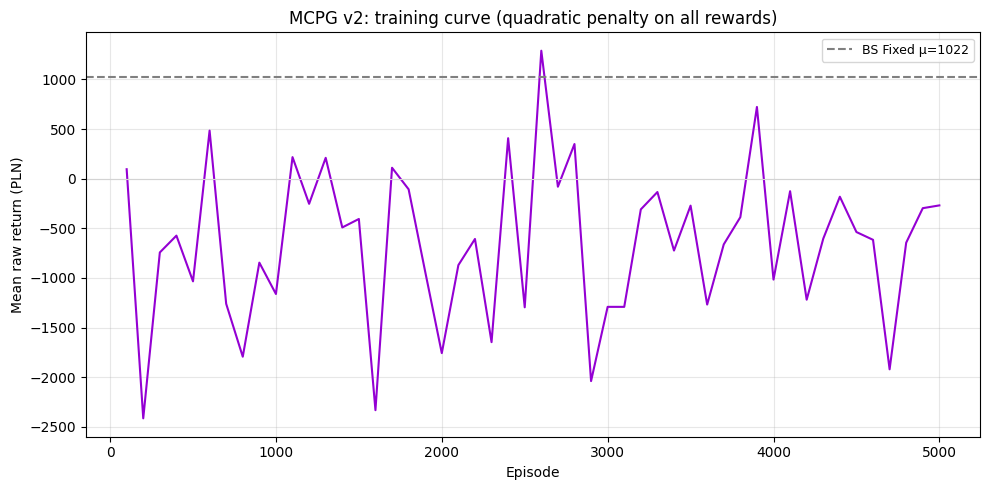

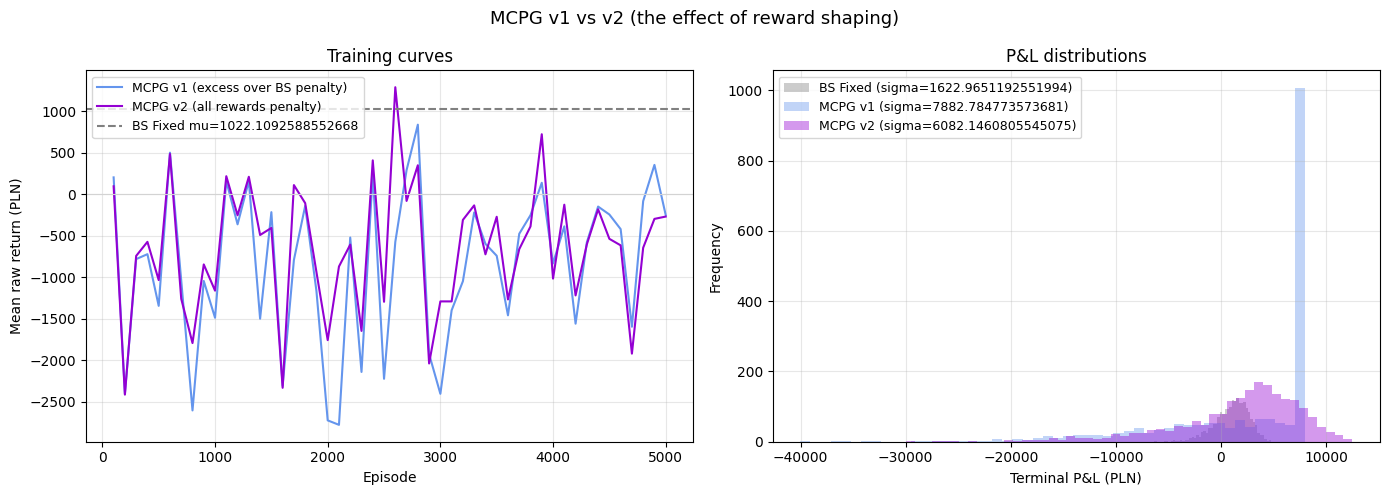

In [63]:
# visualising MCPG v2 training curve
fig, ax = plt.subplots(figsize=(10, 5))
bs_mean = bs_fixed_eval['pnl'].mean()

ax.plot(mcpg_pts_v2, mcpg_raw_v2, color='darkviolet', linewidth=1.5)
ax.axhline(bs_mean, color='grey', linestyle='--',
           label=f'BS Fixed μ={bs_mean:.0f}')
ax.axhline(0, color='lightgrey', linewidth=0.8)
ax.set_xlabel('Episode'); ax.set_ylabel('Mean raw return (PLN)')
ax.set_title('MCPG v2: training curve (quadratic penalty on all rewards)')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# comparing MCPG v2 and v1 to capture effect of changing reward shape
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bs_mean = bs_fixed_eval['pnl'].mean()

# training curves side-by-side
axes[0].plot(mcpg_pts, mcpg_raw, color='cornflowerblue', linewidth=1.5,
             label='MCPG v1 (excess over BS penalty)')
axes[0].plot(mcpg_pts_v2, mcpg_raw_v2, color='darkviolet', linewidth=1.5,
             label='MCPG v2 (all rewards penalty)')
axes[0].axhline(bs_mean, color='grey', linestyle='--',
                label=f'BS Fixed mu={bs_mean}')
axes[0].axhline(0, color='lightgrey', linewidth=0.8)
axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Mean raw return (PLN)')
axes[0].set_title('Training curves')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# pnl distribution v1, v2, bs
axes[1].hist(bs_fixed_eval['pnl'], bins=50, alpha=0.4, color='grey',
             label=f"BS Fixed (sigma={bs_fixed_eval['pnl'].std()})")
axes[1].hist(mcpg_v1_eval['pnl'], bins=50, alpha=0.4, color='cornflowerblue',
             label=f"MCPG v1 (sigma={mcpg_v1_eval['pnl'].std()})")
axes[1].hist(mcpg_v2_eval['pnl'], bins=50, alpha=0.4, color='darkviolet',
             label=f"MCPG v2 (sigma={mcpg_v2_eval['pnl'].std()})")
axes[1].set_xlabel('Terminal P&L (PLN)'); axes[1].set_ylabel('Frequency')
axes[1].set_title('P&L distributions')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.suptitle('MCPG v1 vs v2 (the effect of reward shaping)', fontsize=13)
plt.tight_layout()
plt.show()

MCPG still speculates, so I try to improve by adding a baseline (exponential moving average).

The baseline is a running average of past episode returns (99% old estimate 1% new episode return).

Without baseline gradient is G_t * grad log(pi) so every action is reinforced even if bad and with baseline it's (G_t - baseline) * grad log(pi) so bad actions can be discouraged.

In [64]:
def mcpg_control_v3(n_eps, hmm_stats, market_params, s_0, K,
                    eval_interval=100, learning_rate=0.001, hidden=64,
                    lambda_risk=2.0, risk_scale=10000, seed=21):
    np.random.seed(seed)
    torch.manual_seed(seed)
    random.seed(seed)

    n_state = 6
    policy_net = PolicyNetwork(n_state, hidden)
    optimiser = optim.Adam(policy_net.parameters(), lr=learning_rate)

    # setup performance tracking
    eval_points = []
    ret_hist = []
    ep_rets = []
    running_baseline = 0.0  # exponential moving average of returns

    # run training
    for ep in range(n_eps):
        # initialise environment
        T = 40
        rng = np.random.default_rng(seed + ep)
        spots, regimes = price_sim(s_0, T, hmm_stats, rng)
        dt = 1 / 252
        r_pln = market_params['r_pln']
        r_usd = market_params['r_usd']
        notional = market_params['notional']
        sigma_fixed = market_params['sigma_fixed']
        k1, k2, k3 = market_params['k1'], market_params['k2'], market_params['k3']
        tao_0 = T / 252
        premium_per_unit = call_pricer(spots[0], K, tao_0, r_pln, r_usd, sigma_fixed)
        premium_pln = premium_per_unit * notional

        # initialise book
        delta_current = 0.0
        usd_held = 0.0
        cum_tc = 0.0
        cum_pln_spent = 0.0
        cum_interest_pln = 0.0
        cum_interest_usd = 0.0
        v_book_prev = 0.0

        # setup to evaluate probabilities and rewards
        log_probs = []
        raw_rewards = []

        # run REINFORCE algo
        for t in range(T):
            state_dict = {
                't': t, 'T': T, 'S_t': spots[t], 'K': K,
                'delta_current': delta_current, 'spot_history': spots[:t + 1],
                'r_pln': r_pln, 'r_usd': r_usd,
                'k1': k1, 'k2': k2, 'k3': k3}

            state_tensor = state_to_tensor(state_dict, market_params)

            mean, log_std = policy_net(state_tensor)
            std = torch.exp(log_std)
            dist = torch.distributions.Normal(mean, std)
            raw_action = dist.sample()
            target_delta = torch.clamp(raw_action, 0.0, 1.0).item()
            log_prob = dist.log_prob(raw_action)
            log_probs.append(log_prob)

            # update book
            trade_delta = target_delta - delta_current
            trade_usd = trade_delta * notional

            # incur transaction costs
            if abs(trade_usd) < 0.0000001:
                tc = 0.0
            else:
                tc = k1 + (k2 * abs(trade_usd)) + (k3 * abs(trade_usd) * spots[t])

            # update book
            cum_tc += tc
            usd_held += trade_usd
            delta_current = target_delta
            cum_pln_spent += trade_usd * spots[t]
            cum_interest_pln += premium_pln * r_pln * dt
            cum_interest_usd += usd_held * r_usd * dt

            # move to next state
            s_next = spots[t + 1]
            tao_next = (T - t - 1) / 252
            call_next = call_pricer(s_next, K, tao_next, r_pln, r_usd, sigma_fixed)

            # update book
            v_book_now = (-call_next * notional + premium_pln + cum_interest_pln
                         - cum_pln_spent + usd_held * s_next
                         + cum_interest_usd * s_next - cum_tc)

            # unwind at terminal state
            if t == T - 1:
                if abs(usd_held) > 1e-10:
                    unwind_tc = k1 + k2 * abs(usd_held) + k3 * abs(usd_held) * s_next
                    cum_tc += unwind_tc
                    v_book_now -= unwind_tc

            # update and track rewards
            raw_reward = v_book_now - v_book_prev
            v_book_prev = v_book_now
            raw_rewards.append(raw_reward)

        # shape rewards
        shaped = [r - lambda_risk * (r ** 2) / risk_scale for r in raw_rewards]

        # compute returns
        G = np.zeros(T)
        G[T - 1] = shaped[T - 1]
        for t in range(T - 2, -1, -1):
            G[t] = shaped[t] + G[t + 1]

        # subtract baseline to reduce gradient variance
        baseline = running_baseline
        G_centred = G - baseline

        # update running baseline (exponential moving average)
        ep_return = sum(raw_rewards)
        running_baseline = 0.99 * running_baseline + 0.01 * ep_return

        # REINFORCE update with baseline
        policy_loss = 0
        for t in range(T):
            policy_loss += -log_probs[t] * G_centred[t]

        optimiser.zero_grad()
        policy_loss.backward()
        nn.utils.clip_grad_norm_(policy_net.parameters(), max_norm=10)
        optimiser.step()

        ep_raw = sum(raw_rewards)
        ep_rets.append(ep_raw)

        # evaluate performance at eval intervals
        if (ep + 1) % eval_interval == 0:
            eval_points.append(ep + 1)
            mean_raw = np.mean(ep_rets[-eval_interval:])
            std_raw = np.std(ep_rets[-eval_interval:])
            ret_hist.append(mean_raw)
            print(f'ep {ep + 1}: agent_mean_returns={mean_raw:.0f} (std={std_raw:.0f}), '
                  f'baseline={running_baseline:.0f}')

    return policy_net, eval_points, ret_hist



In [65]:
# train MCPG v3
K = s_0
mcpg_net_v3, mcpg_pts_v3, mcpg_raw_v3 = mcpg_control_v3(
    n_eps=5000, hmm_stats=hmm_stats, market_params=market_params,
    s_0=s_0, K=K, lambda_risk=2.0, seed=21)

ep 100: agent_mean_returns=106 (std=6766), baseline=134
ep 200: agent_mean_returns=-2462 (std=8276), baseline=-1716
ep 300: agent_mean_returns=-742 (std=7739), baseline=-921
ep 400: agent_mean_returns=-623 (std=6772), baseline=-837
ep 500: agent_mean_returns=-1109 (std=6566), baseline=-1200
ep 600: agent_mean_returns=511 (std=7606), baseline=-276
ep 700: agent_mean_returns=-1261 (std=7463), baseline=-642
ep 800: agent_mean_returns=-1907 (std=7527), baseline=-1578
ep 900: agent_mean_returns=-839 (std=6147), baseline=-1098
ep 1000: agent_mean_returns=-1099 (std=8911), baseline=-978
ep 1100: agent_mean_returns=317 (std=8210), baseline=-287
ep 1200: agent_mean_returns=-216 (std=7015), baseline=-140
ep 1300: agent_mean_returns=227 (std=6439), baseline=219
ep 1400: agent_mean_returns=-400 (std=7436), baseline=-113
ep 1500: agent_mean_returns=-443 (std=6942), baseline=-114
ep 1600: agent_mean_returns=-2247 (std=8126), baseline=-1483
ep 1700: agent_mean_returns=294 (std=7070), baseline=-307
ep

In [66]:
# evaluate MCPG v3
mcpg_v3_policy = mcpg_policy_func(mcpg_net_v3, market_params)
mcpg_v3_eval = evaluate_policy(mcpg_v3_policy)

# compare with existing models
summary = build_summary({'BS Fixed':bs_fixed_eval,'BS Rolling':bs_rolling_eval,
                         'Linear Q-learning MC':linear_mc_eval,
                         'Linear Q-learning TD':linear_td_eval,
                         'DQN v1 (lambda=0.5)':dqn_v1_eval,
                         'DQN v2 (lambda=2)':dqn_v2_eval,
                         'DQN v2 (lambda=5)':dqn_v2_lamb5_eval,
                         'DQN v3':dqn_v3_eval,'MCPG v1':mcpg_v1_eval,
                         'MCPG v2':mcpg_v2_eval,'MCPG v3':mcpg_v3_eval})
print(summary.round(1).to_string(index=False))

              policy  mean_pnl  std_pnl  sharpe  5th_pct  95th_pct  mean_tc  mean_turnover
            BS Fixed    1022.1   1623.0     0.6  -1949.1    3304.5    306.9            2.8
          BS Rolling     922.7   1946.4     0.5  -2555.6    3711.0    387.6            3.6
Linear Q-learning MC     862.2   5839.9     0.1 -11755.2    6155.5     64.4            0.6
Linear Q-learning TD     982.1   5786.6     0.2  -8719.9    9206.0    359.6            3.3
 DQN v1 (lambda=0.5)    1189.3   3488.0     0.3  -4985.0    6276.3    483.4            4.5
   DQN v2 (lambda=2)    1070.9   2178.0     0.5  -3243.9    3930.0    296.5            2.8
   DQN v2 (lambda=5)    1027.4   1918.2     0.5  -2558.0    3730.6    302.5            2.8
              DQN v3    1067.3   2822.2     0.4  -4010.6    4994.3    343.4            3.2
             MCPG v1    2223.6   7882.8     0.3 -14144.1    7880.7    214.5            2.0
             MCPG v2    1649.2   6082.1     0.3 -10522.7    9068.9    216.3            2.0

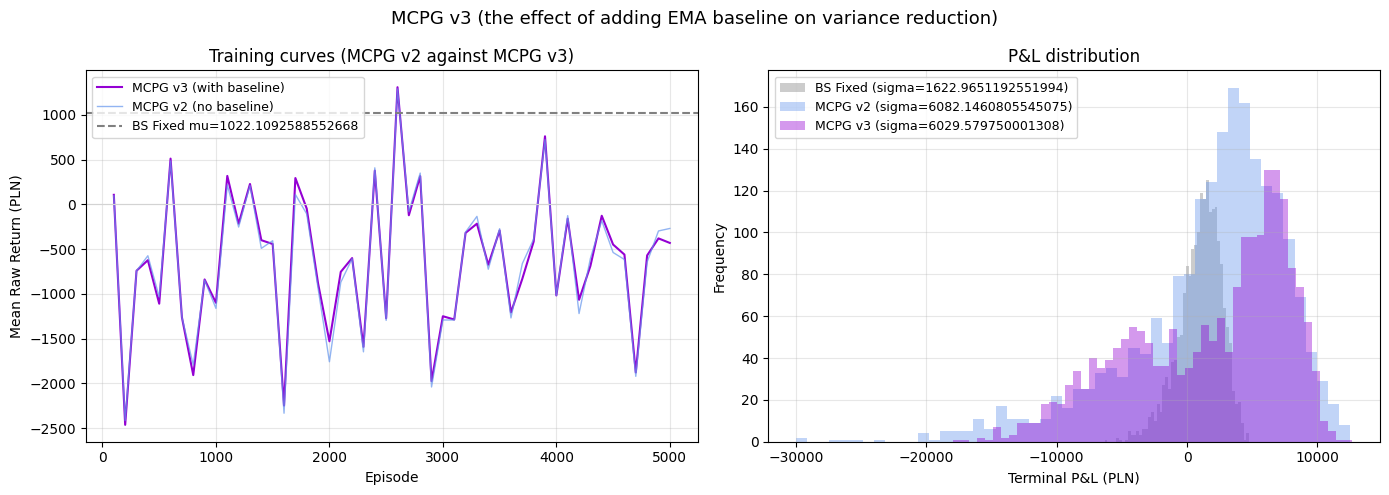

In [67]:
# visualising training MCPG v3
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bs_mean = bs_fixed_eval['pnl'].mean()
axes[0].plot(mcpg_pts_v3, mcpg_raw_v3, color='darkviolet', linewidth=1.5,
             label='MCPG v3 (with baseline)')
axes[0].plot(mcpg_pts_v2, mcpg_raw_v2, color='cornflowerblue', linewidth=1,
             alpha=0.7, label='MCPG v2 (no baseline)')
axes[0].axhline(bs_mean, color='grey', linestyle='--',
                label=f'BS Fixed mu={bs_mean}')
axes[0].axhline(0, color='lightgrey', linewidth=0.8)
axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Mean Raw Return (PLN)')
axes[0].set_title('Training curves (MCPG v2 against MCPG v3)')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# pnl distribution of all MCPG models against BS
axes[1].hist(bs_fixed_eval['pnl'], bins=50, alpha=0.4, color='grey',
             label=f"BS Fixed (sigma={bs_fixed_eval['pnl'].std()})")
axes[1].hist(mcpg_v2_eval['pnl'], bins=50, alpha=0.4, color='cornflowerblue',
             label=f"MCPG v2 (sigma={mcpg_v2_eval['pnl'].std()})")
axes[1].hist(mcpg_v3_eval['pnl'], bins=50, alpha=0.4, color='darkviolet',
             label=f"MCPG v3 (sigma={mcpg_v3_eval['pnl'].std()})")
axes[1].set_xlabel('Terminal P&L (PLN)'); axes[1].set_ylabel('Frequency')
axes[1].set_title('P&L distribution')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.suptitle('MCPG v3 (the effect of adding EMA baseline on variance reduction)', fontsize=13)
plt.tight_layout()
plt.show()

# Actor Critic
MCPG structurally doesn't work because of the signal to noise ratio. It's really hard to guage whether PnL improves/worsens because of a bad delta rebalance or because of the direction of spot movement. Furthermore, the use of MC means that the agent can only learn from one noisy episode whereas in DQN the TD bootstrapping meant that the agent could learn from a greater state-action space in an episode which helped stabilise a policy. To get the best of both, (continuous action space from MCPG) I now try Actor-Critic.

In [68]:
# creating critic network to estimate V(s)
class CriticNetwork(nn.Module):
    def __init__(self, n_state=6, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_state, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1))

    def forward(self, x):
        return self.net(x).squeeze(-1)

In [69]:
# creating function for actor critic control
def actor_critic_control(n_eps, hmm_stats, market_params, s_0, K,
                         eval_interval=100, lr_actor=0.001, lr_critic=0.001,
                         hidden=64, lambda_risk=2.0, risk_scale=10000,
                         seed=21):
    np.random.seed(seed)
    torch.manual_seed(seed)
    random.seed(seed)

    n_state = 6

    # actor outputs continuous delta via Gaussian like MCPG
    actor = PolicyNetwork(n_state, hidden)

    # critic estimates state value
    critic = CriticNetwork(n_state, hidden)

    # setup optimiser for actor and critic
    actor_optimiser = optim.Adam(actor.parameters(), lr=lr_actor)
    critic_optimiser = optim.Adam(critic.parameters(), lr=lr_critic)

    # setup performance tracking
    eval_points = []
    ret_hist = []
    ep_rets = []

    # training
    for ep in range(n_eps):
      # setup environment
        T = 40
        rng = np.random.default_rng(seed + ep)
        spots, regimes = price_sim(s_0, T, hmm_stats, rng)
        dt = 1 / 252
        r_pln = market_params['r_pln']
        r_usd = market_params['r_usd']
        notional = market_params['notional']
        sigma_fixed = market_params['sigma_fixed']
        k1, k2, k3 = market_params['k1'], market_params['k2'], market_params['k3']
        tao_0 = T / 252
        premium_per_unit = call_pricer(spots[0], K, tao_0, r_pln, r_usd, sigma_fixed)
        premium_pln = premium_per_unit * notional

        # initialise book
        delta_current = 0.0
        usd_held = 0.0
        cum_tc = 0.0
        cum_pln_spent = 0.0
        cum_interest_pln = 0.0
        cum_interest_usd = 0.0
        v_book_prev = 0.0

        # store everything to update at end of episode
        log_probs = []
        values = []
        shaped_rewards = []
        raw_rewards = []

        # generate states
        for t in range(T):
            state_dict = {
                't': t, 'T': T, 'S_t': spots[t], 'K': K,
                'delta_current': delta_current, 'spot_history': spots[:t + 1],
                'r_pln': r_pln, 'r_usd': r_usd,
                'k1': k1, 'k2': k2, 'k3': k3}

            state_tensor = state_to_tensor(state_dict, market_params)

            # actor samples action from Gaussian policy
            mean, log_std = actor(state_tensor)
            std = torch.exp(log_std)
            dist = torch.distributions.Normal(mean, std)
            raw_action = dist.sample()
            target_delta = torch.clamp(raw_action, 0.0, 1.0).item()
            log_prob = dist.log_prob(raw_action)
            log_probs.append(log_prob)

            # critic estimates value of current state
            v = critic(state_tensor)
            values.append(v)

            # execute trade
            trade_delta = target_delta - delta_current
            trade_usd = trade_delta * notional

            # incur transaction costs
            if abs(trade_usd) < 0.0000001:
                tc = 0
            else:
                tc = k1 + (k2 * abs(trade_usd)) + (k3 * abs(trade_usd) * spots[t])

            # update book
            cum_tc += tc
            usd_held += trade_usd
            delta_current = target_delta
            cum_pln_spent += trade_usd * spots[t]
            cum_interest_pln += premium_pln * r_pln * dt
            cum_interest_usd += usd_held * r_usd * dt

            # move to next state
            s_next = spots[t + 1]
            tao_next = (T - t - 1) / 252
            call_next = call_pricer(s_next, K, tao_next, r_pln, r_usd, sigma_fixed)

            # update book value
            v_book_now = (-call_next * notional + premium_pln + cum_interest_pln
                         - cum_pln_spent + usd_held * s_next
                         + cum_interest_usd * s_next - cum_tc)

            raw_reward = v_book_now - v_book_prev
            v_book_prev = v_book_now

            # unwind position at terminal state
            if t == T - 1:
                if abs(usd_held) > 1e-10:
                    unwind_tc = k1 + k2 * abs(usd_held) + k3 * abs(usd_held) * s_next
                    cum_tc += unwind_tc
                    v_book_now -= unwind_tc
                    raw_reward -= unwind_tc

            # shape (penalise) all large rewards (variance penalty)
            shaped = raw_reward - lambda_risk * (raw_reward ** 2) / risk_scale
            shaped_rewards.append(shaped)
            raw_rewards.append(raw_reward)


        # compute returns from shaped rewards
        G = np.zeros(T)
        G[T - 1] = shaped_rewards[T - 1]
        for t in range(T - 2, -1, -1):
            G[t] = shaped_rewards[t] + G[t + 1]

        G_tensor = torch.tensor(G, dtype=torch.float32) # turn into tensor for loss calcs

        # calculate critic loss
        values_tensor = torch.stack(values)
        critic_loss = nn.MSELoss()(values_tensor, G_tensor)

        # calculate actor loss
        # detach so critic gradients don't flow into actor
        advantages = G_tensor - values_tensor.detach()
        actor_loss = 0
        # update actor loss
        for t in range(T):
            actor_loss += -log_probs[t] * advantages[t]

        # update critic w gradient descent
        critic_optimiser.zero_grad()
        critic_loss.backward()
        nn.utils.clip_grad_norm_(critic.parameters(), max_norm=10)
        critic_optimiser.step()

        # update actor w gradient descent
        actor_optimiser.zero_grad()
        actor_loss.backward()
        nn.utils.clip_grad_norm_(actor.parameters(), max_norm=10)
        actor_optimiser.step()

        # track raw returns
        ep_raw = sum(raw_rewards)
        ep_rets.append(ep_raw)

        # evaluate performance at eval itnervals
        if (ep + 1) % eval_interval == 0:
            eval_points.append(ep + 1)
            mean_raw = np.mean(ep_rets[-eval_interval:])
            std_raw = np.std(ep_rets[-eval_interval:])
            mean_v = values_tensor.mean().item()
            ret_hist.append(mean_raw)
            print(f'ep {ep + 1}: agent_mean_return={mean_raw} (std={std_raw}), '
                  f'critic_V={mean_v}')

    return actor, critic, eval_points, ret_hist


In [70]:
# train actor-critic
K = s_0
ac_actor, ac_critic, ac_pts, ac_raw = actor_critic_control(
    n_eps=5000, hmm_stats=hmm_stats, market_params=market_params,
    s_0=s_0, K=K, lr_actor=0.001, lr_critic=0.001,
    lambda_risk=2.0, seed=21)

ep 100: agent_mean_return=972.1408045721923 (std=6767.101228137325), critic_V=-3.886932373046875
ep 200: agent_mean_return=-2283.7888569264137 (std=9548.041817716177), critic_V=-22.046865463256836
ep 300: agent_mean_return=-1894.4255432717523 (std=8007.943898562284), critic_V=-66.31365203857422
ep 400: agent_mean_return=-1305.8873011711187 (std=7596.862768337607), critic_V=-116.4151840209961
ep 500: agent_mean_return=-491.23508834328794 (std=7443.809842820471), critic_V=-226.9019317626953
ep 600: agent_mean_return=-102.30772653053465 (std=6977.5903200215225), critic_V=-378.9525146484375
ep 700: agent_mean_return=-2494.632328061191 (std=9177.905741800241), critic_V=-513.3258056640625
ep 800: agent_mean_return=-967.7809180806034 (std=8011.800468909183), critic_V=-791.0850830078125
ep 900: agent_mean_return=-574.7472156164989 (std=7295.685624459754), critic_V=-1084.9842529296875
ep 1000: agent_mean_return=-2737.0262393262446 (std=8033.8035394768085), critic_V=-1245.079345703125
ep 1100: a

In [71]:
# wrap trained ac in a policy func for evaluation
def ac_policy_func(actor, market_params):
  def policy(state):
    state_tensor = state_to_tensor(state, market_params)
    with torch.no_grad():
      mean, log_std = actor(state_tensor)
    target_delta = torch.clamp(mean, 0, 1).item()
    tao = (state['T'] - state['t'])/252
    return{'target_delta':target_delta, 'sigma_used':market_params['sigma_fixed'],
           'call_price':call_pricer(state['S_t'], state['K'], tao, state['r_pln'],
                                    state['r_usd'], market_params['sigma_fixed']),
           'bs_delta':target_delta}
  return policy

In [72]:
# evaluate actor critic v1
ac_v1_policy = ac_policy_func(ac_actor, market_params)
ac_v1_eval = evaluate_policy(ac_v1_policy)

# compare to existing models
summary = build_summary({'BS Fixed': bs_fixed_eval, 'BS Rolling': bs_rolling_eval,
                         'Linear Q-learning MC': linear_mc_eval,
                         'Linear Q-learning TD': linear_td_eval,
                         'DQN v1 (lambda=0.5)': dqn_v1_eval,
                         'DQN v2 (lambda=2)': dqn_v2_eval,
                         'DQN v2 (lambda=5)': dqn_v2_lamb5_eval,
                         'DQN v3': dqn_v3_eval, 'MCPG v1':mcpg_v1_eval,
                         'MCPG v2': mcpg_v2_eval, 'MCPG v3': mcpg_v3_eval,
                         'Actor Critic': ac_v1_eval})
print(summary.round(1).to_string(index=False))

              policy  mean_pnl  std_pnl  sharpe  5th_pct  95th_pct  mean_tc  mean_turnover
            BS Fixed    1022.1   1623.0     0.6  -1949.1    3304.5    306.9            2.8
          BS Rolling     922.7   1946.4     0.5  -2555.6    3711.0    387.6            3.6
Linear Q-learning MC     862.2   5839.9     0.1 -11755.2    6155.5     64.4            0.6
Linear Q-learning TD     982.1   5786.6     0.2  -8719.9    9206.0    359.6            3.3
 DQN v1 (lambda=0.5)    1189.3   3488.0     0.3  -4985.0    6276.3    483.4            4.5
   DQN v2 (lambda=2)    1070.9   2178.0     0.5  -3243.9    3930.0    296.5            2.8
   DQN v2 (lambda=5)    1027.4   1918.2     0.5  -2558.0    3730.6    302.5            2.8
              DQN v3    1067.3   2822.2     0.4  -4010.6    4994.3    343.4            3.2
             MCPG v1    2223.6   7882.8     0.3 -14144.1    7880.7    214.5            2.0
             MCPG v2    1649.2   6082.1     0.3 -10522.7    9068.9    216.3            2.0

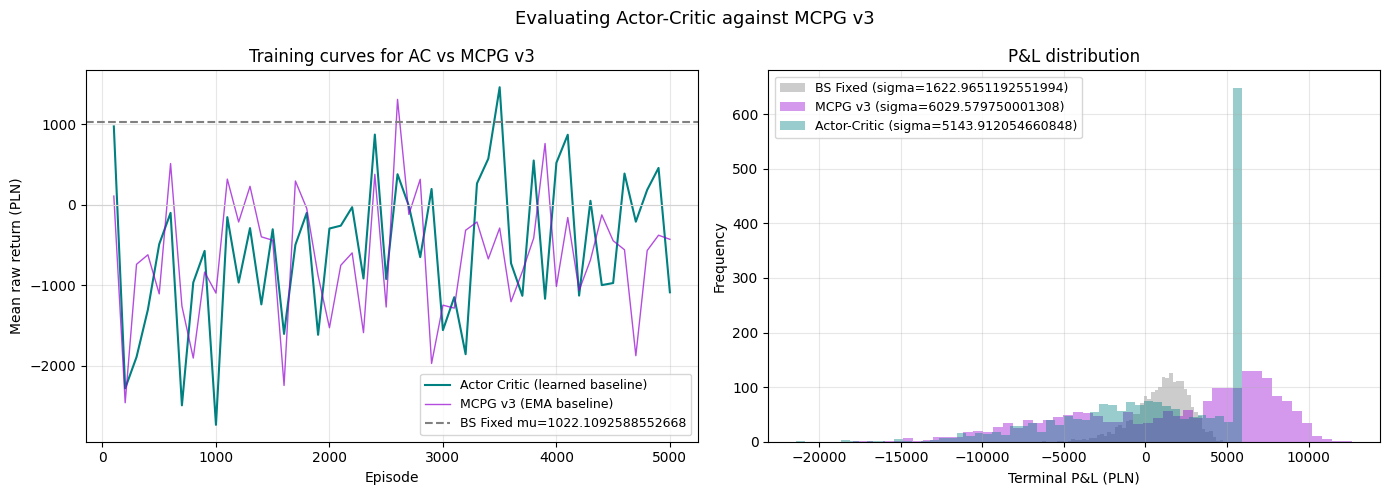

In [73]:
# visualise actor critic results compared to mcpg v3
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bs_mean = bs_fixed_eval['pnl'].mean()

# training curves for actor critic vs mcpg v3
axes[0].plot(ac_pts, ac_raw, color='teal', linewidth=1.5,
             label='Actor Critic (learned baseline)')
axes[0].plot(mcpg_pts_v3, mcpg_raw_v3, color='darkviolet', linewidth=1,
             alpha=0.7, label='MCPG v3 (EMA baseline)')
axes[0].axhline(bs_mean, color='grey', linestyle='--',
                label=f'BS Fixed mu={bs_mean}')
axes[0].axhline(0, color='lightgrey', linewidth=0.8)
axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Mean raw return (PLN)')
axes[0].set_title('Training curves for AC vs MCPG v3')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# PnL distribution: BS vs MCPG v3 vs AC
axes[1].hist(bs_fixed_eval['pnl'], bins=50, alpha=0.4, color='grey',
             label=f"BS Fixed (sigma={bs_fixed_eval['pnl'].std()})")
axes[1].hist(mcpg_v3_eval['pnl'], bins=50, alpha=0.4, color='darkviolet',
             label=f"MCPG v3 (sigma={mcpg_v3_eval['pnl'].std()})")
axes[1].hist(ac_v1_eval['pnl'], bins=50, alpha=0.4, color='teal',
             label=f"Actor-Critic (sigma={ac_v1_eval['pnl'].std()})")
axes[1].set_xlabel('Terminal P&L (PLN)'); axes[1].set_ylabel('Frequency')
axes[1].set_title('P&L distribution')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.suptitle('Evaluating Actor-Critic against MCPG v3', fontsize=13)
plt.tight_layout()
plt.show()

**Actor-Critic v2**


The critic is diverging so I try lowering the learning rate and normalising returns for stability.

In [74]:
def actor_critic_control_v2(n_eps, hmm_stats, market_params, s_0, K,
                            eval_interval=100, lr_actor=0.0003, lr_critic=0.001,
                            hidden=64, lambda_risk=2.0, risk_scale=10000,
                            seed=21):
    np.random.seed(seed)
    torch.manual_seed(seed)
    random.seed(seed)

    # set up actor and critic NNs
    n_state = 6
    actor = PolicyNetwork(n_state, hidden)
    critic = CriticNetwork(n_state, hidden)
    actor_optimiser = optim.Adam(actor.parameters(), lr=lr_actor)
    critic_optimiser = optim.Adam(critic.parameters(), lr=lr_critic)

    # setup performance tracking
    eval_points = []
    ret_hist = []
    ep_rets = []

    # training
    for ep in range(n_eps):
        # setup environment
        T = 40
        rng = np.random.default_rng(seed + ep)
        spots, regimes = price_sim(s_0, T, hmm_stats, rng)
        dt = 1 / 252
        r_pln = market_params['r_pln']
        r_usd = market_params['r_usd']
        notional = market_params['notional']
        sigma_fixed = market_params['sigma_fixed']
        k1, k2, k3 = market_params['k1'], market_params['k2'], market_params['k3']
        tao_0 = T / 252
        premium_per_unit = call_pricer(spots[0], K, tao_0, r_pln, r_usd, sigma_fixed)
        premium_pln = premium_per_unit * notional

        # initialise book
        delta_current = 0.0
        usd_held = 0.0
        cum_tc = 0.0
        cum_pln_spent = 0.0
        cum_interest_pln = 0.0
        cum_interest_usd = 0.0
        v_book_prev = 0.0

        # store metrics for evaluation
        log_probs = []
        values = []
        raw_rewards = []

        # bootstrapping in episode
        for t in range(T):
            state_dict = {
                't': t, 'T': T, 'S_t': spots[t], 'K': K,
                'delta_current': delta_current, 'spot_history': spots[:t + 1],
                'r_pln': r_pln, 'r_usd': r_usd,
                'k1': k1, 'k2': k2, 'k3': k3}

            state_tensor = state_to_tensor(state_dict, market_params)

            # actor samples from gaussian dist
            mean, log_std = actor(state_tensor)
            std = torch.exp(log_std)
            dist = torch.distributions.Normal(mean, std)
            raw_action = dist.sample()
            target_delta = torch.clamp(raw_action, 0, 1).item()
            log_prob = dist.log_prob(raw_action)
            log_probs.append(log_prob)

            # critic estimates value of current state
            v = critic(state_tensor)
            values.append(v)

            # execute trade
            trade_delta = target_delta - delta_current
            trade_usd = trade_delta * notional

            # incur transaction costs
            if abs(trade_usd) < 0.0000001:
                tc = 0
            else:
                tc = k1 + (k2 * abs(trade_usd)) + (k3 * abs(trade_usd) * spots[t])

            # update book
            cum_tc += tc
            usd_held += trade_usd
            delta_current = target_delta
            cum_pln_spent += trade_usd * spots[t]
            cum_interest_pln += premium_pln * r_pln * dt
            cum_interest_usd += usd_held * r_usd * dt

            # move to next state
            s_next = spots[t + 1]
            tao_next = (T - t - 1) / 252
            call_next = call_pricer(s_next, K, tao_next, r_pln, r_usd, sigma_fixed)

            # calc new book value
            v_book_now = (-call_next * notional + premium_pln + cum_interest_pln
                         - cum_pln_spent + usd_held * s_next
                         + cum_interest_usd * s_next - cum_tc)

            # update book and calculate reward
            raw_reward = v_book_now - v_book_prev
            v_book_prev = v_book_now

            # unwind position at terminal state
            if t == T - 1:
                if abs(usd_held) > 1e-10:
                    unwind_tc = k1 + k2 * abs(usd_held) + k3 * abs(usd_held) * s_next
                    cum_tc += unwind_tc
                    v_book_now -= unwind_tc
                    raw_reward -= unwind_tc

            raw_rewards.append(raw_reward)

        # shape (penalise) all rewards rewards
        shaped = [r - lambda_risk * (r ** 2) / risk_scale for r in raw_rewards]

        # compute returns
        G = np.zeros(T)
        G[T - 1] = shaped[T - 1]
        for t in range(T - 2, -1, -1):
            G[t] = shaped[t] + G[t + 1]

        G_tensor = torch.tensor(G, dtype=torch.float32)

        # normalise returns to prevent critic divergence
        G_mean = G_tensor.mean()
        G_std = G_tensor.std() + 0.000001
        G_norm = (G_tensor - G_mean) / G_std

        # critic loss on normalised returns
        values_tensor = torch.stack(values)
        critic_loss = nn.MSELoss()(values_tensor, G_norm)

        # actor loss with normalised advantages
        advantages = (G_norm - values_tensor).detach()
        actor_loss = 0
        for t in range(T):
            actor_loss += -log_probs[t] * advantages[t]

        # update critic
        critic_optimiser.zero_grad()
        critic_loss.backward()
        nn.utils.clip_grad_norm_(critic.parameters(), max_norm=10)
        critic_optimiser.step()

        # update actor
        actor_optimiser.zero_grad()
        actor_loss.backward()
        nn.utils.clip_grad_norm_(actor.parameters(), max_norm=10)
        actor_optimiser.step()

        ep_raw = sum(raw_rewards)
        ep_rets.append(ep_raw)

        # evaluate performance at eval intervals
        if (ep + 1) % eval_interval == 0:
            eval_points.append(ep + 1)
            mean_raw = np.mean(ep_rets[-eval_interval:])
            std_raw = np.std(ep_rets[-eval_interval:])
            mean_v = values_tensor.mean().item()
            ret_hist.append(mean_raw)
            print(f'ep {ep + 1}: agent_mean_returns={mean_raw} (std={std_raw}), '
                  f'critic_V={mean_v}')

    return actor, critic, eval_points, ret_hist

In [75]:
# train actor critic v2 with 10000 episodes instead because of lower lr
K = s_0
ac_actor_v2, ac_critic_v2, ac_pts_v2, ac_raw_v2 = actor_critic_control_v2(
    n_eps=10000, hmm_stats=hmm_stats, market_params=market_params,
    s_0=s_0, K=K, lr_actor=0.0003, lr_critic=0.001,
    lambda_risk=2.0, seed=21)


ep 100: agent_mean_returns=998.5788623712006 (std=7022.205602357399), critic_V=0.00025781692238524556
ep 200: agent_mean_returns=-2267.3582663662564 (std=9501.62100075601), critic_V=0.10752658545970917
ep 300: agent_mean_returns=-1864.555040958508 (std=7910.409700233457), critic_V=0.05196573585271835
ep 400: agent_mean_returns=-1337.423398015341 (std=7599.678796903001), critic_V=-0.06427774578332901
ep 500: agent_mean_returns=-500.12728855975575 (std=7476.908421980296), critic_V=0.04417521506547928
ep 600: agent_mean_returns=-224.98273356875498 (std=7120.783328732781), critic_V=0.0763048529624939
ep 700: agent_mean_returns=-2522.2764411107823 (std=9209.958586112836), critic_V=0.022066723555326462
ep 800: agent_mean_returns=-906.228641837063 (std=8022.592947673988), critic_V=-0.018909543752670288
ep 900: agent_mean_returns=-620.3206674870063 (std=7358.260992188862), critic_V=-0.024923641234636307
ep 1000: agent_mean_returns=-2744.4684724687395 (std=8087.482278426657), critic_V=0.0222356

In [76]:
# evaluating acv2
ac_v2_policy = mcpg_policy_func(ac_actor_v2, market_params)
ac_v2_eval = evaluate_policy(ac_v2_policy)

# compare to existing models
summary = build_summary({'BS Fixed':bs_fixed_eval,'BS Rolling':bs_rolling_eval,
                         'Linear Q-learning MC':linear_mc_eval,
                         'Linear Q-learning TD':linear_td_eval,
                         'DQN v1 (lambda=0.5)':dqn_v1_eval,
                         'DQN v2 (lambda=2)':dqn_v2_eval,
                         'DQN v2 (lambda=5)':dqn_v2_lamb5_eval,
                         'DQN v3':dqn_v3_eval, 'MCPG v1':mcpg_v1_eval,
                         'MCPG v2':mcpg_v2_eval,'MCPG v3':mcpg_v3_eval,
                         'Actor Critic':ac_v1_eval,
                         'Actor Critic v2': ac_v2_eval})
print(summary.round(1).to_string(index=False))

              policy  mean_pnl  std_pnl  sharpe  5th_pct  95th_pct  mean_tc  mean_turnover
            BS Fixed    1022.1   1623.0     0.6  -1949.1    3304.5    306.9            2.8
          BS Rolling     922.7   1946.4     0.5  -2555.6    3711.0    387.6            3.6
Linear Q-learning MC     862.2   5839.9     0.1 -11755.2    6155.5     64.4            0.6
Linear Q-learning TD     982.1   5786.6     0.2  -8719.9    9206.0    359.6            3.3
 DQN v1 (lambda=0.5)    1189.3   3488.0     0.3  -4985.0    6276.3    483.4            4.5
   DQN v2 (lambda=2)    1070.9   2178.0     0.5  -3243.9    3930.0    296.5            2.8
   DQN v2 (lambda=5)    1027.4   1918.2     0.5  -2558.0    3730.6    302.5            2.8
              DQN v3    1067.3   2822.2     0.4  -4010.6    4994.3    343.4            3.2
             MCPG v1    2223.6   7882.8     0.3 -14144.1    7880.7    214.5            2.0
             MCPG v2    1649.2   6082.1     0.3 -10522.7    9068.9    216.3            2.0

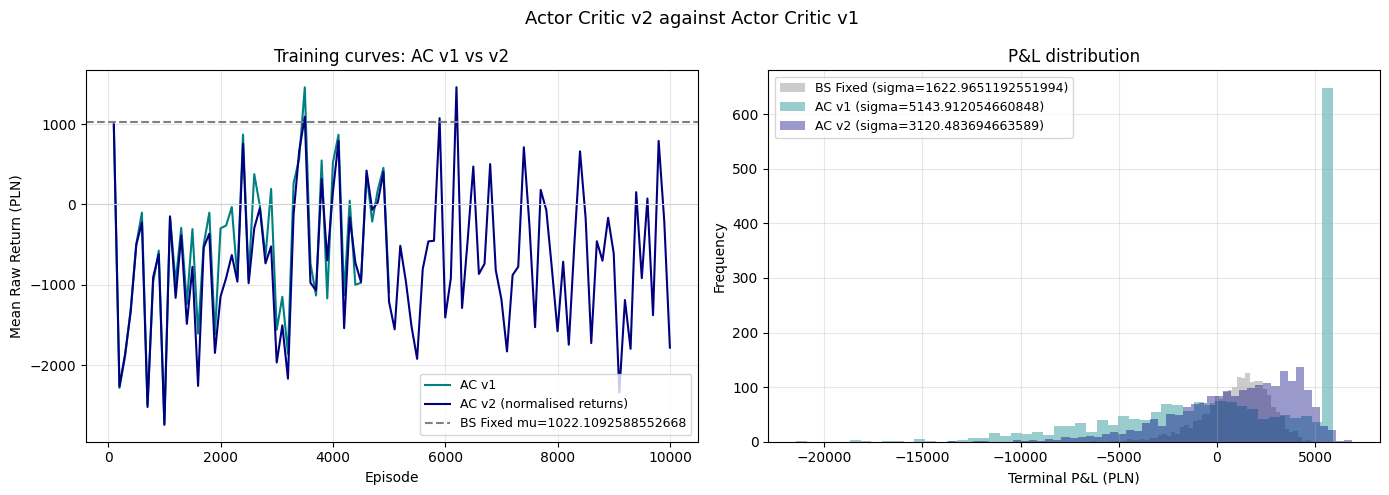

In [77]:
# visualisng acv2 results vs acv1
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bs_mean = bs_fixed_eval['pnl'].mean()

# training curves v1 vs v2
axes[0].plot(ac_pts, ac_raw, color='teal', linewidth=1.5,
             label='AC v1')
axes[0].plot(ac_pts_v2, ac_raw_v2, color='navy', linewidth=1.5,
             label='AC v2 (normalised returns)')
axes[0].axhline(bs_mean, color='grey', linestyle='--',
                label=f'BS Fixed mu={bs_mean}')
axes[0].axhline(0, color='lightgrey', linewidth=0.8)
axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Mean Raw Return (PLN)')
axes[0].set_title('Training curves: AC v1 vs v2')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# PnL distribution: BS vs AC v1 vs AC v2
axes[1].hist(bs_fixed_eval['pnl'], bins=50, alpha=0.4, color='grey',
             label=f"BS Fixed (sigma={bs_fixed_eval['pnl'].std()})")
axes[1].hist(ac_v1_eval['pnl'], bins=50, alpha=0.4, color='teal',
             label=f"AC v1 (sigma={ac_v1_eval['pnl'].std()})")
axes[1].hist(ac_v2_eval['pnl'], bins=50, alpha=0.4, color='navy',
             label=f"AC v2 (sigma={ac_v2_eval['pnl'].std()})")
axes[1].set_xlabel('Terminal P&L (PLN)'); axes[1].set_ylabel('Frequency')
axes[1].set_title('P&L distribution')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.suptitle('Actor Critic v2 against Actor Critic v1 ', fontsize=13)
plt.tight_layout()
plt.show()

# DDPG Model
Inspired by Zheng et al. (2023) paper.
This model improves on AC v2 because actor critic is an on-policy stochastic algorithm with per episode updates but DDPG is off-policiy determinisitc algo with per-step updates from a replay buffer.

1. from DQN we can see that per-step updates do better than per-episode updates because of the unpredictable environment
2. DDPG actor outputs deterministic action rather than probability like actor critic
  *   actor critic has 2 output heads the mean and log std so each update has to adjust both simultaneously which is more computationally expensive than DDPG
  *   there is also always only 1 optimum delta hedge at each step so using DDPG 'focuses' the algo on finding this optimum rather than learning action-width distributions that aren't useful for evaluating the agent
3. most importantly, in actor critic the critic only estimates state values but in DDPG the critic estimates state-action pairs
  * in actor-critic the actor has to infer if the action it took to get to a state that is then evaluated by the critic was good or not from a noisy actual return path G
  * in DDPG the actor takes in a state and outputs an action, executes it and collects a reward, moves to the next state and then stores the transition in the replay buffer
    * the critic samples past transitions and computes Q(s,a) for each transition
    * the critic updatees using the bellman equation (TD target bootstrapping)
    * the actor then picks actions the critic finds has high Q(s,a) to maximise Q(s, pi(a)) over all states in the replay buffer



In [78]:
# creating actor network
class DDPGActor(nn.Module):
    def __init__(self, n_state=6, hidden=64):
        super().__init__()
        # 2 layers as in prev models
        self.net = nn.Sequential(
            nn.Linear(n_state, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1))
    # use sigmoid to keep delta between 0 and 1
    def forward(self, state):
        return torch.sigmoid(self.net(state)).squeeze(-1)

# create critic network
class DDPGCritic(nn.Module):
    def __init__(self, n_state=6, hidden=64):
        super().__init__()
        # concatenate state and action and run in NN to get Q(s,a)
        self.net = nn.Sequential(
            nn.Linear(n_state + 1, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1))

    def forward(self, state, action):
        if action.dim() == 1:
            action = action.unsqueeze(-1)  # turn scalar action into column vector
        x = torch.cat([state, action], dim=-1)
        return self.net(x).squeeze(-1)


# soft update for target networks
def soft_update(target_net, source_net, p):
    for target_param, source_param in zip(target_net.parameters(), source_net.parameters()):
        target_param.data.copy_(p * source_param.data + (1 - p) * target_param.data)

In [79]:
# create DDPG algo function
def ddpg_control(n_eps, hmm_stats, market_params, s_0, K, eval_interval=100,
                 lr_actor=0.0001, lr_critic=0.001, batch_size=64, buffer_size=50000,
                 p=0.005, hidden=64, noise_start=0.2, noise_end=0.05,
                 noise_decay=2000, lambda_risk=2.0, risk_scale=10000, seed=21):
  # in args, set lr_actor<lr_critic so critic learns faster than actor

    # set seeds and initialise n_states for NNs
    np.random.seed(seed)
    torch.manual_seed(seed)
    random.seed(seed)
    n_state = 6

    # build main and target networks
    actor = DDPGActor(n_state, hidden)
    critic = DDPGCritic(n_state, hidden)
    target_actor = DDPGActor(n_state, hidden)
    target_critic = DDPGCritic(n_state, hidden)

    # copy weights from main to target
    target_actor.load_state_dict(actor.state_dict())
    target_critic.load_state_dict(critic.state_dict())
    target_actor.eval()
    target_critic.eval()

    # create optimisers
    actor_optimiser = optim.Adam(actor.parameters(), lr=lr_actor)
    critic_optimiser = optim.Adam(critic.parameters(), lr=lr_critic)

    # reuse DQN replay buffer function to create replay buffer
    buffer = ReplayBuffer(replay_memory_size=buffer_size)

    # track performance
    eval_points = []
    ret_hist = []
    ep_rets = []

    # training
    for ep in range(n_eps):
        # add gaussian noise to action selection for exploration
        noise_std = noise_end + (noise_start - noise_end) * np.exp(-ep / noise_decay)

        # setup environment
        T = 40
        rng = np.random.default_rng(seed + ep)
        spots, regimes = price_sim(s_0, T, hmm_stats, rng)
        dt = 1 / 252
        r_pln = market_params['r_pln']
        r_usd = market_params['r_usd']
        notional = market_params['notional']
        sigma_fixed = market_params['sigma_fixed']
        k1, k2, k3 = market_params['k1'], market_params['k2'], market_params['k3']
        tao_0 = T / 252
        premium_per_unit = call_pricer(spots[0], K, tao_0, r_pln, r_usd, sigma_fixed)
        premium_pln = premium_per_unit * notional

        # initialise book value
        delta_current = 0.0
        usd_held = 0.0
        cum_tc = 0.0
        cum_pln_spent = 0.0
        cum_interest_pln = 0.0
        cum_interest_usd = 0.0
        v_book_prev = 0.0
        ep_raw_reward = 0

        # run episode and DDPG model
        for t in range(T):
            # build state
            state_dict = {
                't': t, 'T': T, 'S_t': spots[t], 'K': K,
                'delta_current': delta_current, 'spot_history': spots[:t + 1],
                'r_pln': r_pln, 'r_usd': r_usd,
                'k1': k1, 'k2': k2, 'k3': k3}
            state_tensor = state_to_tensor(state_dict, market_params)

            # actor outputs deterministic action w gaussian noise
            with torch.no_grad():
                action = actor(state_tensor).item()
            noisy_action = action + np.random.normal(0, noise_std)
            target_delta = np.clip(noisy_action, 0.0, 1.0)

            # execute trade
            trade_delta = target_delta - delta_current
            trade_usd = trade_delta * notional

            # incur transaction costs
            if abs(trade_usd) < 0.0000001:
                tc = 0
            else:
                tc = k1 + (k2 * abs(trade_usd)) + (k3 * abs(trade_usd) * spots[t])

            # update book value
            cum_tc += tc
            usd_held += trade_usd
            delta_current = target_delta
            cum_pln_spent += trade_usd * spots[t]
            cum_interest_pln += premium_pln * r_pln * dt
            cum_interest_usd += usd_held * r_usd * dt

            # move to next state
            s_next = spots[t + 1]
            tao_next = (T - t - 1) / 252
            call_next = call_pricer(s_next, K, tao_next, r_pln, r_usd, sigma_fixed)

            v_book_now = (-call_next * notional + premium_pln + cum_interest_pln
                         - cum_pln_spent + usd_held * s_next
                         + cum_interest_usd * s_next - cum_tc)

            raw_reward = v_book_now - v_book_prev
            v_book_prev = v_book_now

            # unwind book at terminal state
            done = (t == T - 1)
            if done:
                if abs(usd_held) > 0.0000001:
                    unwind_tc = k1 + k2 * abs(usd_held) + k3 * abs(usd_held) * s_next
                    cum_tc += unwind_tc
                    v_book_now -= unwind_tc
                    raw_reward -= unwind_tc

            # put a quadratic penalty on all rewards to penalise speculation (like DQN v2)
            shaped_reward = raw_reward - lambda_risk * (raw_reward ** 2) / risk_scale
            ep_raw_reward += raw_reward

            # build next state tensor
            if not done:
                next_state_dict = {
                    't': t + 1, 'T': T, 'S_t': s_next, 'K': K,
                    'delta_current': delta_current, 'spot_history': spots[:t + 2],
                    'r_pln': r_pln, 'r_usd': r_usd,
                    'k1': k1, 'k2': k2, 'k3': k3}
                next_state_tensor = state_to_tensor(next_state_dict, market_params)
            else:
                next_state_tensor = torch.zeros(n_state)

            # store transition (store action as float not int bc cont)
            buffer.push(state_tensor, target_delta, shaped_reward, next_state_tensor, done)

            # training if buffer size reached
            if len(buffer) >= batch_size:
                b_states, b_actions, b_rewards, b_next_states, b_dones = buffer.sample(batch_size)
                b_actions = b_actions.float()

                # critic update
                with torch.no_grad():
                    next_actions = target_actor(b_next_states)
                    q_next = target_critic(b_next_states, next_actions)
                    #  TD target uses target actor's action on next state
                    td_targets = b_rewards + q_next * (1 - b_dones)

                # store critc q_values and losses
                q_current = critic(b_states, b_actions)
                critic_loss = nn.MSELoss()(q_current, td_targets)
                # calculate grads for updates
                critic_optimiser.zero_grad()
                critic_loss.backward()
                nn.utils.clip_grad_norm_(critic.parameters(), max_norm=10)
                critic_optimiser.step()

                # update actor to pick highest Q-values from critic
                actor_loss = -critic(b_states, actor(b_states)).mean()
                actor_optimiser.zero_grad()
                actor_loss.backward()
                nn.utils.clip_grad_norm_(actor.parameters(), max_norm=10)
                actor_optimiser.step()

                # soft update target networks
                soft_update(target_actor, actor, p)
                soft_update(target_critic, critic, p)

        # store rewards
        ep_rets.append(ep_raw_reward)

        # evaluate agent output at eval intervals
        if (ep + 1) % eval_interval == 0:
            eval_points.append(ep + 1)
            mean_raw = np.mean(ep_rets[-eval_interval:])
            std_raw = np.std(ep_rets[-eval_interval:])
            ret_hist.append(mean_raw)
            print(f'ep {ep+1}: agent_mean_returns={mean_raw} (std={std_raw}), '
                  f'noise_std={noise_std}, buffer={len(buffer)}')

    return actor, critic, eval_points, ret_hist

In [80]:
# wrap trained actor into policy func for evaluation
def ddpg_policy_func(actor, market_params):
    def policy(state):
        state_tensor = state_to_tensor(state, market_params)
        with torch.no_grad():
            action = actor(state_tensor).item()
        target_delta = np.clip(action, 0.0, 1.0) # deterministic at eval, no noise
        tao = (state['T'] - state['t']) / 252
        return {
            'target_delta': target_delta,
            'sigma_used':market_params['sigma_fixed'],
            'call_price':call_pricer(state['S_t'], state['K'], tao,
                                     state['r_pln'], state['r_usd'],
                                     market_params['sigma_fixed']),
            'bs_delta':target_delta}
    return policy

In [81]:
# train DDPG
K = s_0
ddpg_actor, ddpg_critic, ddpg_pts, ddpg_raw = ddpg_control(
    n_eps=5000, hmm_stats=hmm_stats, market_params=market_params,
    s_0=s_0, K=K, lr_actor=0.0001, lr_critic=0.001,
    p=0.005, noise_start=0.2, noise_end=0.05, noise_decay=2000,
    lambda_risk=2.0, risk_scale=10000, seed=21)

ep 100: agent_mean_returns=624.4344033012078 (std=6839.629443844345), noise_std=0.19275577372046937, buffer=4000
ep 200: agent_mean_returns=-1054.3093971717158 (std=9547.307584826622), noise_std=0.1857934924802762, buffer=8000
ep 300: agent_mean_returns=-1218.151147849675 (std=9595.826427081181), noise_std=0.17917076570295515, buffer=12000
ep 400: agent_mean_returns=174.85804126796754 (std=7340.379781914494), noise_std=0.17287103312193863, buffer=16000
ep 500: agent_mean_returns=777.4912959508055 (std=6860.182034099101), noise_std=0.16687854212438985, buffer=20000
ep 600: agent_mean_returns=962.4096447177125 (std=7239.229474987601), noise_std=0.1611783083614658, buffer=24000
ep 700: agent_mean_returns=-36.10640459618311 (std=8212.536629221437), noise_std=0.15575607827964005, buffer=28000
ep 800: agent_mean_returns=-979.6193184770033 (std=8475.18950678468), noise_std=0.15059829347939446, buffer=32000
ep 900: agent_mean_returns=1498.0764495729452 (std=6764.686777005344), noise_std=0.1456

In [82]:
# test DDPG before full eval
K = s_0
test_actor, test_critic, test_pts, test_raw = ddpg_control(
    n_eps=100, hmm_stats=hmm_stats, market_params=market_params,
    s_0=s_0, K=K, lr_actor=0.0001, lr_critic=0.001,
    p=0.005, noise_start=0.2, noise_end=0.05, noise_decay=2000,
    lambda_risk=2.0, risk_scale=10000, seed=21)

# print tests
print(f'Number of eval points recorded:{len(test_pts)}')
print(f'Return history:{test_raw}')
print(f'First return: {test_raw[0] if test_raw else "no eval points hit"}')

# making sure there are values for returns
if len(test_raw) > 0:
    first_return = test_raw[0]
else:
    first_return = 'no eval points hit'
print(f'First return:{first_return}')

# run a dummy state to check everything works
dummy_state = {'t': 0, 'T': 40,'S_t': s_0,'K': K,'delta_current': 0,
    'spot_history': np.array([s_0]),'r_pln': market_params['r_pln'],
    'r_usd': market_params['r_usd'],'k1': 0,'k2': 0,'k3': 0}
dummy_tensor = state_to_tensor(dummy_state, market_params)
actor_output = test_actor(dummy_tensor).item()
print(f'Actor output on dummy state:{actor_output}')

ep 100: agent_mean_returns=624.4344033012078 (std=6839.629443844345), noise_std=0.19275577372046937, buffer=4000
Number of eval points recorded:1
Return history:[np.float64(624.4344033012078)]
First return: 624.4344033012078
First return:624.4344033012078
Actor output on dummy state:1.8617705155321573e-09


In [83]:
# full eval of DDPG
ddpg_policy = ddpg_policy_func(ddpg_actor, market_params)
ddpg_eval = evaluate_policy(ddpg_policy)

# compare to all existing models
summary = build_summary({
    'BS Fixed':bs_fixed_eval,'BS Rolling':bs_rolling_eval,
    'Linear Q-learning MC':linear_mc_eval,'Linear Q-learning TD':linear_td_eval,
    'DQN v1 (lambda=0.5)':dqn_v1_eval,'DQN v2 (lambda=2)':dqn_v2_eval,
    'DQN v2 (lambda=5)':dqn_v2_lamb5_eval,'DQN v3':dqn_v3_eval,
    'MCPG v1':mcpg_v1_eval,'MCPG v2':mcpg_v2_eval,'MCPG v3':mcpg_v3_eval,
    'Actor Critic':ac_v1_eval,'Actor Critic v2':ac_v2_eval,'DDPG':ddpg_eval})
print(summary.round(1).to_string(index=False))

              policy  mean_pnl  std_pnl  sharpe  5th_pct  95th_pct  mean_tc  mean_turnover
            BS Fixed    1022.1   1623.0     0.6  -1949.1    3304.5    306.9            2.8
          BS Rolling     922.7   1946.4     0.5  -2555.6    3711.0    387.6            3.6
Linear Q-learning MC     862.2   5839.9     0.1 -11755.2    6155.5     64.4            0.6
Linear Q-learning TD     982.1   5786.6     0.2  -8719.9    9206.0    359.6            3.3
 DQN v1 (lambda=0.5)    1189.3   3488.0     0.3  -4985.0    6276.3    483.4            4.5
   DQN v2 (lambda=2)    1070.9   2178.0     0.5  -3243.9    3930.0    296.5            2.8
   DQN v2 (lambda=5)    1027.4   1918.2     0.5  -2558.0    3730.6    302.5            2.8
              DQN v3    1067.3   2822.2     0.4  -4010.6    4994.3    343.4            3.2
             MCPG v1    2223.6   7882.8     0.3 -14144.1    7880.7    214.5            2.0
             MCPG v2    1649.2   6082.1     0.3 -10522.7    9068.9    216.3            2.0

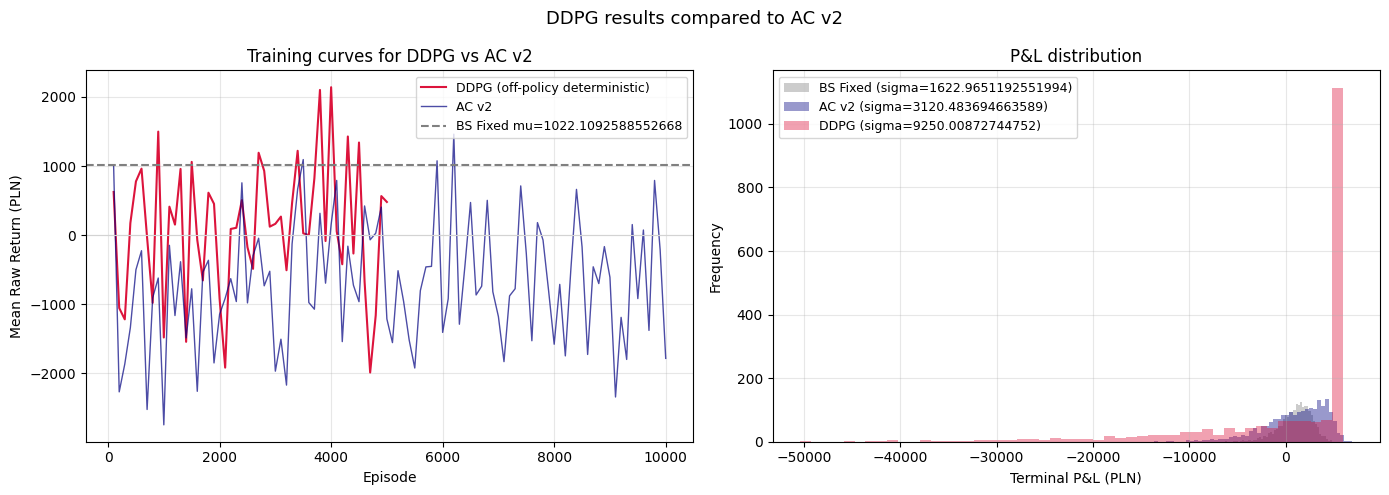

In [98]:
# visualising DDPG results vs acv2
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bs_mean = bs_fixed_eval['pnl'].mean()

# training curves for DDPG vs acv2
axes[0].plot(ddpg_pts, ddpg_raw, color='crimson', linewidth=1.5,
             label='DDPG (off-policy deterministic)')
axes[0].plot(ac_pts_v2, ac_raw_v2, color='navy', linewidth=1,
             alpha=0.7, label='AC v2')
axes[0].axhline(bs_mean, color='grey', linestyle='--',
                label=f'BS Fixed mu={bs_mean}')
axes[0].axhline(0, color='lightgrey', linewidth=0.8)
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Mean Raw Return (PLN)')
axes[0].set_title('Training curves for DDPG vs AC v2')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# PnL distribution
axes[1].hist(bs_fixed_eval['pnl'], bins=50, alpha=0.4, color='grey',
             label=f"BS Fixed (sigma={bs_fixed_eval['pnl'].std()})")
axes[1].hist(ac_v2_eval['pnl'], bins=50, alpha=0.4, color='navy',
             label=f"AC v2 (sigma={ac_v2_eval['pnl'].std()})")
axes[1].hist(ddpg_eval['pnl'], bins=50, alpha=0.4, color='crimson',
             label=f"DDPG (sigma={ddpg_eval['pnl'].std()})")
axes[1].set_xlabel('Terminal P&L (PLN)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('P&L distribution')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle('DDPG results compared to AC v2', fontsize=13)
plt.tight_layout()
plt.show()

The DDPG model learns not to trade and so performs really badly. One cause might be the high lambda which penalises trades so it learns to not trade at all.

Therefore, I create DDPGv2 which uses DQN v3's reward structure.

This is despite DQN v2 performing better than DQN v3 but the reason it did worse was the noisy signals. The structure of DDPG with the actor, critic and off-policy replay buffer mean that it is better at handling this issue so the DQN v3 reward architecture could still outperform DDPG v1.

In [85]:
def ddpg_control_v2(n_eps, hmm_stats, market_params, s_0, K, eval_interval=100,
                    lr_actor=0.0001, lr_critic=0.001, batch_size=64, buffer_size=50000,
                    p=0.005, hidden=64, noise_start=0.2, noise_end=0.05,
                    noise_decay=2000, lambda_var=0.5, var_scale=10000, seed=21):

    # set seeds and initialise n_states
    np.random.seed(seed)
    torch.manual_seed(seed)
    random.seed(seed)
    n_state = 6

    # build main and target networks
    actor = DDPGActor(n_state, hidden)
    critic = DDPGCritic(n_state, hidden)
    target_actor = DDPGActor(n_state, hidden)
    target_critic = DDPGCritic(n_state, hidden)
    target_actor.load_state_dict(actor.state_dict())
    target_critic.load_state_dict(critic.state_dict())

    # set up replay buffer and optimisers
    actor_optimiser = optim.Adam(actor.parameters(), lr=lr_actor)
    critic_optimiser = optim.Adam(critic.parameters(), lr=lr_critic)
    buffer = ReplayBuffer(replay_memory_size=buffer_size)

    # performance tracking
    eval_points = []
    ret_hist = []
    excess_ret_hist = []
    bs_ret_hist = []
    ep_rets = []
    ep_excess_rets = []
    ep_bs_rets = []

    for ep in range(n_eps):
        # decay gaussian noise added to action output from actor
        noise_std = noise_end + (noise_start - noise_end) * np.exp(-ep / noise_decay)

        # setup environment
        T = 40
        rng = np.random.default_rng(seed + ep)
        spots, regimes = price_sim(s_0, T, hmm_stats, rng)
        dt = 1 / 252
        r_pln = market_params['r_pln']
        r_usd = market_params['r_usd']
        notional = market_params['notional']
        sigma_fixed = market_params['sigma_fixed']
        k1, k2, k3 = market_params['k1'], market_params['k2'], market_params['k3']
        tao_0 = T / 252
        premium_per_unit = call_pricer(spots[0], K, tao_0, r_pln, r_usd, sigma_fixed)
        premium_pln = premium_per_unit * notional

        # initialise agent book
        delta_current = 0.0
        usd_held = 0.0
        cum_tc = 0.0
        cum_pln_spent = 0.0
        cum_interest_pln = 0.0
        cum_interest_usd = 0.0
        v_book_prev = 0.0

        # initialise BS shadow book (use as reference baseline for reward)
        bs_delta_current = 0.0
        bs_usd_held = 0.0
        bs_cum_tc = 0.0
        bs_cum_pln_spent = 0.0
        bs_cum_interest_pln = 0.0
        bs_cum_interest_usd = 0.0
        bs_v_book_prev = 0.0

        ep_raw_reward = 0
        ep_excess_reward = 0
        ep_bs_reward = 0

        for t in range(T):
            # build state
            state_dict = {
                't': t, 'T': T, 'S_t': spots[t], 'K': K,
                'delta_current': delta_current, 'spot_history': spots[:t + 1],
                'r_pln': r_pln, 'r_usd': r_usd,
                'k1': k1, 'k2': k2, 'k3': k3}
            state_tensor = state_to_tensor(state_dict, market_params)

            # add noise to actor output for training
            with torch.no_grad():
                action = actor(state_tensor).item()
            noisy_action = action + np.random.normal(0, noise_std)
            target_delta = np.clip(noisy_action, 0.0, 1.0)

            # execute agent trade
            trade_delta = target_delta - delta_current
            trade_usd = trade_delta * notional

            # agent incur transaction costs
            if abs(trade_usd) < 0.0000001:
                tc = 0
            else:
                tc = k1 + (k2 * abs(trade_usd)) + (k3 * abs(trade_usd) * spots[t])
            # update agent book
            cum_tc += tc
            usd_held += trade_usd
            delta_current = target_delta
            cum_pln_spent += trade_usd * spots[t]
            cum_interest_pln += premium_pln * r_pln * dt
            cum_interest_usd += usd_held * r_usd * dt

            # execute BS shadow trade
            tao_annual = (T - t) / 252
            if tao_annual > 0:
                d1 = bs_d1(spots[t], K, tao_annual, r_pln, r_usd, sigma_fixed)
                bs_target = np.exp(-r_usd * tao_annual) * norm.cdf(d1)
            else:
                bs_target = 1.0 if spots[t] > K else 0.0
            bs_trade_delta = bs_target - bs_delta_current
            bs_trade_usd = bs_trade_delta * notional

            # shadow book incur transaction costs
            if abs(bs_trade_usd) < 0.000000001:
                bs_tc = 0.0
            else:
                bs_tc = k1 + (k2 * abs(bs_trade_usd)) + (k3 * abs(bs_trade_usd) * spots[t])

            # update shadow book
            bs_cum_tc += bs_tc
            bs_usd_held += bs_trade_usd
            bs_delta_current = bs_target
            bs_cum_pln_spent += bs_trade_usd * spots[t]
            bs_cum_interest_pln += premium_pln * r_pln * dt
            bs_cum_interest_usd += bs_usd_held * r_usd * dt

            # move to next state
            s_next = spots[t + 1]
            tao_next = (T - t - 1) / 252
            call_next = call_pricer(s_next, K, tao_next, r_pln, r_usd, sigma_fixed)

            # update agent book value
            v_book_now = (-call_next * notional + premium_pln + cum_interest_pln
                         - cum_pln_spent + usd_held * s_next
                         + cum_interest_usd * s_next - cum_tc)

            # update shadow book value
            bs_v_book_now = (-call_next * notional + premium_pln + bs_cum_interest_pln
                            - bs_cum_pln_spent + bs_usd_held * s_next
                            + bs_cum_interest_usd * s_next - bs_cum_tc)


            done = (t == T - 1)
            if done:
                # unwind agent book at terminal state
                if abs(usd_held) > 0.0000001:
                    unwind_tc = k1 + k2 * abs(usd_held) + k3 * abs(usd_held) * s_next
                    cum_tc += unwind_tc
                    v_book_now -= unwind_tc
                # unwind shadow book at terminal state
                if abs(bs_usd_held) > 0.0000001:
                    bs_unwind_tc = k1 + k2 * abs(bs_usd_held) + k3 * abs(bs_usd_held) * s_next
                    bs_cum_tc += bs_unwind_tc
                    bs_v_book_now -= bs_unwind_tc

            # compute per-step rewards (both books use change in book value)
            raw_reward = v_book_now - v_book_prev
            bs_reward = bs_v_book_now - bs_v_book_prev
            excess = raw_reward - bs_reward

            # penalise square of excess rewards as in DQN v3
            shaped_reward = excess - lambda_var * (excess ** 2) / var_scale

            # update book values
            v_book_prev = v_book_now
            bs_v_book_prev = bs_v_book_now

            # update rewards
            ep_raw_reward += raw_reward
            ep_excess_reward += excess
            ep_bs_reward += bs_reward

            # build next state
            if not done:
                next_state_dict = {
                    't': t + 1, 'T': T, 'S_t': s_next, 'K': K,
                    'delta_current': delta_current, 'spot_history': spots[:t + 2],
                    'r_pln': r_pln, 'r_usd': r_usd,
                    'k1': k1, 'k2': k2, 'k3': k3}
                next_state_tensor = state_to_tensor(next_state_dict, market_params)
            else:
                next_state_tensor = torch.zeros(n_state)

            # store transition in replay buffer (shaped excess reward)
            buffer.push(state_tensor, target_delta, shaped_reward, next_state_tensor, done)

            # training once replay buffer filled
            if len(buffer) >= batch_size:
                b_states, b_actions, b_rewards, b_next_states, b_dones = buffer.sample(batch_size)
                b_actions = b_actions.float()

                # critic update
                with torch.no_grad():
                    next_actions = target_actor(b_next_states)
                    q_next = target_critic(b_next_states, next_actions)
                    td_targets = b_rewards + q_next * (1 - b_dones)
               # calculate loss and update critic weights
                q_current = critic(b_states, b_actions)
                critic_loss = nn.MSELoss()(q_current, td_targets)
                critic_optimiser.zero_grad()
                critic_loss.backward()
                nn.utils.clip_grad_norm_(critic.parameters(), max_norm=10)
                critic_optimiser.step()

                # actor update
                actor_loss = -critic(b_states, actor(b_states)).mean()
                actor_optimiser.zero_grad()
                actor_loss.backward()
                nn.utils.clip_grad_norm_(actor.parameters(), max_norm=10)
                actor_optimiser.step()

                # soft update target networks
                soft_update(target_actor, actor, p)
                soft_update(target_critic, critic, p)

        # track episode returns, excess returns and shadow book returns
        ep_rets.append(ep_raw_reward)
        ep_excess_rets.append(ep_excess_reward)
        ep_bs_rets.append(ep_bs_reward)

        # evaluate performance every eval interval
        if (ep + 1) % eval_interval == 0:
            eval_points.append(ep + 1)
            mean_raw = np.mean(ep_rets[-eval_interval:])
            mean_excess = np.mean(ep_excess_rets[-eval_interval:])
            mean_bs = np.mean(ep_bs_rets[-eval_interval:])
            std_raw = np.std(ep_rets[-eval_interval:])
            ret_hist.append(mean_raw)
            excess_ret_hist.append(mean_excess)
            bs_ret_hist.append(mean_bs)
            print(f'ep {ep+1}: agent={mean_raw:.0f} (std={std_raw:.0f}), '
                  f'BS={mean_bs:.0f}, excess={mean_excess:.0f}, '
                  f'noise_std={noise_std:.3f}')

    return actor, critic, eval_points, ret_hist, excess_ret_hist, bs_ret_hist

In [86]:
# training DDPGv2
# papers that use DDPG use at least 20000eps in training so trying that (2nd run)
K = s_0
ddpg_v2_actor, ddpg_v2_critic, ddpg_v2_pts, ddpg_v2_raw, ddpg_v2_excess, ddpg_v2_bs = ddpg_control_v2(
    n_eps=20000, hmm_stats=hmm_stats, market_params=market_params,
    s_0=s_0, K=K, lr_actor=0.0001, lr_critic=0.001,
    p=0.005, noise_start=0.2, noise_end=0.05, noise_decay=2000,
    lambda_var=0.5, var_scale=10000, seed=21)

ep 100: agent=622 (std=6820), BS=1314, excess=-692, noise_std=0.193
ep 200: agent=-1054 (std=9547), BS=838, excess=-1892, noise_std=0.186
ep 300: agent=-1218 (std=9596), BS=1057, excess=-2275, noise_std=0.179
ep 400: agent=175 (std=7340), BS=938, excess=-763, noise_std=0.173
ep 500: agent=777 (std=6860), BS=1169, excess=-392, noise_std=0.167
ep 600: agent=962 (std=7239), BS=885, excess=77, noise_std=0.161
ep 700: agent=609 (std=7948), BS=535, excess=74, noise_std=0.156
ep 800: agent=-980 (std=8475), BS=1024, excess=-2004, noise_std=0.151
ep 900: agent=1498 (std=6765), BS=1073, excess=425, noise_std=0.146
ep 1000: agent=-1481 (std=8930), BS=829, excess=-2310, noise_std=0.141
ep 1100: agent=412 (std=7296), BS=1127, excess=-715, noise_std=0.137
ep 1200: agent=153 (std=7870), BS=1005, excess=-852, noise_std=0.132
ep 1300: agent=959 (std=7907), BS=869, excess=89, noise_std=0.128
ep 1400: agent=-1543 (std=10104), BS=829, excess=-2372, noise_std=0.125
ep 1500: agent=1060 (std=7420), BS=738, e

In [87]:
# evaluating DDPG v2
ddpg_v2_policy = ddpg_policy_func(ddpg_v2_actor, market_params)
ddpg_v2_eval = evaluate_policy(ddpg_v2_policy)

summary = build_summary({'BS Fixed':bs_fixed_eval,'BS Rolling':bs_rolling_eval,
                         'Linear Q-learning MC':linear_mc_eval,
                         'Linear Q-learning TD':linear_td_eval,
                         'DQN v1 (lambda=0.5)':dqn_v1_eval,
                         'DQN v2 (lambda=2)':dqn_v2_eval,
                         'DQN v2 (lambda=5)':dqn_v2_lamb5_eval,
                         'DQN v3':dqn_v3_eval,'MCPG v1':mcpg_v1_eval,
                         'MCPG v2':mcpg_v2_eval,'MCPG v3':mcpg_v3_eval,
                         'Actor Critic':ac_v1_eval,'Actor Critic v2':ac_v2_eval,
                         'DDPG v1':ddpg_eval,'DDPG v2':ddpg_v2_eval})

print(summary.round(1).to_string(index=False))

              policy  mean_pnl  std_pnl  sharpe  5th_pct  95th_pct  mean_tc  mean_turnover
            BS Fixed    1022.1   1623.0     0.6  -1949.1    3304.5    306.9            2.8
          BS Rolling     922.7   1946.4     0.5  -2555.6    3711.0    387.6            3.6
Linear Q-learning MC     862.2   5839.9     0.1 -11755.2    6155.5     64.4            0.6
Linear Q-learning TD     982.1   5786.6     0.2  -8719.9    9206.0    359.6            3.3
 DQN v1 (lambda=0.5)    1189.3   3488.0     0.3  -4985.0    6276.3    483.4            4.5
   DQN v2 (lambda=2)    1070.9   2178.0     0.5  -3243.9    3930.0    296.5            2.8
   DQN v2 (lambda=5)    1027.4   1918.2     0.5  -2558.0    3730.6    302.5            2.8
              DQN v3    1067.3   2822.2     0.4  -4010.6    4994.3    343.4            3.2
             MCPG v1    2223.6   7882.8     0.3 -14144.1    7880.7    214.5            2.0
             MCPG v2    1649.2   6082.1     0.3 -10522.7    9068.9    216.3            2.0

In [94]:
# diagnose DDPG v2 actor state
test_state = state_to_tensor({
    't': 0, 'T': 40, 'S_t': s_0, 'K': K, 'delta_current': 0.0,
    'spot_history': np.array([s_0]),
    'r_pln': market_params['r_pln'], 'r_usd': market_params['r_usd'],
    'k1': 0, 'k2': 0, 'k3': 0
}, market_params)
with torch.no_grad():
    a0 = ddpg_v2_actor(test_state).item()
    a5 = ddpg_v2_actor(state_to_tensor({
        't': 20, 'T': 40, 'S_t': s_0 * 1.02, 'K': K, 'delta_current': 0.5,
        'spot_history': np.array([s_0] * 20),
        'r_pln': market_params['r_pln'], 'r_usd': market_params['r_usd'],
        'k1': 0, 'k2': 0, 'k3': 0
    }, market_params)).item()
print(f'Actor output at t=0, ATM: {a0:.4f}')
print(f'Actor output at t=20, slightly ITM: {a5:.4f}')

Actor output at t=0, ATM: 0.0000
Actor output at t=20, slightly ITM: 0.0000


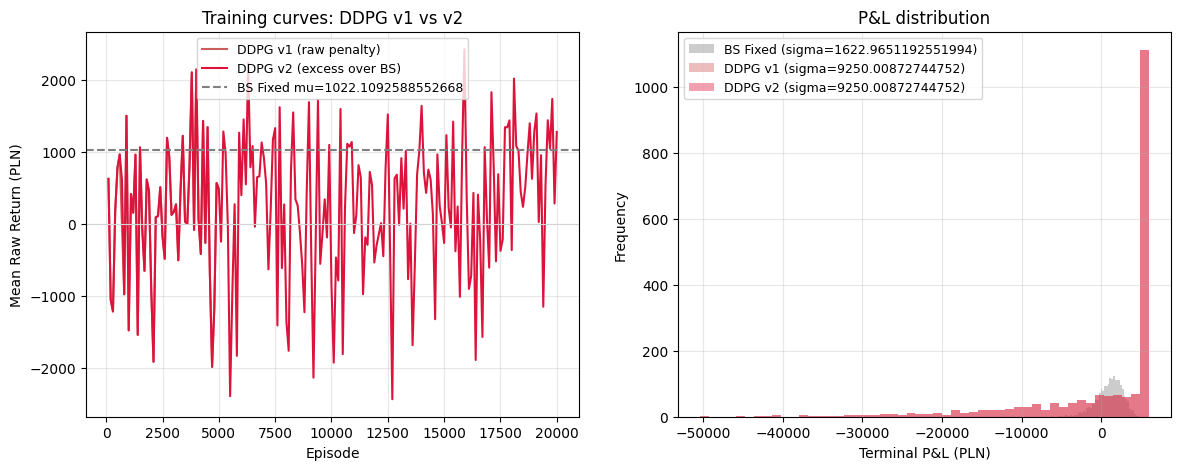

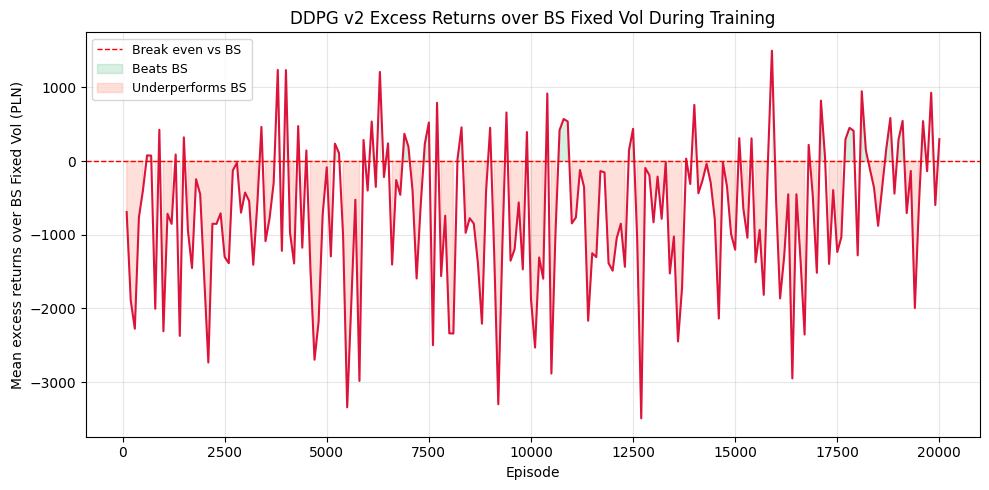

<Figure size 640x480 with 0 Axes>

In [88]:
# comparing DDPGv1 and DDPGv2
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bs_mean = bs_fixed_eval['pnl'].mean()

# training curves v1 vs v2
axes[0].plot(ddpg_pts, ddpg_raw, color='indianred', linewidth=1.5,
             label='DDPG v1 (raw penalty)')
axes[0].plot(ddpg_v2_pts, ddpg_v2_raw, color='crimson', linewidth=1.5,
             label='DDPG v2 (excess over BS)')
axes[0].axhline(bs_mean, color='grey', linestyle='--',
                label=f'BS Fixed mu={bs_mean}')
axes[0].axhline(0, color='lightgrey', linewidth=0.8)
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Mean Raw Return (PLN)')
axes[0].set_title('Training curves: DDPG v1 vs v2')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# pnl distribution bs vs DDPG v1 vs DDPG v2
axes[1].hist(bs_fixed_eval['pnl'], bins=50, alpha=0.4, color='grey',
             label=f"BS Fixed (sigma={bs_fixed_eval['pnl'].std()})")
axes[1].hist(ddpg_eval['pnl'], bins=50, alpha=0.4, color='indianred',
             label=f"DDPG v1 (sigma={ddpg_eval['pnl'].std()})")
axes[1].hist(ddpg_v2_eval['pnl'], bins=50, alpha=0.4, color='crimson',
             label=f"DDPG v2 (sigma={ddpg_v2_eval['pnl'].std()})")
axes[1].set_xlabel('Terminal P&L (PLN)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('P&L distribution')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

# excess returns training curve
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ddpg_v2_pts, ddpg_v2_excess, color='crimson', linewidth=1.5)
ax.axhline(0, color='red', linestyle='--', linewidth=1, label='Break even vs BS')
ax.fill_between(ddpg_v2_pts, 0, ddpg_v2_excess,
                where=np.array(ddpg_v2_excess) > 0,
                alpha=0.2, color='mediumseagreen', label='Beats BS')
ax.fill_between(ddpg_v2_pts, 0, ddpg_v2_excess,
                where=np.array(ddpg_v2_excess) <= 0,
                alpha=0.2, color='tomato', label='Underperforms BS')
ax.set_xlabel('Episode')
ax.set_ylabel('Mean excess returns over BS Fixed Vol (PLN)')
ax.set_title('DDPG v2 Excess Returns over BS Fixed Vol During Training')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.suptitle('DDPG V2 Results', fontsize=13)
plt.tight_layout()
plt.show()

Even though DDPG v2 used the DQN v3-style shaped rewards and had 4x training it collapsed like DDPG v1.This is likely a structural issue with DDPG as the critic overshoots the value for Q(s,a) early in training which biases the actor in a way that isn't recoverable. Another possible reason is that the risk-adjustment pushe the agent to find that the optimal strategy was to not trade at all as is suggested by the evaluation (the training graphs also have the gaussian noise of actions).

I test this in DDPGv3 where I use per-batch normalisation and set the variance penalty (lambda) to zero. The idea is that rewards in batches used for the critic update are standardised to zero mean variance before computing the TD target.

In [95]:
# ddpg v3 function
def ddpg_control_v3(n_eps, hmm_stats, market_params, s_0, K, eval_interval=100,
                    lr_actor=0.0001, lr_critic=0.001, batch_size=64, buffer_size=50000,
                    p=0.005, hidden=64, noise_start=0.2, noise_end=0.05,
                    noise_decay=2000, lambda_var=0.0, var_scale=10000, seed=21):

    # seeds and setup
    np.random.seed(seed)
    torch.manual_seed(seed)
    random.seed(seed)
    n_state = 6

    # load networks
    actor = DDPGActor(n_state, hidden)
    critic = DDPGCritic(n_state, hidden)
    target_actor = DDPGActor(n_state, hidden)
    target_critic = DDPGCritic(n_state, hidden)
    target_actor.load_state_dict(actor.state_dict())
    target_critic.load_state_dict(critic.state_dict())

    # set up optimisers for weight updates
    actor_optimiser = optim.Adam(actor.parameters(), lr=lr_actor)
    critic_optimiser = optim.Adam(critic.parameters(), lr=lr_critic)
    buffer = ReplayBuffer(replay_memory_size=buffer_size)

    # tracking performance
    eval_points = []
    ret_hist = []
    excess_ret_hist = []
    bs_ret_hist = []
    ep_rets = []
    ep_excess_rets = []
    ep_bs_rets = []

    # training
    for ep in range(n_eps):
        # gaussian action noise decay
        noise_std = noise_end + (noise_start - noise_end) * np.exp(-ep / noise_decay)
        # set up environment
        T = 40
        rng = np.random.default_rng(seed + ep)
        spots, regimes = price_sim(s_0, T, hmm_stats, rng)
        dt = 1 / 252
        r_pln = market_params['r_pln']
        r_usd = market_params['r_usd']
        notional = market_params['notional']
        sigma_fixed = market_params['sigma_fixed']
        k1, k2, k3 = market_params['k1'], market_params['k2'], market_params['k3']
        tao_0 = T / 252
        premium_per_unit = call_pricer(spots[0], K, tao_0, r_pln, r_usd, sigma_fixed)
        premium_pln = premium_per_unit * notional

        # initialise agent book
        delta_current = 0.0
        usd_held = 0.0
        cum_tc = 0.0
        cum_pln_spent = 0.0
        cum_interest_pln = 0.0
        cum_interest_usd = 0.0
        v_book_prev = 0.0

        # initialise BS shadow book
        bs_delta_current = 0.0
        bs_usd_held = 0.0
        bs_cum_tc = 0.0
        bs_cum_pln_spent = 0.0
        bs_cum_interest_pln = 0.0
        bs_cum_interest_usd = 0.0
        bs_v_book_prev = 0.0

        ep_raw_reward = 0
        ep_excess_reward = 0
        ep_bs_reward = 0

        # run episode
        for t in range(T):
            state_dict = {
                't': t, 'T': T, 'S_t': spots[t], 'K': K,
                'delta_current': delta_current, 'spot_history': spots[:t + 1],
                'r_pln': r_pln, 'r_usd': r_usd,
                'k1': k1, 'k2': k2, 'k3': k3}
            state_tensor = state_to_tensor(state_dict, market_params)

            with torch.no_grad():
                action = actor(state_tensor).item()
            noisy_action = action + np.random.normal(0, noise_std)
            target_delta = np.clip(noisy_action, 0.0, 1.0)

            # agent trade
            trade_delta = target_delta - delta_current
            trade_usd = trade_delta * notional
            # incur transaction costs
            if abs(trade_usd) < 0.0000001:
                tc = 0
            else:
                tc = k1 + (k2 * abs(trade_usd)) + (k3 * abs(trade_usd) * spots[t])
            cum_tc += tc
            # update agent book
            usd_held += trade_usd
            delta_current = target_delta
            cum_pln_spent += trade_usd * spots[t]
            cum_interest_pln += premium_pln * r_pln * dt
            cum_interest_usd += usd_held * r_usd * dt

            # BS shadow trade
            tao_annual = (T - t) / 252
            if tao_annual > 0:
                d1 = bs_d1(spots[t], K, tao_annual, r_pln, r_usd, sigma_fixed)
                bs_target = np.exp(-r_usd * tao_annual) * norm.cdf(d1)
            else:
                bs_target = 1.0 if spots[t] > K else 0.0

            bs_trade_delta = bs_target - bs_delta_current
            bs_trade_usd = bs_trade_delta * notional
            # incur transaction costs
            if abs(bs_trade_usd) < 0.000000001:
                bs_tc = 0.0
            else:
                bs_tc = k1 + (k2 * abs(bs_trade_usd)) + (k3 * abs(bs_trade_usd) * spots[t])
            # update BS shadow book
            bs_cum_tc += bs_tc
            bs_usd_held += bs_trade_usd
            bs_delta_current = bs_target
            bs_cum_pln_spent += bs_trade_usd * spots[t]
            bs_cum_interest_pln += premium_pln * r_pln * dt
            bs_cum_interest_usd += bs_usd_held * r_usd * dt

            # transition to next state
            s_next = spots[t + 1]
            tao_next = (T - t - 1) / 252
            call_next = call_pricer(s_next, K, tao_next, r_pln, r_usd, sigma_fixed)
            # update agent and BS books
            v_book_now = (-call_next * notional + premium_pln + cum_interest_pln
                         - cum_pln_spent + usd_held * s_next
                         + cum_interest_usd * s_next - cum_tc)

            bs_v_book_now = (-call_next * notional + premium_pln + bs_cum_interest_pln
                            - bs_cum_pln_spent + bs_usd_held * s_next
                            + bs_cum_interest_usd * s_next - bs_cum_tc)
            # unwind books at terminal state
            done = (t == T - 1)
            if done:
                if abs(usd_held) > 0.0000001:
                    unwind_tc = k1 + (k2 * abs(usd_held)) + (k3 * abs(usd_held) * s_next)
                    cum_tc += unwind_tc
                    v_book_now -= unwind_tc
                if abs(bs_usd_held) > 0.0000001:
                    bs_unwind_tc = k1 + (k2 * abs(bs_usd_held)) + (k3 * abs(bs_usd_held) * s_next)
                    bs_cum_tc += bs_unwind_tc
                    bs_v_book_now -= bs_unwind_tc

            # update rewards and excess reward for agent
            raw_reward = v_book_now - v_book_prev
            bs_reward = bs_v_book_now - bs_v_book_prev
            excess = raw_reward - bs_reward

            # setting lambda to 0, change to 0.5 if agent starts specualting
            shaped_reward = excess - lambda_var * (excess ** 2) / var_scale

            # move to next state book values and rewards
            v_book_prev = v_book_now
            bs_v_book_prev = bs_v_book_now
            ep_raw_reward += raw_reward
            ep_excess_reward += excess
            ep_bs_reward += bs_reward

            # transition to next state tensor
            if not done:
                next_state_dict = {
                    't': t + 1, 'T': T, 'S_t': s_next, 'K': K,
                    'delta_current': delta_current, 'spot_history': spots[:t + 2],
                    'r_pln': r_pln, 'r_usd': r_usd,
                    'k1': k1, 'k2': k2, 'k3': k3}
                next_state_tensor = state_to_tensor(next_state_dict, market_params)
            else:
                next_state_tensor = torch.zeros(n_state)
            # store transition in replay buffer
            buffer.push(state_tensor, target_delta, shaped_reward, next_state_tensor, done)

            # when replay buffer filled train critic
            if len(buffer) >= batch_size:
                b_states, b_actions, b_rewards, b_next_states, b_dones = buffer.sample(batch_size)
                b_actions = b_actions.float()

                # normalise rewards in batch
                b_rewards_norm = (b_rewards - b_rewards.mean()) / (b_rewards.std() + 1e-6)

                # critic update on normalised rewards
                with torch.no_grad():
                    next_actions = target_actor(b_next_states)
                    q_next = target_critic(b_next_states, next_actions)
                    td_targets = b_rewards_norm + q_next * (1 - b_dones)
                # calculate Q(s,a) and critic loss
                q_current = critic(b_states, b_actions)
                critic_loss = nn.MSELoss()(q_current, td_targets)
                # update critic with gradient
                critic_optimiser.zero_grad()
                critic_loss.backward()
                nn.utils.clip_grad_norm_(critic.parameters(), max_norm=10)
                critic_optimiser.step()

                # actor update
                actor_loss = -critic(b_states, actor(b_states)).mean()
                actor_optimiser.zero_grad()
                actor_loss.backward()
                nn.utils.clip_grad_norm_(actor.parameters(), max_norm=10)
                actor_optimiser.step()
                # update target networks
                soft_update(target_actor, actor, p)
                soft_update(target_critic, critic, p)

        # record returns and excess return for agent
        ep_rets.append(ep_raw_reward)
        ep_excess_rets.append(ep_excess_reward)
        ep_bs_rets.append(ep_bs_reward)

        # evaluate performance every eval interval
        if (ep + 1) % eval_interval == 0:
            eval_points.append(ep + 1)
            mean_raw = np.mean(ep_rets[-eval_interval:])
            mean_excess = np.mean(ep_excess_rets[-eval_interval:])
            mean_bs = np.mean(ep_bs_rets[-eval_interval:])
            std_raw = np.std(ep_rets[-eval_interval:])
            ret_hist.append(mean_raw)
            excess_ret_hist.append(mean_excess)
            bs_ret_hist.append(mean_bs)

            # test actor output at fixed S_0 ATM state so can see collapse early
            with torch.no_grad():
                ref_state = state_to_tensor({'t': 0, 'T': 40, 'S_t': s_0, 'K': K,
                 'delta_current': 0.0,'spot_history': np.array([s_0]),
                  'r_pln': r_pln, 'r_usd': r_usd, 'k1': k1, 'k2': k2, 'k3': k3},
                  market_params)
                ref_action = actor(ref_state).item()

            print(f'ep {ep+1}: agent={mean_raw} (std={std_raw}), '
                  f'BS={mean_bs}, excess={mean_excess}, '
                  f'noise_std={noise_std}, actor(ref)={ref_action}')

    return actor, critic, eval_points, ret_hist, excess_ret_hist, bs_ret_hist

In [96]:
# training DDPG v3, no need to run full 5000 episodes you can see it collapses in first 400
K = s_0
ddpg_v3_actor, ddpg_v3_critic, ddpg_v3_pts, ddpg_v3_raw, ddpg_v3_excess, ddpg_v3_bs = ddpg_control_v3(
    n_eps=5000, hmm_stats=hmm_stats, market_params=market_params,
    s_0=s_0, K=K, lr_actor=0.0001, lr_critic=0.001,
    p=0.005, noise_start=0.2, noise_end=0.05, noise_decay=2000,
    lambda_var=0.0, seed=21)

ep 100: agent=612 (std=6803), BS=1314, excess=-702, noise_std=0.193, actor(ref)=0.000
ep 200: agent=-1054 (std=9547), BS=838, excess=-1892, noise_std=0.186, actor(ref)=0.000
ep 300: agent=-1218 (std=9596), BS=1057, excess=-2275, noise_std=0.179, actor(ref)=0.000
ep 400: agent=175 (std=7340), BS=938, excess=-763, noise_std=0.173, actor(ref)=0.000


KeyboardInterrupt: 

No need to run full training or evaluate because in the first 400 episodes it already collapses (actor

# Comparing All RL Agents

In [89]:
# final cross-model comparison table fo all 14 policies
all_results = {
    'BS Fixed':bs_fixed_eval,'BS Rolling':bs_rolling_eval,
    'Linear Q-learning MC':linear_mc_eval,'Linear Q-learning TD':linear_td_eval,
    'DQN v1 (lambda=0.5)':dqn_v1_eval,'DQN v2 (lambda=2)':dqn_v2_eval,
    'DQN v2 (lambda=5)':dqn_v2_lamb5_eval,'DQN v3':dqn_v3_eval,
    'MCPG v1':mcpg_v1_eval,'MCPG v2':mcpg_v2_eval,'MCPG v3':mcpg_v3_eval,
    'AC v1':ac_v1_eval,'AC v2':ac_v2_eval,'DDPG v1':ddpg_eval,
    'DDPG v2':ddpg_v2_eval}

final_summary = build_summary(all_results)
print('Comparing all models')
print(final_summary.round(1).to_string(index=False))

Comparing all models
              policy  mean_pnl  std_pnl  sharpe  5th_pct  95th_pct  mean_tc  mean_turnover
            BS Fixed    1022.1   1623.0     0.6  -1949.1    3304.5    306.9            2.8
          BS Rolling     922.7   1946.4     0.5  -2555.6    3711.0    387.6            3.6
Linear Q-learning MC     862.2   5839.9     0.1 -11755.2    6155.5     64.4            0.6
Linear Q-learning TD     982.1   5786.6     0.2  -8719.9    9206.0    359.6            3.3
 DQN v1 (lambda=0.5)    1189.3   3488.0     0.3  -4985.0    6276.3    483.4            4.5
   DQN v2 (lambda=2)    1070.9   2178.0     0.5  -3243.9    3930.0    296.5            2.8
   DQN v2 (lambda=5)    1027.4   1918.2     0.5  -2558.0    3730.6    302.5            2.8
              DQN v3    1067.3   2822.2     0.4  -4010.6    4994.3    343.4            3.2
             MCPG v1    2223.6   7882.8     0.3 -14144.1    7880.7    214.5            2.0
             MCPG v2    1649.2   6082.1     0.3 -10522.7    9068.9   

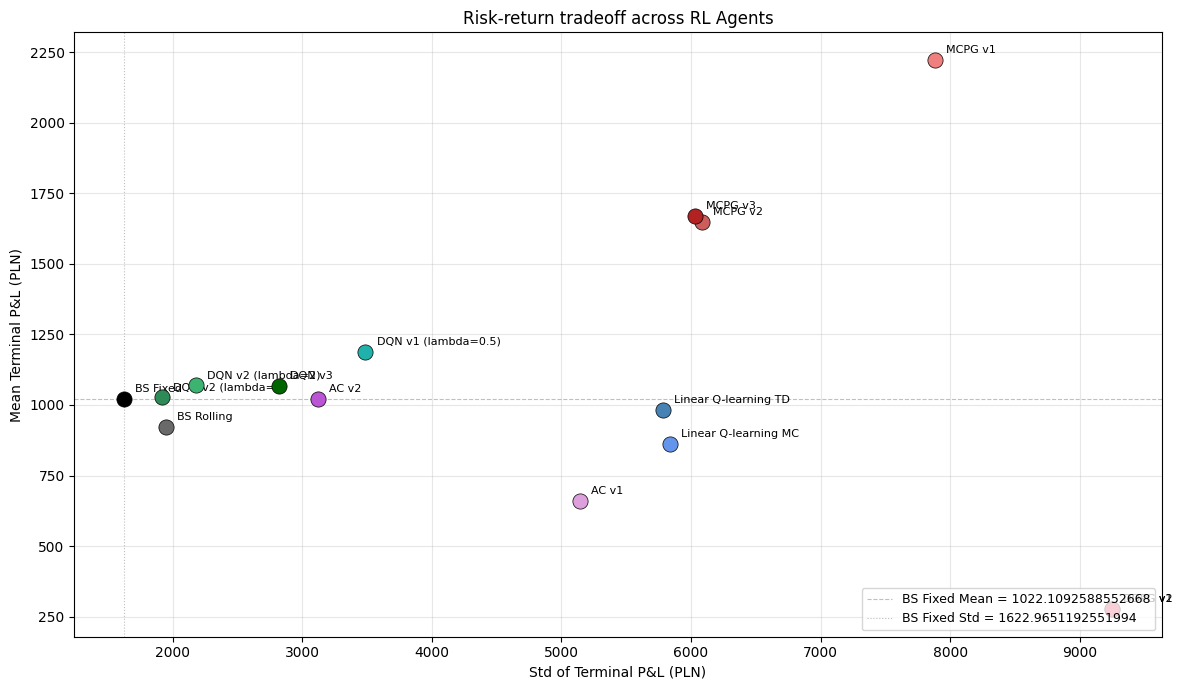

In [93]:
# visualising risk-return tradeoff for each model
fig, ax = plt.subplots(figsize=(12, 7))

# setting colours for each agent
colour_map= {
    'BS Fixed':'black','BS Rolling':'dimgrey',
    'Linear Q-learning MC':'cornflowerblue','Linear Q-learning TD':'steelblue',
    'DQN v1 (lambda=0.5)':'lightseagreen','DQN v2 (lambda=2)':'mediumseagreen',
    'DQN v2 (lambda=5)':'seagreen','DQN v3':'darkgreen',
    'MCPG v1':'lightcoral','MCPG v2':'indianred','MCPG v3':'firebrick',
    'AC v1':'plum','AC v2':'mediumorchid','DDPG v1':'lightsalmon', 'DDPG v2':'crimson'}

# calculating avg return and avg vol (risk) for each RL agent to label graph
for name, r in all_results.items():
    mean = r['pnl'].mean()
    std = r['pnl'].std()
    ax.scatter(std, mean, color=colour_map[name], s=120, zorder=5,
               edgecolor='black', linewidth=0.5)
    ax.annotate(name, (std, mean), textcoords='offset points',
                xytext=(8, 5), fontsize=8)

# mark bs fixed vol stats with vertical and horizontal reference lines
bs_mean = bs_fixed_eval['pnl'].mean()
bs_std = bs_fixed_eval['pnl'].std()
ax.axhline(bs_mean, color='grey', linestyle='--', linewidth=0.8, alpha=0.5,
           label=f'BS Fixed Mean = {bs_mean}')
ax.axvline(bs_std, color='grey', linestyle=':', linewidth=0.8, alpha=0.5,
           label=f'BS Fixed Std = {bs_std}')

ax.set_xlabel('Std of Terminal P&L (PLN)')
ax.set_ylabel('Mean Terminal P&L (PLN)')
ax.set_title('Risk-return tradeoff across RL Agents')
ax.legend(fontsize=9, loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

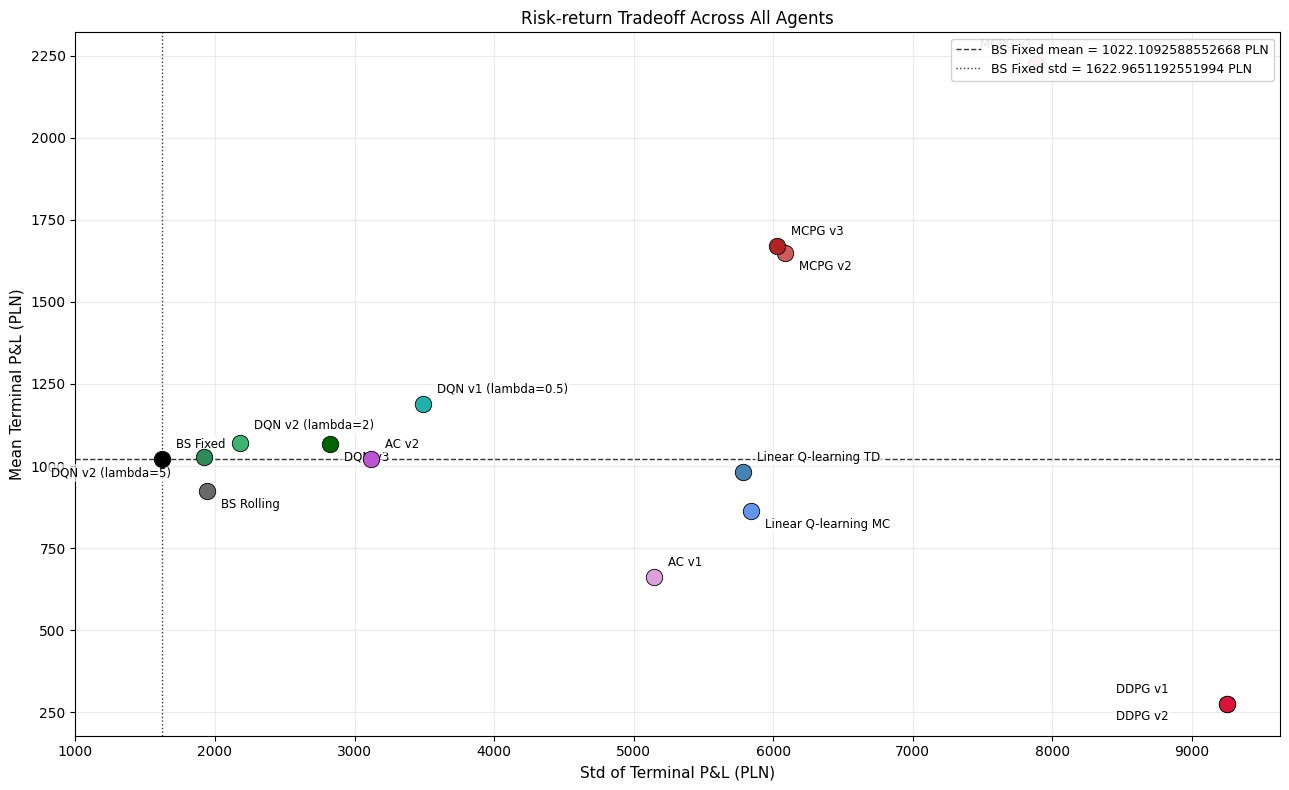

In [103]:
# improve graph above
fig, ax = plt.subplots(figsize=(13, 8))

colour_map = {'BS Fixed': 'black', 'BS Rolling': 'dimgrey',
    'Linear Q-learning MC': 'cornflowerblue', 'Linear Q-learning TD': 'steelblue',
    'DQN v1 (lambda=0.5)': 'lightseagreen', 'DQN v2 (lambda=2)': 'mediumseagreen',
    'DQN v2 (lambda=5)': 'seagreen', 'DQN v3': 'darkgreen',
    'MCPG v1': 'lightcoral', 'MCPG v2': 'indianred', 'MCPG v3': 'firebrick',
    'AC v1': 'plum', 'AC v2': 'mediumorchid',
    'DDPG v1': 'lightsalmon', 'DDPG v2': 'crimson'}

# manual label offsets to avoid overlap — (dx, dy) in points
label_offsets = {
    'BS Fixed':(10, 8),
    'BS Rolling':(10, -12),
    'Linear Q-learning MC':(10, -12),
    'Linear Q-learning TD':(10, 8),
    'DQN v1 (lambda=0.5)':(10, 8),
    'DQN v2 (lambda=2)':(10, 10),
    'DQN v2 (lambda=5)':(-110, -14),
    'DQN v3':(10, -12),
    'MCPG v1':(-40, 12),
    'MCPG v2':(10, -12),
    'MCPG v3':(10, 8),
    'AC v1':(10, 8),
    'AC v2':(10, 8),
    'DDPG v1':(-80, 8),
    'DDPG v2':(-80, -12)}

bs_mean = bs_fixed_eval['pnl'].mean()
bs_std = bs_fixed_eval['pnl'].std()

# thicker reference lines for fixed vol
ax.axhline(bs_mean, color='black', linestyle='--', linewidth=1, alpha=0.8,
           label=f'BS Fixed mean = {bs_mean} PLN')
ax.axvline(bs_std, color='black', linestyle=':', linewidth=1, alpha=0.8,
           label=f'BS Fixed std = {bs_std} PLN')

# plot each agent
for name, r in all_results.items():
    mean = r['pnl'].mean()
    std = r['pnl'].std()
    offset = label_offsets.get(name, (8,5))
    ax.scatter(std, mean, color=colour_map[name], s=140, zorder=5,
               edgecolor='black', linewidth=0.6)
    ax.annotate(name, (std, mean), textcoords='offset points',
                xytext=offset, fontsize=8.5,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                          edgecolor='none', alpha=0.7))

ax.set_xlabel('Std of Terminal P&L (PLN)', fontsize=11)
ax.set_ylabel('Mean Terminal P&L (PLN)', fontsize=11)
ax.set_title('Risk-return Tradeoff Across All Agents', fontsize=12)
ax.legend(fontsize=9, loc='upper right', framealpha=0.9)
ax.grid(alpha=0.25)
ax.set_xlim(left=1000)
plt.tight_layout()
plt.show()

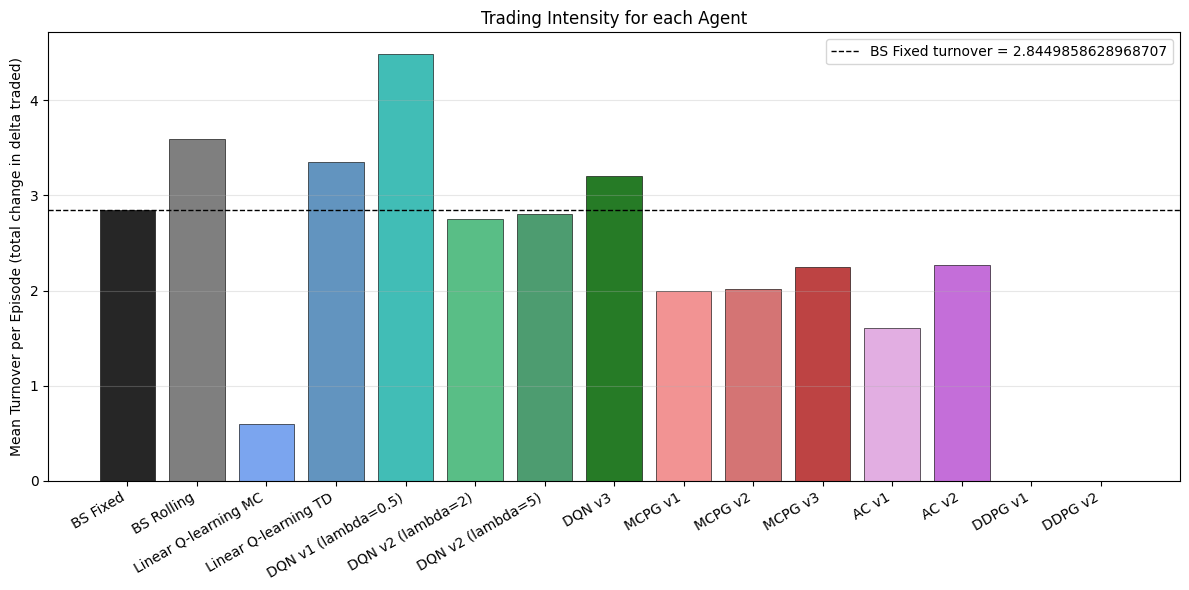

In [104]:
# visualise turnovers for each agent to identify which agents are speculating
fig, ax = plt.subplots(figsize=(12, 6))

names = list(all_results.keys())
turnovers = [all_results[n]['turnover'].mean() for n in names]
colours = [colour_map[n] for n in names]

bars = ax.bar(names, turnovers, color=colours, alpha=0.85, edgecolor='black', linewidth=0.5)

# bs fixed vol reference line
bs_turnover = bs_fixed_eval['turnover'].mean()
ax.axhline(bs_turnover, color='black', linestyle='--', linewidth=1,
           label=f'BS Fixed turnover = {bs_turnover}')

ax.set_ylabel('Mean Turnover per Episode (total change in delta traded)')
ax.set_title('Trading Intensity for each Agent')
ax.legend(fontsize=10, loc='upper right')
ax.grid(alpha=0.3, axis='y')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()